#Common Functions definitions and variables

## Install, import Libraries and Global Variables

In [1]:
%%capture --no-display
!pip install dkpro-cassis
!pip install spacy-sentiws
!python -m spacy download de_core_news_sm
!pip install fuzzywuzzy

In [2]:
#Libraries import.
from cassis import * #creation and manipulation of annotated documents: dkpro-cassis
from pathlib import * ##Not used
from collections import Counter
#Load annotation data into the notebook
from google.colab import drive
from google.colab import files
import os # Define the files to be deleted and modified in google Colab
import csv #Save to CSV after calcuations
import zipfile #For zip files
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from fuzzywuzzy import fuzz #for naming mistakes similarity scores.
from collections import defaultdict
import plotly.express as px

from datetime import datetime
import pytz
import shutil


/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [3]:
tz_Berlin = pytz.timezone('Europe/Berlin') #Berlin time when saving date in the filename of xlsx
DEBUG = False #Used if need output from from methods.
PROCESS_SINGLE_AUTHOR = False # Used testing purpose. When True then have to upload zip file of single author.
THRESHOLD = 90 #fuzzywuzzy for naming mistakes similarity scores.

### Fuction to delete all files

In [4]:
def action_delete_all_files(directory):
  '''
  Delete all files.
  '''
  try:
      # Check if the directory exists
      if os.path.exists(directory) and os.path.isdir(directory):
          # Iterate over all files and directories within the directory
          for filename in os.listdir(directory):
              file_path = os.path.join(directory, filename)

              # Check if it's a file and delete it
              if os.path.isfile(file_path) or os.path.islink(file_path):
                  os.remove(file_path)
                  print(f"Deleted file: {file_path}")
              # Check if it's a directory (optional) and skip or delete recursively
              elif os.path.isdir(file_path):
                  shutil.rmtree(file_path)  # Use this if you want to delete subdirectories
                  print(f"Deleted directory: {file_path}")
      else:
          print("Directory does not exist or is not a directory.")
  except Exception as e:
      print(f"Error while deleting files: {e}")

### csv to xlsx with filename_date_time for required columns

In [5]:
def save_xlsx_with_date_time(filename, columns=None,save_csv_without_date_time=False):
    '''
    Takes a CSV and saves it with the required columns to an XLSX OR CSV file.
    If columns are not specified, all columns are saved.
    '''

    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, encoding='utf-8-sig')

    # If no columns are specified, use all columns
    if columns is None:
        df_filtered = df
    else:
        df_filtered = df[columns]

    # Sort the DataFrame by 'Document_title' column if it exists (just as a safety ameasure)
    if 'Document_title' in df_filtered.columns:
        df_sorted = df_filtered.sort_values(by='Document_title')
    else:
        df_sorted = df_filtered  # No sorting if 'Document_title' does not exist

    # Get the current date and time in the format YYYYMMDD
    current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')


    if(save_csv_without_date_time):
      new_file_name = new_file_name = f'{filename.split(".")[0]}.xlsx'
      df_sorted.to_csv(new_file_name, encoding='utf-8-sig', index=False)
    else:
      # Define the new Excel file name with the current date and time
      new_file_name = f'{filename.split(".")[0]}_{current_time}.xlsx'

      # Save the sorted DataFrame to a new Excel file
      df_sorted.to_excel(new_file_name, index=False)

    print(f"File saved as: {new_file_name}")

### Combine two csv on a key

In [6]:
def combine_csv(filenames, outputfilename, key='Document_title'):
    """
    Combines multiple CSV files on a common key and saves the output to a new file.

    Parameters:
    filenames (list of str): List of CSV filenames to combine.
    key (str): The column name to merge the CSV files on.
    outputfilename (str): The name of the output CSV file.
    """
    # Initialize an empty DataFrame to hold the combined data
    combined_df = pd.DataFrame()

    for filename in filenames:
        if os.path.exists(filename):
            # Read the current CSV file
            df = pd.read_csv(filename)

            # If combined_df is empty, initialize it with the current dataframe
            if combined_df.empty:
                combined_df = df
            else:
                # Merge the current CSV with the existing combined dataframe on the specified key
                combined_df = pd.merge(combined_df, df, on=key, how='inner')
        else:
            print(f"File {filename} does not exist.")

    # Save the combined dataframe to the output file
    combined_df.to_csv(outputfilename, index=False, encoding='utf-8-sig')
    print(f"Combined CSV saved to {outputfilename}")


# Text Analysis

## Function definitions

### Function to ensure that None values are converted to strings

In [7]:
# Function to ensure that None values are converted to strings
def safe_str(obj):
    return str(obj) if obj is not None else 'NONE'

Function to upload just single author .zip

In [8]:
#Upload zip file intcontaining CAS XMI and XML
def upload_next_author_zip():

  #First delete files of previous author, if any.
  # Define the files to be deleted
  files_to_delete = ['TypeSystem.xml', 'CURATION_USER.xmi']

  # Path to the folder where the files are located
  content_folder_path = '/content/'

  # Delete the specified files if they exist
  for file_name in files_to_delete:
      file_path = os.path.join(content_folder_path, file_name)
      if os.path.isfile(file_path):
          os.remove(file_path)
          print(f"Deleted {file_path}")
      else:
          print(f"File {file_path} does not exist.")

  print(f"Deletion process completed for {files_to_delete} from path: {content_folder_path}.")
  print("\n")

  #Upload the ZIP file
  uploaded = files.upload()

  # Specify the extraction path
  content_folder_path = '/content/'

  # Extract the uploaded ZIP file to the specified folder
  for filename in uploaded.keys():
      # Ensure it's a zip file
      if filename.endswith('.zip'):
          with zipfile.ZipFile(filename, 'r') as zip_ref:
              zip_ref.extractall(content_folder_path)
              print(f'Extracted all files from {filename} to {content_folder_path}')
      else:
          print(f'{filename} is not a zip file')

  # Delete the ZIP file after extraction
  os.remove(filename)
  print(f'Deleted the ZIP file: {filename}')

### Functions of uploading zip file for all authors and extracting zip files and retun the list of folders.

In [9]:
#Extract files from from zip. for all authors "webanno*****export_curated_documents.zip"
def extract_nested_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as main_zip:
        # Extract the main zip
        main_zip.extractall(extract_to)

        # Iterate through each folder in the curation directory
        for folder_name in main_zip.namelist():
            if folder_name.endswith('.zip') and 'curation' in folder_name:
                nested_zip_path = os.path.join(extract_to, folder_name)

                # Extract the nested zip files
                with zipfile.ZipFile(nested_zip_path, 'r') as nested_zip:
                    nested_zip.extractall(os.path.dirname(nested_zip_path))

#returns the folder names as list in './curation'.
def get_folder_names(curation_path='./curation'):
    folder_names = [folder_name for folder_name in os.listdir(curation_path)
                    if os.path.isdir(os.path.join(curation_path, folder_name))]
    return folder_names



### Function for resetting variables to default value and default variables.

In [10]:
#Reset the values to default for variable: "annotation_overview_table"
def reset_annotation_overview_table(debug):
  global annotation_overview_table
  for key, value in annotation_overview_table.items():
      if isinstance(value, int):
          annotation_overview_table[key] = 0
      elif isinstance(value, str):
          annotation_overview_table[key] = '-'
  if debug:
    print(annotation_overview_table)
  return annotation_overview_table

In [11]:
#All entries of the annotaion overview scheme to be calculated
annotation_overview_table = {
                             'Document_title' : '',
                             'Textlänge_token' : 0, #Text length (tokens)
                             'Textlänge_sent' : 0 , #Text length (sentences)
                             'Entität_gesamt' : 0, 	#Entity (total)
                             'Entität_Ding'  : 0, #Entity (thing)
                             'Entität_Figur' : 0, #Entity (character)
                             'Entität_Figurengruppe' : 0, 	#Entity (character group)
                             'Entität_Raum' : 0, 	#Entity (space)
                             'Entität_Bereich' : 0, #Entity (area)
                             'Entität_Grenze'	 : 0, #Entity (boundary)
                             'Entität_Zeitabschnitt' : 0, 	#Entity (time period)
                             'Entität_Sonstige' : 0, #Entity (other)

                              'Wertung_gesamt' : 0, #Evaluation (total)
                              'Erzählerwertung' : 0, #Narrator evaluation
                             'Figurenwertung' : 0, #Character evaluation
                             'Wertung_Kompositionsebene' : 0,  #Evaluation (composition level)
                             'positive_Wertung' : 0,  #Positive evaluation
                             'negative_Wertung' : 0,  #Negative evaluation
                             'positive_Wertung_mit_Ironie': 0, #Positive evaluation with ironie
                             'negative_Wertung_mit_Ironie': 0, #negative evaluation with ironie

                             'Wertung_moralisch' : 0,  #Moral evaluation
                             'Wertung_eudämonistisch' : 0,  #Eudaimonistic evaluation
                             'Wertung_sozialer_Status' : 0,  #Social status evaluation
                             'Wertung_ästhetisch' : 0,  #Aesthetic evaluation
                             'Wertung_sonstige' : 0,  #Other evaluation


                             'Wertung_eudämonistisch_figure' : 0, #eudämonistisch counts if entity is figure
                             'Wertung_eudämonistisch_not_figure' : 0,



                            'NP_Wertung' : 0,  #NP evaluation (##Not implemented)
                            'Teilsatzwertung' : 0,  #Clause evaluation (##Not implemented)

                             'Codierung_gesamt' : 0,  #Coding (overall)
                             'Codierung_tief_oberflächlich' : 0,  #Coding (deep vs. superficial)
                             'Codierung_natürlich_kulturell' : 0,  #Coding (natural vs. cultural)
                             'Codierung_traditionell_modern' : 0,  #Coding (traditional vs. modern)
                             'Codierung_harmonisch_disharmonisch' : 0,  #Coding (harmonious vs. disharmonious)
                             'Codierung_Gesund_krank' : 0,  #Coding (healthy vs. sick opposition)

                             'Opposition_gesamt' : 0,  #Opposition (overall)
                             'Wertopposition' : 0,  #Value opposition
                             'Wertopposition_Oppositionspaar': '', #Value opposition List
                             'Traditionell-modern-Opposition' : 0,  #Traditional vs. modern opposition
                             'Harmonisch-disharmonisch-Opposition' : 0,  #Harmonious vs. disharmonious opposition
                             'Natürlich-kulturell-Opposition' : 0,  #Natural vs. cultural opposition
                             'Gesund-krank-Opposition' : 0,  #Healthy vs. sick opposition
                             'Tiefgründig-oberflächlich-Opposition' : 0,  #Profound vs. superficial opposition
                             'Sonstige_Merkmalsopposition' : 0,  #Other feature opposition
                             'Merkmalsopposition_Oppositionspaar': '', #Other feature opposition List
                             'Zugehörigkeit_zu' : 0,  #Belonging to
                             'Element_von' : 0,  #Element of
                             #'Kritikhaltige_Reflexion':0, #Kritikhaltige Reflexion




                             'Span_FIGUR' : 0,
                             'Span_LISTE_FIGUR' : '',

                             'Span_RAUM' : 0,
                             'Span_LISTE_RAUM' : '',

                             'Span_DING' : 0,
                             'Span_LISTE_DING' : '',

                             'Span_SONSTIGE' : 0,
                             'Span_LISTE_SONSTIGE' : '',

                             'Span_FIGURENGRUPPE' : 0,
                             'Span_LISTE_FIGURENGRUPPE' : '',

                             'Span_BEREICH' : 0,
                             'Span_LISTE_BEREICH' : '',

                             'Span_GRENZE' : 0,
                             'Span_LISTE_GRENZE' : '',

                             'Span_ABSTRAKTUM' : 0,
                             'Span_LISTE_ABSTRAKTUM' : '',

                             'Span_ZEITABSCHNITT' : 0,
                             'Span_LISTE_ZEITABSCHNITT' : '',

                             'Span_ORGANISATION' : 0,
                             'Span_LISTE_ORGANISATION' : '',

                             'Span_NONE' : 0, #In case there is no label (in case of author/Narrator)
                             'Span_LISTE_NONE' : '', #In case there is no label (in case of author/Narrator)

                             'Span_entities_with_Referenz_Wikidata':0,
                             'Span_LISTE_entities_with_Referenz_Wikidata' : '-',
                              'total_list_naming_mistakes':0,
                              'list_naming_mistakes': '',

                              'Erzählerwechsel' : 0,   #Five new categories added dated:17-09-2024
                              'Kritikhaltige_Reflexion' : 0,
                              'TriggerCodierung' : 0,
                              'TriggerWertung' : 0,
                              'TriggerMerkmalsopposition' : 0,
                              'Overlapping_Oppositions' : 0,
                             'Span_LISTE_Overlapping_Oppositions' : '-', #overlapping oppositions Added: 28-09-2024
                             #'Span_LISTE_Overlapping_Oppositions_Potential_ERRORS': '-',
                             'evaluative_difference_of_contrastive_entities': 0, #Added: 05-19-2024
                             'codierung_with_trigger_explicit':0, #Added: 31-10-2024
                             'codierung_without_trigger_implicit':0,
                             'wertung_with_trigger_explicit':0,
                             'wertung_without_trigger_implicit':0,
                             'ratio_explicit_implicit_codierung':0,
                             'ratio_explicit_implicit_wertung':0
                            }

### Function to check file availability

In [12]:
#Checks if file is available if not then uploads it.
def check_for_file(file_name):
    # Define the file to be deleted
    file_namex = file_name

    # Path to the folder where the file is located
    content_folder_path = '/content/'
    file_path = os.path.join(content_folder_path, file_namex)

    # Check if the file exists
    if not os.path.isfile(file_path):
        # If the file does not exist, ask for upload
        print(f"File {file_path} does not exist. Upload {file_name} may be generated from last step")
        file_to_open = files.upload()
    else:
      print(f"{file_namex} Already uploaded.\n")

### Function to for saving to CSV file

In [13]:
#Will delete after next sucessful run.
'''#Safe the results to CSV file.
def save_to_csv(annotation_overview_table):
    # Define the CSV file name
    csv_file = 'output.csv'

    # Check if the CSV file already exists
    file_exists = os.path.isfile(csv_file)

    # Open the CSV file in append mode
    with open(csv_file, mode='a', newline='', encoding='utf-8-sig') as file:
        writer = csv.writer(file, delimiter=',')

        # Write the header only if the file does not exist
        if not file_exists:
            # Write the header row
            writer.writerow(annotation_overview_table.keys())

        # Write the dictionary values as a new row
        writer.writerow(annotation_overview_table.values())

    print(f"Data appended to {csv_file}")
    '''

'#Safe the results to CSV file.\ndef save_to_csv(annotation_overview_table):\n    # Define the CSV file name\n    csv_file = \'output.csv\'\n\n    # Check if the CSV file already exists\n    file_exists = os.path.isfile(csv_file)\n\n    # Open the CSV file in append mode\n    with open(csv_file, mode=\'a\', newline=\'\', encoding=\'utf-8-sig\') as file:\n        writer = csv.writer(file, delimiter=\',\')\n\n        # Write the header only if the file does not exist\n        if not file_exists:\n            # Write the header row\n            writer.writerow(annotation_overview_table.keys())\n\n        # Write the dictionary values as a new row\n        writer.writerow(annotation_overview_table.values())\n\n    print(f"Data appended to {csv_file}")\n    '

In [14]:
#Updated Save to CSV now it sorts by Document_title while saving.
def save_to_csv(annotation_overview_table,file_name='01_output.csv'):
    # Define the CSV file name
    csv_file = file_name

    # Check if the CSV file already exists
    file_exists = os.path.isfile(csv_file)

    # If the file exists, read it into a pandas DataFrame
    if file_exists:
        df = pd.read_csv(csv_file, encoding='utf-8-sig')
    else:
        df = pd.DataFrame()

    # Convert the annotation_overview_table dictionary to a DataFrame
    new_row_df = pd.DataFrame([annotation_overview_table])

    # Append the new row to the existing DataFrame
    df = pd.concat([df, new_row_df], ignore_index=True)

    # Sort the DataFrame by 'Document_title' (or any other column you want)
    if 'Document_title' in df.columns:
        df = df.sort_values(by='Document_title')

    # Save the sorted DataFrame to the CSV file
    df.to_csv(csv_file, mode='w', index=False, encoding='utf-8-sig')

    print(f"Data appended and sorted in {csv_file}")


### Funtions to count Tokens and Sentences

In [15]:
#Count Analysis of Tokens
#Return Token count from the document
def token_info(doc, debug):
  #Textlänge_token
  #Text length (tokens)
  token_count = sum(1 for count in doc.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'))
  if debug:
    print("#################### Textlänge_token (Number of (tokens)) #####################################")
    print(f'Token_Count: {token_count}')
    print("\n")
  return token_count


#Count Analysis of Sentences
def sen_info(doc,debug):
  #Textlänge_sent
  #Text length (sentences)
  sentence_count = sum(1 for count in doc.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Sentence'))
  if debug:
    print("#################### Textlänge_sent (Number of (sentences)) #####################################")
    print(f'Sentence_Count: {sentence_count}')
    print("\n")

  #Calculated values from this cell.
  annotation_overview_table['Textlänge_sent'] = sentence_count #Text length (sentences)

### Funtion to count Entities(Entität)

In [16]:
#Count Analysis of Entities
def entities_info(doc, _doc_title,debug):
  #Entität_gesamt	Entität_Ding	Entität_Figur	Entität_Figurengruppe	Entität_Raum	Entität_Bereich	Entität_Grenze	Entität_Zeitabschnitt	Entität_Sonstige
  #Entity (overall)	Entity (thing)	Entity (character)	Entity (character group)	Entity (space)	Entity (area)	Entity (boundary)	Entity (time period)	Entity (other)

  # Initialize counts
  Entities_counts = {'DING' : 0,
                    'FIGUR': 0,
                    'FIGURENGRUPPE': 0,
                    'RAUM': 0,
                    'BEREICH' : 0,
                    'GRENZE': 0,
                    'ZEITABSCHNITT': 0,
                    'SONSTIGE': 0
  }
  entities_overlap = {}  # Use a dict to map token to its (begin, end) span 04-05-25

  #Get the entity label and count if in the list of entity type.

  for idx, token in enumerate(doc.select('custom.Span')):
      if token.label in Entities_counts:
        Entities_counts[token.label] += 1
        entities_overlap[idx] = (token, token.label, token.begin, token.end)

  # Step 2: Filter out tokens with no overlap
  to_remove = []
  for idx1, (token1, _, begin1, end1) in entities_overlap.items():
      has_overlap = False
      for idx2, (token2, _, begin2, end2) in entities_overlap.items():
          if idx1 != idx2 and begin1 <= end2 and begin2 <= end1:
              has_overlap = True
              break
      if not has_overlap:
          to_remove.append(idx1)

  for idx in to_remove:
      del entities_overlap[idx]


  # Step 3: Save to txt

  with open("entities_overlap.txt", 'a', encoding='utf-8') as f:
      f.write(f"============{_doc_title}===========\n")
      for idx, (token, label, start, end) in entities_overlap.items():
          f.write(f"[{idx}] [covered_text:{token.get_covered_text()}] [token:{token}]\n")

  if debug:
    print("#################### Entität (Entity Counts) #####################################")
    print(f'Gesamt: {sum(Entities_counts.values())}::',Entities_counts)
    print("\n")


  #Calculated values from this cell.
  annotation_overview_table['Entität_gesamt'] = sum(Entities_counts.values()) #Entity (total)
  # Create a mapping of Entities_counts keys to annotation_overview_table keys
  mapping = {'DING' : 'Entität_Ding',
                    'FIGUR': 'Entität_Figur',
                    'FIGURENGRUPPE': 'Entität_Figurengruppe',
                    'RAUM': 'Entität_Raum',
                    'BEREICH' : 'Entität_Bereich',
                    'GRENZE': 'Entität_Grenze',
                    'ZEITABSCHNITT': 'Entität_Zeitabschnitt',
                    'SONSTIGE': 'Entität_Sonstige'
  }

  # Update annotation_overview_table_key with the values from Entities_counts based on the mapping
  for Entities_counts_key, annotation_overview_table_key in mapping.items():
    if Entities_counts_key in Entities_counts:
        annotation_overview_table[annotation_overview_table_key] = Entities_counts[Entities_counts_key]

### Funtion to count Ratings/Evaluations(Wertung)

In [17]:
#19-12-2024
def info_Wertung_n_and_tokens_desctiptive_stats(doc_CAS_xmi, debug=False):

  if(debug):
    print("=====info_Wertung_n_and_tokens_desctiptive_stats=====")

  doc_CAS_xmix = doc_CAS_xmi
  n=0
  count_dependent_tokens = 0
  for token in doc_CAS_xmix.select('webanno.custom.Wertung'):
    n+=1
    #Count no of tokens with in the encodings
    for doc_tokens in doc_CAS_xmix.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'):
      if(doc_tokens.begin)>=token.begin and (doc_tokens.end)<=token.end:
        count_dependent_tokens+=1

  return n,count_dependent_tokens






#Count Analysis of Ratings/Evaluation
def evaluation_info(doc,debug): #Exlcluding Positive and negative count as they are calulcated in Evaluation_count_positive_negative():
  debug=True
  #Wertung_gesamt	Erzählerwertung	Figurenwertung	Wertung_Kompositionsebene	 	Wertung_moralisch	Wertung_eudämonistisch	Wertung_sozialer_Status	Wertung_ästhetisch	Wertung_sonstige
  #Evaluation (total)	Narrator evaluation	Character evaluation	Evaluation (composition level) Moral evaluation	Eudaimonistic evaluation	Social status evaluation	Aesthetic evaluation	Other evaluation



  # Initialize counts
  evaluations_counts = {'Erzählerwertung' : 0 , 'Figurenwertung' : 0 ,	'Kompositionsebene' : 0 ,
                    #'positive_Wertung' : 0 ,	'negative_Wertung' : 0 , #calculated in evaluation_count_positive_negative():
                    'moralisch' : 0 ,	'eudämonistisch' : 0 ,
                    'sozialer Status' : 0 ,	'ästhetisch' : 0 ,	'sonstige' : 0
  }

  #Get the label and count if in the list of Evaluation types.
  for token in doc.select('webanno.custom.Wertung'):
    if token.Wertungshinsicht in evaluations_counts:
      evaluations_counts[token.Wertungshinsicht] += 1
    elif token.Wertungshinsicht =='nicht spezifiziert': #Added count of nicht spezifiziert to sonstige
      evaluations_counts['sonstige'] += 1
    if token.Wertung_auf_Kompositionsebene == 'Kompositionsebene':
      evaluations_counts['Kompositionsebene'] += 1

  #finding Erzählerwertung and Figurenwertung
  #modified: 15-01-2024
  Figurewertung = 0
  Erzahelrwertung = 0
  Wertung_gesamt=0

  for segment in doc.select('webanno.custom.Wertung'):
      #print("==webanno.custom.Wertung== segment.test",segment.TEST) # 09-01-2025

      #print("==========segment.TEST.elements=====",segment.TEST.elements)
      Wertung_gesamt+=1
      flagx=True
      if segment.TEST:
        for e in segment.TEST.elements:
          #print("======================= e ======= ", e.target.get_covered_text())
          if e.role == "Wertender":#FigureWertung.
            flagx=False
          if e.role not in ["Wertender" ,"gewertete Entität"]:
            print("============== e.role not in [Wertender ,gewertete Entität] == :", e.target.get_covered_text(), " Role: ", e.role)

      if flagx:
        Erzahelrwertung+=1
      else:
        Figurewertung+=1
  #print("Wertung_gesamt=======================",Wertung_gesamt)

  evaluations_counts['Figurenwertung'] = Figurewertung
  evaluations_counts['Erzählerwertung'] = Erzahelrwertung

  #TODO: 09-01-2025 total evaluations = gesamt = FigureWertung.+ #Erzahelrwertung.
  Wertung_gesamt=evaluations_counts['Erzählerwertung']+evaluations_counts['Figurenwertung']#+evaluations_counts['Kompositionsebene']



  if debug:
    print("####################  Wertung (Analysis of Ratings ) : Excluding positive_Wertung	negative_Wertung #####################################")
    print('\n')
    print("Figurenwertung",Figurewertung)
    print("Erzählerwertung",Erzahelrwertung)
    print("\n")


  annotation_overview_table['Wertung_gesamt'] = Wertung_gesamt #Ratings/Evaluation (total)

  # Create a mapping of evaluations_counts keys to annotation_overview_table keys
  mapping = {'Erzählerwertung' : 'Erzählerwertung' ,
                    'Figurenwertung' : 'Figurenwertung' ,	'Kompositionsebene' : 'Wertung_Kompositionsebene' ,
                    #'positive_Wertung' : 'positive_Wertung' ,	'negative_Wertung' : 'negative_Wertung' ,
                    'moralisch' : 'Wertung_moralisch' ,	'eudämonistisch' : 'Wertung_eudämonistisch',
                    'sozialer Status' : 'Wertung_sozialer_Status' ,	'ästhetisch' : 'Wertung_ästhetisch' ,	'sonstige' : 'Wertung_sonstige'
  }

  # Update annotation_overview_table_key with the values from coding_counts based on the mapping
  for coding_counts_key, annotation_overview_table_key in mapping.items():
    if coding_counts_key in evaluations_counts:
        annotation_overview_table[annotation_overview_table_key] = evaluations_counts[coding_counts_key]


### Function for Wertung_eudämonistisch and Wertung_eudämonistisch__figure counts

In [18]:
def eudämonistisch_fig_notfig_counts(typesystem_xml):
  with open(typesystem_path, 'rb') as f:
    typesystem_xml = load_typesystem(f)

  with open(cas_file_path, 'rb') as f:
    doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?

  eudämonistisch_total = 0
  eudämonistisch__figure = 0

  # Loop through all 'webanno.custom.Wertung' annotations
  for wertung_token in doc_CAS_xmi.select('webanno.custom.Wertung'):
      if wertung_token.Wertungshinsicht == 'eudämonistisch':
          eudämonistisch_total += 1

          # Now check if there's a corresponding 'custom.Span' with the label "FIGUR"
          for span_token in doc_CAS_xmi.select('custom.Span'):
              # Check if the spans overlap or are exactly the same
              if span_token.label == "FIGUR" and (
                  span_token.begin == wertung_token.begin and span_token.end == wertung_token.end
              ):
                  eudämonistisch__figure += 1
                  break  # Assuming one match per wertung_token is enough
  eudämonistisch_not_figure= eudämonistisch_total - eudämonistisch__figure
  return (eudämonistisch__figure,eudämonistisch_not_figure)


### Funtion to count Positive, nagative Ratings/Evaluations(Wertung), positive_Wertung_mit_Ironie and nagative_Wertung_mit_Ironie

In [19]:
# Wertungen ausgeben / Issue ratings
#Erzählerwertung	Figurenwertung	Wertung_Kompositionsebene	positive_Wertung	negative_Wertung
#Narrator evaluation(default)	Character evaluation	Evaluation (composition level)author	Positive evaluation	Negative evaluation
#Count Analysis of Ratings
def evaluations_count_positive_negative(doc,debug):

  # Initialize the dictionary
  dict_positive_entities = {}
  dict_negative_entities = {}
  dict_positive_entities_nameless  = {}
  dict_negative_entities_nameless  = {}
  PIronie=0 #positive_Wertung_mit_Ironie
  NIronie=0 #negative_Wertung_mit_Ironie

  for segment in doc.select('webanno.custom.Wertung'): ##webanno.custom.rating
      #print("hier: ", segment.TEST)
      #print(str(segment.TEST.elements)) # seems like i don't miss any information by not printing this?
      #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)

      Erzählerwertung = True  ##Narrator Rating = TRUE
      try:
          for e in segment.TEST.elements: # and why does this seem to work here but not above?
              #print(e)
              pass
      except:
          #print("Segment ohne gew. Objekt: Segment without selected object") ##Segment without selected object
          continue

      for e in segment.TEST.elements:
          #print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)

          # create lists of positive entities
          if Erzählerwertung == True and e.role == "gewertete Entität":
            if (segment.Polaritt == "sehr positiv" or segment.Polaritt == "positiv"):
              if(segment.Ironie):
                PIronie+=1
              if e.target.Name == None:
                if e.target.get_covered_text() not in dict_positive_entities_nameless:
                  dict_positive_entities_nameless[e.target.get_covered_text()] = 1
                else:
                  dict_positive_entities_nameless[e.target.get_covered_text()] += 1

              elif e.target.Name not in dict_positive_entities:
                  dict_positive_entities[e.target.Name] = 1
              else:
                  dict_positive_entities[e.target.Name] += 1


          # create lists of negative entities
          if Erzählerwertung == True and e.role == "gewertete Entität":
            if(segment.Polaritt == "sehr negativ" or segment.Polaritt == "negativ" ):
              if(segment.Ironie):
                NIronie+=1
              if e.target.Name == None:
                if e.target.get_covered_text() not in dict_negative_entities_nameless:
                  dict_negative_entities_nameless[e.target.get_covered_text()] = 1
                else:
                  dict_negative_entities_nameless[e.target.get_covered_text()] += 1
              elif e.target.Name not in dict_negative_entities:
                  dict_negative_entities[e.target.Name] = 1
              else:
                  dict_negative_entities[e.target.Name] += 1


  if debug:

    print("####################  Wertung (Analysis of Ratings ) : positive_Wertung	negative_Wertung #####################################")

    print("\n")

    print("Total: dict_positive_entities= ",sum(dict_positive_entities.values()), dict_positive_entities)
    print("Total: dict_positive_entities_nameless= ",sum(dict_positive_entities_nameless.values()), dict_positive_entities_nameless)

    print("\n")

    print("Total: dict_negative_entities= ",sum(dict_negative_entities.values()), dict_negative_entities)
    print("Total: dict_negative_entities_nameless= ",sum(dict_negative_entities_nameless.values()), dict_negative_entities_nameless)

    print("\n")

    #Calculated values from this cell.
  annotation_overview_table['positive_Wertung'] = sum(dict_positive_entities.values()) + sum(dict_positive_entities_nameless.values()) #Positive evaluation
  annotation_overview_table['negative_Wertung'] = sum(dict_negative_entities.values()) + sum(dict_negative_entities_nameless.values()) #Negative evaluation


  annotation_overview_table['positive_Wertung_mit_Ironie']=PIronie
  annotation_overview_table['negative_Wertung_mit_Ironie']=NIronie


##TODO: Not sure about following
#Narrator evaluation
#Character evaluation
#Evaluation (composition level)

### Funtion to count codings(Codierung)

In [20]:
#Count Analysis of Coding
def coding_info(doc,debug):

  #Codierung_gesamt	Codierung_tief_oberflächlich	Codierung_natürlich_kulturell	Codierung_traditionell_modern	Codierung_harmonisch_disharmonisch	Codierung_Gesund_krank_Opposition
  #Coding (Total)	Coding (deep vs. superficial)	Coding (natural vs. cultural)	Coding (traditional vs. modern)	Coding (harmonious vs. disharmonious)	Coding (healthy vs. sick opposition)


  # Initialize counts
  coding_counts = {'TIEF-OBERFLÄCHLICH' : 0,
                  'NATÜRLICH-KULTURELL' : 0,
                  'TRADITIONELL-MODERN' : 0,
                  'HARMONISCH-DISHARMONISCH' : 0,
                  'GESUND-KRANK' : 0
  }
  #Get the label and count if in the list of coding type.
  for token in doc.select('webanno.custom.AltNeuCodierung'):
    if token.Art.upper() in coding_counts:
      coding_counts[token.Art.upper()] += 1

  if debug:
    print("####################  Codierung (Analysis of Coding ) #####################################")
    print(f'Codierung_gesamt: {sum(coding_counts.values())}::',coding_counts)
    print("\n")




  #Calculated values from this cell.
  annotation_overview_table['Codierung_gesamt'] = sum(coding_counts.values()) #Coding (total)
  # Create a mapping of coding_counts keys to annotation_overview_table keys
  mapping = {'TIEF-OBERFLÄCHLICH' : 'Codierung_tief_oberflächlich',
                    'NATÜRLICH-KULTURELL': 'Codierung_natürlich_kulturell',
                    'TRADITIONELL-MODERN': 'Codierung_traditionell_modern',
                    'HARMONISCH-DISHARMONISCH': 'Codierung_harmonisch_disharmonisch',
                    'GESUND-KRANK' : 'Codierung_Gesund_krank'
  }

  # Update annotation_overview_table_key with the values from coding_counts based on the mapping
  for coding_counts_key, annotation_overview_table_key in mapping.items():
    if coding_counts_key in coding_counts:
        annotation_overview_table[annotation_overview_table_key] = coding_counts[coding_counts_key]

### Funtion to count Opposition

In [21]:
#Count Analysis of Opposition
def opposition_info(doc,debug):

  #Opposition_gesamt	Wertopposition	Traditionell-modern-Opposition	Harmonisch-disharmonisch-Opposition	Natürlich-kulturell-Opposition	Gesund-krank-Opposition	Tiefgründig-oberflächlich-Opposition	Sonstige_Merkmalsopposition
  #Opposition (total)	Value opposition	Traditional vs. modern opposition	Harmonious vs. disharmonious opposition	Natural vs. cultural opposition	Healthy vs. sick opposition	Profound vs. superficial opposition	Other feature opposition

  # for list of Wertopposition_Oppositionspaar and Merkmalsopposition_Oppositionspaar
  opposition_list = {
      'Wertopposition_Oppositionspaar': [], 'Merkmalsopposition_Oppositionspaar': []
  }


  # Initialize counts
  opposition_counts = {'WERTOPPOSITION' : 0,	'TRADITIONELL-MODERN-OPPOSITION' : 0,	'HARMONISCH-DISHARMONISCH-OPPOSITION'	 : 0,
                    'NATÜRLICH-KULTURELL-OPPOSITION' : 0, 'GESUND-KRANK-OPPOSITION' : 0,	'TIEF-OBERFLÄCHLICH-OPPOSITION' : 0, 'SONSTIGE MERKMALSOPPOSITION'  : 0
  }



  #Get the label and count if in the list of Opposition type.
  for token in doc.select('custom.Relation'):

    if token.label.upper()=='WERTOPPOSITION':
      #opposition_list['Wertopposition_Oppositionspaar'].append(safe_str(token.Merkmalsopposition))  #this was before 28th the rest conditions are added later below only in this if

      #print("==============================",token.get_covered_text)
      #print(token.Wertungshinsicht)
      #for e in token.TEST.elements:#print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt
      if(token.Wertungshinsicht):
        opposition_list['Wertopposition_Oppositionspaar'].append(safe_str(token.Wertungshinsicht))
        #print(1,safe_str(token.Wertungshinsicht))
      else:
          opposition_list['Wertopposition_Oppositionspaar'].append(safe_str(token.Merkmalsopposition))
          #print(2,safe_str(token.Merkmalsopposition))
      #print("==============================")






    elif token.label.upper()=='SONSTIGE MERKMALSOPPOSITION':
      opposition_list['Merkmalsopposition_Oppositionspaar'].append(safe_str(token.Merkmalsopposition))

    if token.label.upper() in opposition_counts:
      opposition_counts[token.label.upper()] += 1

  if debug:

    print(opposition_list)
  # Update annotation overview table
  for label, names in opposition_list.items():
      if len(names) > 0:
        annotation_overview_table[label] = ";".join(names) + ";"  # Concatenate names





  if debug:
    print("####################  Opposition (Analysis of Opposition ) #####################################")
    print(f'Opposition_gesamt: {sum(opposition_counts.values())}::',opposition_counts)
    print("\n")



  #Calculated values from this cell.
  annotation_overview_table['Opposition_gesamt'] = sum(opposition_counts.values()) #Opposition (total)
  # Create a mapping of coding_counts keys to annotation_overview_table keys
  mapping = {'WERTOPPOSITION' : 'Wertopposition',	'TRADITIONELL-MODERN-OPPOSITION' : 'Traditionell-modern-Opposition',	'HARMONISCH-DISHARMONISCH-OPPOSITION'	 : 'Harmonisch-disharmonisch-Opposition',
                    'NATÜRLICH-KULTURELL-OPPOSITION' : 'Natürlich-kulturell-Opposition',
             'GESUND-KRANK-OPPOSITION' : 'Gesund-krank-Opposition',	'TIEF-OBERFLÄCHLICH-OPPOSITION' : 'Tiefgründig-oberflächlich-Opposition', 'SONSTIGE MERKMALSOPPOSITION'  : 'Sonstige_Merkmalsopposition'
  }

  # Update annotation_overview_table_key with the values from coding_counts based on the mapping
  for opposition_counts_key, annotation_overview_table_key in mapping.items():
    if opposition_counts_key in opposition_counts:
        annotation_overview_table[annotation_overview_table_key] = opposition_counts[opposition_counts_key]


### Funtion to count Zugehörigkeit_zu and Element_von

In [22]:
#Count Analysis of group of characters/family
def character_family_info(doc,debug):

  #Zugehörigkeit_zu, Element_von

  # Initialize counts
  character_family_counts = {'ZUGEHÖRIGKEIT' : 0,	'ELEMENT VON' : 0  }

  #Get the label and count if in the list.
  for token in doc.select('custom.Relation'):
    if token.label.upper() in character_family_counts:
      character_family_counts[token.label.upper()] += 1

  if debug:
    print("####################  Zugehörigkeit_zu, Element_von (Analysis of group of characters/family ) #####################################")

    print(character_family_counts)
    print("\n")



  # Create a mapping of coding_counts keys to annotation_overview_table keys
  mapping = {'ZUGEHÖRIGKEIT' : 'Zugehörigkeit_zu',	'ELEMENT VON' : 'Element_von'  }

  # Update annotation_overview_table_key with the values from coding_counts based on the mapping
  for character_family_counts_key, annotation_overview_table_key in mapping.items():
    if character_family_counts_key in character_family_counts:
        annotation_overview_table[annotation_overview_table_key] = character_family_counts[character_family_counts_key]


### Funtion to get metadata from the xmi file

In [23]:
#Gets Title from Metadata.
#Requires: CAS_XMI file
#Retuns: document_title from metadata
def document_metadata_info(typesystem_xml,doc_CAS_xmi,debug):
  # Get the DocumentMetaData type from the type system
  DocumentMetaData = typesystem_xml.get_type('de.tudarmstadt.ukp.dkpro.core.api.metadata.type.DocumentMetaData')
  # Retrieve the DocumentMetaData from the CAS Doc
  document_metadata_list = doc_CAS_xmi.select(DocumentMetaData)

  # Metadata list
  if document_metadata_list:
      document_metadata = document_metadata_list[0] # Access the first (and only) item in the list
      document_title = document_metadata.documentTitle  #Document Title


#24-05-2025:MatterMost
 # if(document_title=="Der neue Advokat"): #18-12-2024:MatterMost
  #  document_title= "Kafka_Der_neue_Advokat"
 # if(document_title=="Ein Bericht für eine Akademie"):
  #   document_title="Kafka_Ein_Bericht_für_eine_Akademie"
  #document_title = document_title.replace("_clean.txt", "")
  #document_title = document_title.replace(".txt", "")

 #Calculated values from this cell.
  annotation_overview_table['Document_title'] = document_title
  if debug:
    print("#################### DocumentMetaData #####################################")
    print(document_metadata_list)
    print(annotation_overview_table)

  return document_title

### Function to count Kritikhaltige_Reflexion

In [24]:
#TODO:
#Super Seeded and implmented again in def:five_new_categories_info(doc_CAS_xmi,debug):
# So it does not have any effect and is to be removed from all code.

#To count Kritikhaltige Reflexion implementation.
def Kritikhaltige_Reflexion_defined(doc):
  Kritikhaltige_Reflexion_counts=0
  #Check for Kritikhaltige Reflexion
  for annotation in doc.select('webanno.custom.Sonstiges'):
    #if(annotation.uiName) == 'Kritikhaltige Reflexion':
    Kritikhaltige_Reflexion_counts+=1
    #print("Kritikhaltige_Reflexion_counts",Kritikhaltige_Reflexion_counts,annotation.get_covered_text(), annotation.value)
  annotation_overview_table['Kritikhaltige_Reflexion']=Kritikhaltige_Reflexion_counts

### Extra Funtion to view implemented properties in xml

In [25]:
#To view implemented properties in xml. (Not essential part of code, for debugging purposes)
def view_xml_properties(typesystem_xml,debug):
  if debug:
    print("####################  properties in xml file#####################################")
    for prop in typesystem_xml.get_types():
      print(prop)

### Funtion to get unique span list labels names and their counts

In [26]:
# Unique items in name only excluding NONE.
def names_in_span(doc, debug=False):
  # Initialize counts
  span_list_and_counts = {
      'FIGUR': [], 'RAUM': [], 'DING': [], 'SONSTIGE': [],
      'FIGURENGRUPPE': [], 'BEREICH': [], 'GRENZE': [],
      'ABSTRAKTUM': [], 'ZEITABSCHNITT': [], 'ORGANISATION': [], 'NONE': [], 'entities_with_Referenz_Wikidata' : []
  }

  # Process tokens
  for token in doc.select('custom.Span'):  # webanno.custom.Span
      if token.label:  # To prevent error
        if safe_str(token.label)== 'NONE':
          span_list_and_counts['NONE'].append('NONE')  # Add None name to none label
        else:
          if token.label not in span_list_and_counts:
                print('Add new category to Span list!')
          else:
              name_str = safe_str(token.Name).lower()

              if name_str == 'none':
                  span_list_and_counts[token.label].append('NONE')  # Append None label (not unique)
              else:
                  if name_str not in span_list_and_counts[token.label]:  # Check only for unique names
                      span_list_and_counts[token.label].append(name_str)
                      if token.Referenz_Wikidata:
                        if token.Referenz_Wikidata not in span_list_and_counts['entities_with_Referenz_Wikidata']:
                          span_list_and_counts['entities_with_Referenz_Wikidata'].append(token.Referenz_Wikidata)

  if debug:
      print("Unique names in Span:", span_list_and_counts)

  # Create annotation overview table
  for label, names in span_list_and_counts.items():
      annotation_overview_table["Span_" + label] = len(names)  # Count unique names
      if len(names) > 0:
        annotation_overview_table["Span_LISTE_" + label] = ";".join(names) + ";"  # Concatenate names

  if debug:
    print("Annotation overview table:", annotation_overview_table)

  span_list_and_counts_exluding_entities_with_Referenz_Wikidata= result = {k: v for k, v in span_list_and_counts.items() if k != 'entities_with_Referenz_Wikidata'}
  return annotation_overview_table, span_list_and_counts_exluding_entities_with_Referenz_Wikidata

### Count of naming mistakes in span lists.

In [27]:
# Function to count similar words within a list of phrases
def count_similar_words(phrases, threshold, debug):
    similar_count = 0
    list_mistakes = []

    for i in range(len(phrases)):
        for j in range(i + 1, len(phrases)):
            if phrases[j]!='NONE':
              if fuzz.ratio(phrases[i], phrases[j]) > threshold:
                  similar_count += 1
                  list_mistakes.append(phrases[i] + ' vs ' + phrases[j] + ';')
                  if debug:
                      print(f"Similar: '{phrases[i]}' and '{phrases[j]}' with ratio {fuzz.ratio(phrases[i], phrases[j])}")
    return similar_count,list_mistakes




# Function to calculate naming mistakes
def naming_mistakes(input_dict, threshold, debug):
    total_list_naming_mistakes = 0
    all_list_mistakes =  []

    # Process each category separately
    for category, phrases in input_dict.items():
        similar_words_count, list_mistakes = count_similar_words(phrases,threshold,debug)
        if(similar_words_count >0):
          total_list_naming_mistakes += similar_words_count
          all_list_mistakes.extend(list_mistakes)
        if debug:
            print(f"Processing category '{category}':")
            print(f"Number of similar words in '{category}': {similar_words_count}\n")
    stri=''.join(all_list_mistakes)
    return total_list_naming_mistakes, stri

### Additional 5 Categories.

In [28]:
def five_new_categories_info(doc_CAS_xmi,debug):
  #Get the label and count if in the list of Opposition type.
  Erzählerwechsel = 0 #(webanno.custom.Erzhlerwechsel)
  Kritikhaltige_Reflexion = 0 #(webanno.custom.Sonstiges)
  TriggerCodierung = 0 #(webanno.custom.TriggerCodierung)
  TriggerWertung = 0 #(webanno.custom.Trigger)
  TriggerMerkmalsopposition = 0 #(webanno.custom.TriggerMerkmalsopposition)

  for token in doc_CAS_xmi.select('webanno.custom.Erzhlerwechsel'):
    Erzählerwechsel += 1

  for token in doc_CAS_xmi.select('webanno.custom.Sonstiges'):
    Kritikhaltige_Reflexion += 1

  for token in doc_CAS_xmi.select('webanno.custom.TriggerCodierung'):
    TriggerCodierung += 1

  for token in doc_CAS_xmi.select('webanno.custom.Trigger'):
    TriggerWertung += 1

  for token in doc_CAS_xmi.select('webanno.custom.TriggerMerkmalsopposition'):
    TriggerMerkmalsopposition += 1

  if(debug):
    print('five_new_categories_info:', Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition)

  return(Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition)


### overlapping oppositions

In [29]:
def info_overlapping_oppositions(doc_CAS_xmi, debug=False, output_file = 'overlapping_oppositions_errors.txt'):
  overlapping_Oppositionsx = 0
  SPAN_LIST_potential_errorx = {}
  error_countx = 1

  # Open the file in append mode if output_file is provided
  if output_file:
      file = open(output_file, 'a')





  doc_CAS_xmix = doc_CAS_xmi
  # Initialize the dictionary to store governor_name -> dependent_name -> count
  list_governor_name = {}
  filtered_governor_name = {}

  # Loop over the tokens in the document
  for token in doc_CAS_xmix.select('custom.Relation'):
      dependent_name = token.Dependent.Name if token.Dependent else None
      governor_name = token.Governor.Name if token.Governor else None

      # Print if governor_name is the same as dependent_name to correct it in the document.
      if governor_name == dependent_name:

          print(f"{error_countx}: overlapping oppositions(potential error): Governor Name: {governor_name}, Dependent Name: {dependent_name}")
          error_message = (f"S.No.{error_countx}: overlapping oppositions(potential error): Governor Name: {governor_name}, Dependent Name: {dependent_name}")
          #SPAN_LIST_potential_errorx = (f"Governor Name: {governor_name}, Dependent Name: {dependent_name}")
            # Write the error message to the file
          if error_countx==1:
            Document_titlex = ("================" + annotation_overview_table['Document_title'] + "================"  + '\n')
            file.write(Document_titlex)
          file.write(error_message + '\n')
          error_countx+=1
          continue #Do not add to the list when governor_name == dependent_name.

      # Add to the dictionary: list_governor_name
      if governor_name not in list_governor_name:
          list_governor_name[governor_name] = {}



      if dependent_name in list_governor_name[governor_name]:
          list_governor_name[governor_name][dependent_name] += 1
      else:
          list_governor_name[governor_name][dependent_name] = 1



      # Filter the dictionary: remove entries with a value of 1 and governor_name == dependent_name

      for governor_name, dependents in list_governor_name.items():
          filtered_dependents = {
              dep_name: count for dep_name, count in dependents.items()
              if count > 1 #or governor_name == dep_name
          }
          if filtered_dependents:
              filtered_governor_name[governor_name] = filtered_dependents

      if debug:
        print(f"Governor Name: {governor_name}, Dependent Name: {dependent_name}")


  # Iterate over the dictionary to sum for values for filtered_governor_name.
  for outer_key, inner_dict in filtered_governor_name.items():
      for inner_key, value in inner_dict.items():
          overlapping_Oppositionsx += value

  print('Unfiltered dictionary',list_governor_name)
  print('removed entries with a value of 1 unless governor_name == dependent_name:',filtered_governor_name)






  return overlapping_Oppositionsx, filtered_governor_name #, SPAN_LIST_potential_errorx

In [30]:
LIST_ALL_X = {'TRADITIONELL-MODERN': []}  # Initialize as an empty list only used here (Temp)

def info_list_all_AltNeuCodierung(doc_CAS_xmi, debug=False, output_file = 'all_AltNeuCodierung_list.txt'):
  '''
  Retuns: saves file with all AltNeuCodierungs and their counts.
  '''
  SPAN_LIST_oppositionsx = {}

  doc_CAS_xmix = doc_CAS_xmi




  # Iterate through tokens in the selected 'webanno.custom.AltNeuCodierung'
  for token in doc_CAS_xmix.select('webanno.custom.AltNeuCodierung'):

      # Ensure the 'Art' key exists in the dictionary and initialize as a dictionary
      if token.Art not in SPAN_LIST_oppositionsx:
          SPAN_LIST_oppositionsx[token.Art] = {}

      # Handle different cases for Art and map the corresponding Polaritt values
      if token.Art.upper() == 'TIEF-OBERFLÄCHLICH':
          # Initialize the key if not present, then increment
          if token.Polaritt_tief not in SPAN_LIST_oppositionsx[token.Art]:
              SPAN_LIST_oppositionsx[token.Art][token.Polaritt_tief] = 0
          SPAN_LIST_oppositionsx[token.Art][token.Polaritt_tief] += 1  # Increment the count

      elif token.Art.upper() == 'NATÜRLICH-KULTURELL':
          if token.Polaritt_natrlich not in SPAN_LIST_oppositionsx[token.Art]:
              SPAN_LIST_oppositionsx[token.Art][token.Polaritt_natrlich] = 0
          SPAN_LIST_oppositionsx[token.Art][token.Polaritt_natrlich] += 1

      elif token.Art.upper() == 'TRADITIONELL-MODERN':
          if token.Polaritt not in LIST_ALL_X['TRADITIONELL-MODERN']:
            LIST_ALL_X['TRADITIONELL-MODERN'].append(token.Polaritt)

          if token.Polaritt not in SPAN_LIST_oppositionsx[token.Art]:
              SPAN_LIST_oppositionsx[token.Art][token.Polaritt] = 0
          SPAN_LIST_oppositionsx[token.Art][token.Polaritt] += 1



      elif token.Art.upper() == 'HARMONISCH-DISHARMONISCH':
          if token.Polaritt_harmonisch not in SPAN_LIST_oppositionsx[token.Art]:
              SPAN_LIST_oppositionsx[token.Art][token.Polaritt_harmonisch] = 0
          SPAN_LIST_oppositionsx[token.Art][token.Polaritt_harmonisch] += 1

      elif token.Art.upper() == 'GESUND-KRANK':
          if token.Polaritt_gesund not in SPAN_LIST_oppositionsx[token.Art]:
              SPAN_LIST_oppositionsx[token.Art][token.Polaritt_gesund] = 0
          SPAN_LIST_oppositionsx[token.Art][token.Polaritt_gesund] += 1

      else:
          SPAN_LIST_oppositionsx["WARNING:NEW ART"]["WARNING:NEW Polaritt"] = 1
          print("WARNING!!, NEW token.Polaritt category!!")




  if debug:
  # Print the resulting dictionary
    print(SPAN_LIST_oppositionsx)

  # Open the file in append mode if output_file is provided
  if output_file:
      with open(output_file, 'a') as file:
          # Iterate through the dictionary and write to the file in the desired format
          file.write(f"=============={annotation_overview_table['Document_title']}==================\n")
          for art, polaritt_dict in SPAN_LIST_oppositionsx.items():
              for polaritt, count in polaritt_dict.items():
                  file.write(f"'{art}': '{polaritt}': {count},\n")



### evaluative_difference_of_contrastive_entities

In [31]:
#evaluative_difference_of_contrastive_entities
#IMPORTANT IF NEED TO MAKE CHANGES THEN DUPLICATE IT FOR USING IT FOR TASK 1.1 AS THIS IS THE ONLY DEF ONCE IN THE CODE.
#EXACTLY SAME AS TASK1.1: For each document returns summary_scores in format {('entität', 'FIGUR'): score}

def summary_evaluation(doc_CAS_xmi):

  doc=doc_CAS_xmi
  evaluations = {}
  j = 0
  entity_name = ''
  pos_evaluation_flag = 0
  neg_evaluation_flag = 0
  PIronie_flag = 0 #positive_Wertung_mit_Ironie
  NIronie_flag = 0 #negative_Wertung_mit_Ironie

  # Initialize the dictionary
  dict_positive_entities = {}
  dict_negative_entities = {}
  dict_positive_entities_nameless  = {}
  dict_negative_entities_nameless  = {}

  for segment in doc.select('webanno.custom.Wertung'): ##webanno.custom.rating
      #print("hier: ", segment.TEST)
      #print(str(segment.TEST.elements)) # seems like i don't miss any information by not printing this?
      #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)

      Erzählerwertung = True  ##Narrator Rating = TRUE
      try:
          for e in segment.TEST.elements: # and why does this seem to work here but not above?
              #print(e)
              pass
      except:
          #print("Segment ohne gew. Objekt: Segment without selected object") ##Segment without selected object
          continue

      for e in segment.TEST.elements:
          #print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)

          pos_evaluation_flag = 0
          neg_evaluation_flag = 0
          PIronie_flag = 0
          NIronie_flag = 0
          entity_name = ''

          if(segment.Wertungshinsicht == "eudämonistisch"): #Exluded all eudämonistisch evaluation for FIGUR and FIGURENGRUPPE
            if (e.target.label == "FIGURENGRUPPE") or (e.target.label == "FIGUR"):
              continue
          # create lists of positive entities
          if (Erzählerwertung == True) and (segment.Polaritt == "sehr positiv" or segment.Polaritt == "positiv") and (e.role == "gewertete Entität"):
              if e.target.Name: #Not included: e.target.Name == None
                entity_name = e.target.Name.lower()
                ent_typ = e.target.label
                pos_evaluation_flag = 1
                if(segment.Ironie):
                  PIronie_flag = 1

          # create lists of negative entities
          elif (Erzählerwertung == True) and (segment.Polaritt == "sehr negativ" or segment.Polaritt == "negativ") and (e.role == "gewertete Entität"):
              if e.target.Name: #Not included: e.target.Name == None
                entity_name = e.target.Name.lower()
                ent_typ = e.target.label
                neg_evaluation_flag = 1
                if(segment.Ironie):
                  NIronie_flag = 1

          if entity_name:
            j = j + 1
            evaluations[j] = entity_name, ent_typ, pos_evaluation_flag, neg_evaluation_flag, PIronie_flag, NIronie_flag

    # Test
  #print('========================')
  #for k,v in evaluations.items():
    #print(k, ": ", v)
  #print('========================')


  # Initialize a defaultdict where each entity maps to another defaultdict (for ent_typ)
  grouped_evaluations = defaultdict(lambda: defaultdict(lambda: {'positive': 0, 'negative': 0, 'PIronie': 0, 'NIronie': 0}))
  total_evaluations = 0

  # Iterate over encodings
  for _, (entity_name, ent_typ, pos_evaluation_flag, neg_evaluation_flag, PIronie_flag, NIronie_flag) in evaluations.items():
      grouped_evaluations[entity_name][ent_typ]['positive'] += pos_evaluation_flag #- PIronie_flag + NIronie_flag
      grouped_evaluations[entity_name][ent_typ]['negative'] += neg_evaluation_flag #+ PIronie_flag - NIronie_flag
      grouped_evaluations[entity_name][ent_typ]['PIronie'] += PIronie_flag
      grouped_evaluations[entity_name][ent_typ]['NIronie'] += NIronie_flag
      total_evaluations += pos_evaluation_flag + neg_evaluation_flag

  # Test
  #print('========================')
  #for k,v in grouped_evaluations.items():
    #print(k, ": ", v, ":",total_evaluations)
  #print('========================')

    # Calculate the sum of all positive and negative evaluations across all entities and ent_typ (same as total_evaluations, just to check)
  total_entity_evaluations = sum(
        evaluations_counts['positive'] + evaluations_counts['negative']
        for entity_evaluations in grouped_evaluations.values()
        for evaluations_counts in entity_evaluations.values()
    )
  #print("total_entity_evaluations",total_entity_evaluations)

  # Calculate summary encoding score for every entity and ent_typ
  summary_scores = {}

  if total_entity_evaluations > 0:
    for entity_name, entity_evaluations in grouped_evaluations.items():
        for ent_typ, evaluations_counts in entity_evaluations.items():
          score = (evaluations_counts['positive'] + evaluations_counts['NIronie'] - evaluations_counts['negative'] - evaluations_counts['PIronie']) / total_entity_evaluations
          summary_scores[(entity_name, ent_typ)] = score

  # Output summary scores for each entity and ent_typ
  #print("##########################")
  #print("summary_scores",summary_scores)
  #print("##########################")
  #print("##########################")
  #print("grouped_evaluations",grouped_evaluations)
  #print("##########################")
  print("Task1.1: ===",annotation_overview_table['Document_title'], summary_scores)
  print("Task1.1: ===",annotation_overview_table['Document_title'], grouped_evaluations)
  return (summary_scores,grouped_evaluations)

In [32]:
# Function to calculate evaluation for a given entity
def calculate_evaluation(evaluations_counts, total_entity_evaluations_in_doc):
    total_evaluations = total_entity_evaluations_in_doc

    if total_evaluations == 0:
        return 0
    result = (
        (evaluations_counts['positive'] + evaluations_counts['NIronie'] -
         evaluations_counts['negative'] - evaluations_counts['PIronie']) /
        total_evaluations
    )
    print("From:def:calculate_evaluation", evaluations_counts, total_entity_evaluations_in_doc,result)
    return result


# Generalized function to calculate the difference and mean based on Span_LISTE_Overlapping_Oppositions
def compute_evaluation_differences(Span_LISTE_Overlapping_Oppositions, grouped_evaluationsx):

    # Convert dictionary items of Span_LISTE_Overlapping_Oppositions to lowercase
    Span_LISTE_Overlapping_Oppositions = {k.lower(): {kk.lower(): vv for kk, vv in v.items()} for k, v in annotation_overview_table['Span_LISTE_Overlapping_Oppositions'].items()}

    # Calculate the sum of all positive and negative evaluations across all entities and ent_typ (same as total_evaluations, just to check)
    total_entity_evaluations_in_doc = sum(
        evaluations_counts['positive'] + evaluations_counts['negative']
        for entity_evaluations in grouped_evaluationsx.values()
        for evaluations_counts in entity_evaluations.values()
    )
    differences = []

    for main_entity, opposing_entities in Span_LISTE_Overlapping_Oppositions.items():
        for opposing_entity, _ in opposing_entities.items():
            # Get evaluation counts for both the main entity and its opposing entity
            # Check if the main_entity is present in grouped_evaluationsx and has data
            if main_entity in grouped_evaluationsx and grouped_evaluationsx[main_entity]:
                main_entity_evaluation_counts = grouped_evaluationsx[main_entity].get(next(iter(grouped_evaluationsx[main_entity])), defaultdict(int))
            else:
                main_entity_evaluation_counts = defaultdict(int)  # Use default if not found

            # Do the same for opposing_entity
            if opposing_entity in grouped_evaluationsx and grouped_evaluationsx[opposing_entity]:
                opposing_entity_evaluation_counts = grouped_evaluationsx[opposing_entity].get(next(iter(grouped_evaluationsx[opposing_entity])), defaultdict(int))
            else:
                opposing_entity_evaluation_counts = defaultdict(int)





            # Calculate evaluations for each entity
            main_entity_evaluation = calculate_evaluation(main_entity_evaluation_counts, total_entity_evaluations_in_doc)
            opposing_entity_evaluation = calculate_evaluation(opposing_entity_evaluation_counts, total_entity_evaluations_in_doc)

            # Calculate the difference
            difference = main_entity_evaluation - opposing_entity_evaluation
            differences.append(difference)

    # Calculate and return the mean of the differences
    if differences:
        mean_difference = abs(sum(differences) / len(differences)) #01-11-2024: evaluative_difference_of_contrastive_entities in annotation overview; this should be the absolute value
    else:
        mean_difference = 0
    print("Differences:", differences, "Mean Difference:", mean_difference)
    return differences, mean_difference

### All encodings and wetung with sehr

In [33]:
def find_sehr_in_encodings_wertung(doc, debug=False):
  index = 0
  encodings_with_sher= {}
  for token in doc.select('webanno.custom.AltNeuCodierung'): ##webanno.custom.rating

    # Handle different cases for Art and map the corresponding Polaritt values
    #Modified with try bocks to prevent errors in new files. 06-04-25


    for token in doc.select('webanno.custom.AltNeuCodierung'):  # webanno.custom.rating

        try:
            if token.Art.upper() == 'TIEF-OBERFLÄCHLICH':
            # Initialize the key if not present, then increment

                if "sehr" in token.Polaritt_tief:
                    encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt_tief, token.get_covered_text)
                    index += 1

            elif token.Art.upper() == 'NATÜRLICH-KULTURELL':
                if "sehr" in token.Polaritt_natrlich:
                    encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt_natrlich, token.get_covered_text)
                    index += 1

            elif token.Art.upper() == 'TRADITIONELL-MODERN':
                if "sehr" in token.Polaritt:
                    encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt, token.get_covered_text)
                    index += 1

            elif token.Art.upper() == 'HARMONISCH-DISHARMONISCH':
                if "sehr" in token.Polaritt_harmonisch:
                    encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt_harmonisch, token.get_covered_text)
                    index += 1

            elif token.Art.upper() == 'GESUND-KRANK':
                if "sehr" in token.Polaritt_gesund:
                    encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt_gesund, token.get_covered_text)
                    index += 1

            else:
                print("WARNING!! NEW token.Polaritt category!!")
                try:
                    if "sehr" in token.Polaritt:
                        encodings_with_sher[index] = ("segment.Polaritt:", token.Polaritt, token.get_covered_text)
                        index += 1
                except Exception as e:
                    # print("Segment ohne gew. Objekt: Segment without selected object") ##Segment without selected object
                    continue

        except Exception as e:
            print(f"Error processing token {token}: {e}")
            continue






  current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
  output_file="sehr_in_AltNeuCodierung"+current_time+".txt"
  # Open the file in append mode if output_file is provided
  if output_file:
      with open(output_file, 'a') as file:
          if encodings_with_sher:
            file.write(f"=============={annotation_overview_table['Document_title']}==================\n")
          # Iterate through the dictionary and write to the file in the desired format
          for i in  encodings_with_sher.items():
            file.write(f"{i}:\n")



  relations_with_sher= {}
  index=0
  for segment in doc.select('webanno.custom.Wertung'): ##webanno.custom.rating
      #print("hier: ", segment.TEST)
      #print(str(segment.TEST.elements)) # seems like i don't miss any information by not printing this?
      #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)

      try:
          for e in segment.TEST.elements: # and why does this seem to work here but not above?
              #print(e)
              pass
      except:
          #print("Segment ohne gew. Objekt: Segment without selected object") ##Segment without selected object
          continue

      for e in segment.TEST.elements:
          #print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)

          # create lists of positive entities
          if "sehr" in segment.Polaritt:
              relations_with_sher[index]  = ("segment.Polaritt:",segment.Polaritt, "segment.TEST.elements:",e)
              index+=1

  current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
  output_file="sehr_in_Wertung"+current_time+".txt"

  # Open the file in append mode if output_file is provided
  if output_file:
      with open(output_file, 'a') as file:
          if relations_with_sher:
            file.write(f"=============={annotation_overview_table['Document_title']}==================\n")

          # Iterate through the dictionary and write to the file in the desired format
          for i in  relations_with_sher.items():
            file.write(f"{i}:\n")

### duplicate span for entities.

In [34]:
def find_dupicate_span_in_entities(doc, debug=False):

  # Initialize dictionaries
  span_name_begin_end = {}
  same_span_list = {}

  # Helper function to safely convert values to strings
  def safe_str(value):
      return str(value) if value is not None else ''

  # Processing tokens to populate span_name_begin_end
  for token in doc.select('custom.Span'):  # webanno.custom.Span
      if token.label:  # Check if label exists
          # Create a unique key using Name, begin, and end attributes
          key = "name:"+safe_str(token.Name).lower() +" begin:"+ str(token.begin) +" end:"+ str(token.end)

          # Check if the token is already in span_name_begin_end
          if key not in span_name_begin_end:
              span_name_begin_end[key] = token
          else:
              # If it's already in span_name_begin_end, add it to same_span_list if not already present
              if key not in same_span_list:
                  same_span_list[key] = token


  current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
  output_file="duplicate_span_for_entities"+"_"+current_time+".txt"
    # Open the file in append mode if output_file is provided
  if output_file:
      with open(output_file, 'a') as file:
          # Iterate through the dictionary and write to the file in the desired format
          file.write(f"=============={annotation_overview_table['Document_title']}==================\n")

          for i in  same_span_list.items():
            file.write(f"{i}:\n")

  # Print the results
  if(debug):
    print("Span Name Begin End Dictionary:", span_name_begin_end)
    print("Same Span List Dictionary (Duplicates):", same_span_list)


### counts of Codierung & Wertung both with and without Trigger.(wrt. span)

In [35]:
def count_Codierung_Wertung_with_and_without_trigger(doc, debug=False):
  '''
  Retuns: codierun_with_trigger, codierun_without_trigger,  wertung_with_trigger, wertung_without_trigger
  '''
  codierun_with_trigger=0
  codierun_without_trigger=0
  trigger_found=False

  for token in doc.select('webanno.custom.AltNeuCodierung'):
    for _trigger in doc.select('webanno.custom.TriggerCodierung'):
      if(_trigger.begin >= token.begin) and (_trigger.end <= token.end):
        codierun_with_trigger+=1
        trigger_found=True
        break
    if not trigger_found:
      codierun_without_trigger+=1
    trigger_found=False



  if debug:
    print("=====count_Codierung_Wertung_with_and_without_trigger=====")
    print('codierun_with_trigger',codierun_with_trigger)
    print('codierun_without_trigger',codierun_without_trigger)



  wertung_with_trigger = 0
  wertung_without_trigger = 0
  trigger_found=False

  for token in doc.select('webanno.custom.Wertung'): ##webanno.custom.rating
    for w_trigger in doc.select('webanno.custom.Trigger'): # Evaluation/Wertung Trigger
      if(w_trigger.begin)>=token.begin and (w_trigger.end)<=token.end:
        wertung_with_trigger+=1
        trigger_found=True
        break
    if not trigger_found:
      wertung_without_trigger+=1
    trigger_found=False

  if debug:
    print("=====count_Codierung_Wertung_with_and_without_trigger=====")
    print("wertung_with_trigger: ",wertung_with_trigger)
    print("wertung_without_trigger: ",wertung_without_trigger)


  return codierun_with_trigger, codierun_without_trigger, wertung_with_trigger, wertung_without_trigger

### opposition tokens.(wrt. span) used in  descriptive statistics

In [36]:
#Added: 08-12-2024
def info_oppositions_tokens_desctiptive_stats(doc_CAS_xmi, debug=False):
  if(debug):
    print("=====info_oppositions_tokens_desctiptive_stats=====")

  doc_CAS_xmix = doc_CAS_xmi
  # Initialize the dictionary to store governor_name -> dependent_name -> count
  list_oppositions_governor_dependent_namex = {}
  count_Oppositionsx =0
  count_dependent_tokens = 0

  # Loop over the tokens in the document
  for token in doc_CAS_xmix.select('custom.Relation'):
      governor_name = token.Governor.Name if token.Governor else None
      dependent_name = token.Dependent.Name if token.Dependent else None

      # Add to the dictionary: list_governor_name
      if governor_name not in list_oppositions_governor_dependent_namex:
          list_oppositions_governor_dependent_namex[governor_name] = {}

      if dependent_name in list_oppositions_governor_dependent_namex[governor_name]:
          list_oppositions_governor_dependent_namex[governor_name][dependent_name] += 1
      else:
          list_oppositions_governor_dependent_namex[governor_name][dependent_name] = 1

      if debug:
        print(f"Governor Name: {governor_name}, Dependent Name: {dependent_name}")


      #Count no of tokens with in the oppositions
      for doc_tokens in doc_CAS_xmix.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'):
        if(doc_tokens.begin)>=token.begin and (doc_tokens.end)<=token.end:
          count_dependent_tokens+=1

  # Iterate over the dictionary to sum for values for filtered_governor_name.
  for outer_key, inner_dict in list_oppositions_governor_dependent_namex.items():
      for inner_key, value in inner_dict.items():
          count_Oppositionsx += value

  if debug:
    print('list_oppositions_governor_dependent_name',list_oppositions_governor_dependent_namex)
    print('count_Oppositionsx',count_Oppositionsx)
    print('count_dependent_tokens:it is actually = Oppositionsx tokens',count_dependent_tokens) # it is actually = Oppositionsx tokens

  return list_oppositions_governor_dependent_namex,count_Oppositionsx, count_dependent_tokens

In [37]:
#19-12-2024
def info_Wertung_n_and_tokens_desctiptive_stats(doc_CAS_xmi, debug=False):

  if(debug):
    print("=====info_Wertung_n_and_tokens_desctiptive_stats=====")

  doc_CAS_xmix = doc_CAS_xmi
  n=0
  count_dependent_tokens = 0
  for token in doc_CAS_xmix.select('webanno.custom.Wertung'):
    n+=1
    #Count no of tokens with in the encodings
    for doc_tokens in doc_CAS_xmix.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'):
      if(doc_tokens.begin)>=token.begin and (doc_tokens.end)<=token.end:
        count_dependent_tokens+=1

  return n,count_dependent_tokens

In [38]:
#19-12-2024
def info_encodings_n_and_tokens_desctiptive_stats(doc_CAS_xmi, debug=False):
  if(debug):
    print("=====info_encodings_n_and_tokens_desctiptive_stats=====")

  doc_CAS_xmix = doc_CAS_xmi
  n=0
  count_dependent_tokens = 0
  for token in doc_CAS_xmix.select('webanno.custom.AltNeuCodierung'):
    n+=1
    #Count no of tokens with in the encodings
    for doc_tokens in doc_CAS_xmix.select('de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'):
      if(doc_tokens.begin)>=token.begin and (doc_tokens.end)<=token.end:
        count_dependent_tokens+=1

  return n,count_dependent_tokens

###list of all documents/spans that have Wertungshinsicht "nicht spezifiziert"

In [39]:
def docs_with_nicht_spezifiziert(doc):
  #Get the label and count if in the list of Evaluation types.
  file_path="docs_with_nicht_spezifiziert.txt"
  new_doc=True
  for token in doc.select('webanno.custom.Wertung'):
    if token.Wertungshinsicht =='nicht spezifiziert':
      if(new_doc):
        textx = "================"+str(annotation_overview_table['Document_title'])+"================"
        new_doc = False
        try:
          with open(file_path, 'a') as file:  # 'a' mode opens the file for appending
              file.write(textx + '\n')  # Appending text with a newline for clarity
        except Exception as e:
            print(f"An error occurred: {e}")

      textx=token.get_covered_text() +"::::::" +str(token)
      try:
          with open(file_path, 'a') as file:  # 'a' mode opens the file for appending
              file.write(textx + '\n')  # Appending text with a newline for clarity
      except Exception as e:
          print(f"An error occurred: {e}")

###NP evlautions(NP_Wertung) and Clause evaluations(Teilsatzwertung)

In [40]:
#Work in progress. 15-3-25
#(seperate colab file)
'''
#def wertung_clause_NP_evaluation(doc):
#'NP_Wertung' : 0,  #NP evaluation (##Not implemented)
#'Teilsatzwertung' : 0,  #Clause evaluation (##Not implemented)
with open(typesystem_path, 'rb') as f:
  typesystem_xml = load_typesystem(f)

with open(cas_file_path, 'rb') as f:
  doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?


for token in doc.select('webanno.custom.Wertung'):




#def evaluation_info(doc,encodingx="utf-8"):
'''
#Extract evaluation-related text segments from the document.
'''
evalx = []
eval_class_label = []
data = []  # Store processed rows

# Get the label and count if in the list of Evaluation types.
for segment in doc.select('webanno.custom.Wertung'):
  if(segment.get_covered_text()):
    #print(segment.get_covered_text())
    newWertung_x = segment.get_covered_text()

    newWertung_x = newWertung_x.replace("\r\n\r\n", "Salmmoon")
    newWertung_x = newWertung_x.replace("\r\n", " ")
    newWertung_x = newWertung_x.replace("Salmmoon", "\r\n\r\n")

    evalx.append(newWertung_x)
    eval_class_label.append(1)

    # Append results to the list
    data.append({
        "document_title": eval_info['document_title'],
        "webanno_custom_Wertung_covered_text": newWertung_x,
        'eval_class_label': 1 if newWertung_x else 0,  # Corresponding class labels
    })
# Convert to DataFrame
df = pd.DataFrame(data)

# Append to CSV
output_csv = "eval_info.csv"
file_exists = os.path.exists(output_csv)
df.to_csv(output_csv, mode='a', index=False, header=not file_exists, encoding=encodingx)

    #return evalx, eval_class_label
'''


'\nevalx = []\neval_class_label = []\ndata = []  # Store processed rows\n\n# Get the label and count if in the list of Evaluation types.\nfor segment in doc.select(\'webanno.custom.Wertung\'):\n  if(segment.get_covered_text()):\n    #print(segment.get_covered_text())\n    newWertung_x = segment.get_covered_text()\n\n    newWertung_x = newWertung_x.replace("\r\n\r\n", "Salmmoon")\n    newWertung_x = newWertung_x.replace("\r\n", " ")\n    newWertung_x = newWertung_x.replace("Salmmoon", "\r\n\r\n")\n\n    evalx.append(newWertung_x)\n    eval_class_label.append(1)\n\n    # Append results to the list\n    data.append({\n        "document_title": eval_info[\'document_title\'],\n        "webanno_custom_Wertung_covered_text": newWertung_x,\n        \'eval_class_label\': 1 if newWertung_x else 0,  # Corresponding class labels\n    })\n# Convert to DataFrame\ndf = pd.DataFrame(data)\n\n# Append to CSV\noutput_csv = "eval_info.csv"\nfile_exists = os.path.exists(output_csv)\ndf.to_csv(output_csv, 

##  eudamonistic evaluations that have more than one evaluated entity 06-04-2024

In [41]:
def eudämonistisch_list_counts(doc_CAS_xmi):
    _eudämonistisch_counts = []
    _eudämonistisch_counts_coveredtext = []
    _gewertete_entitat_count = 0
    #At least one evaluated entity should be of type  "FIGUR" AND not all evaluated entities should be "FIGUR" 11-04-2025
    _figure_count = 0
    _entities_count = 0

    for wertung_token in doc_CAS_xmi.select('webanno.custom.Wertung'):
        if wertung_token.Wertungshinsicht == 'eudämonistisch':
            _gewertete_entitat_count = 0

            _first_wertung_token = ''
            _added_wertung_token = False
            _added_first_wertung_token = False

            _figure_count = 0
            _entities_count = 0

            try:
                for item in wertung_token.TEST.elements:
                  if item.role == 'gewertete Entität':
                    _entities_count += 1
                    if item.label == 'FIGUR':
                      _figure_count += 1

                if _entities_count > 1 and _figure_count < _entities_count:
                  pass
                else:
                  continue

                _figure_count = 0
                _entities_count = 0


                for item in wertung_token.TEST.elements:
                    if item.role == 'gewertete Entität':
                        _gewertete_entitat_count += 1

                        if not _added_first_wertung_token:
                          _added_first_wertung_token = True
                          _first_wertung_token = item.get_covered_text()


                    if _gewertete_entitat_count > 1:
                      if item.role == 'gewertete Entität':


                        if(_added_first_wertung_token & len(_first_wertung_token)>0):
                            _eudämonistisch_counts_coveredtext.append(_first_wertung_token)
                            _first_wertung_token = ''
                        _eudämonistisch_counts_coveredtext.append(item.get_covered_text())
                      if not _added_wertung_token:
                          _eudämonistisch_counts.append(wertung_token)
                          _added_wertung_token = True
            except Exception as e:
                print(f"def_eudämonistisch_list_counts: Error processing wertung_token.TEST.elements: {e}")

    return _eudämonistisch_counts,_eudämonistisch_counts_coveredtext


In [42]:
def eudämonistisch_list_counts(doc_CAS_xmi):
    _eudämonistisch_counts = []
    _eudämonistisch_counts_coveredtext = []
    _eudämonistisch_elements_coveredtext = []
    _gewertete_entitat_count = 0
    #At least one evaluated entity should be of type  "FIGUR" AND not all evaluated entities should be "FIGUR" 11-04-2025
    _figure_count = 0
    _entities_count = 0

    for wertung_token in doc_CAS_xmi.select('webanno.custom.Wertung'):
        if wertung_token.Wertungshinsicht == 'eudämonistisch':
            _gewertete_entitat_count = 0
            _added_wertung_token = False

            _added_first_wertung_token = False
            _first_wertung_token = ''
            _first_item = ''
            _figure_count = 0
            _entities_count = 0
            try:
                for item in wertung_token.TEST.elements:
                  print("item::::",item)
                  if item.role == 'gewertete Entität':
                    _entities_count += 1
                    if item.target.label == 'FIGUR':
                      _figure_count += 1

                if _entities_count > 1 and _figure_count < _entities_count and _figure_count>=1:
                  pass
                else:
                  continue

                _figure_count = 0
                _entities_count = 0



                for item in wertung_token.TEST.elements:
                    if item.role == 'gewertete Entität':
                        _gewertete_entitat_count += 1
                    if _gewertete_entitat_count > 1:
                        if not _added_wertung_token:
                            _eudämonistisch_counts.append(wertung_token)
                            _added_wertung_token = True

                    if item.role == 'gewertete Entität':
                        if not _added_first_wertung_token:
                          _added_first_wertung_token = True
                          _first_wertung_token = wertung_token.get_covered_text()
                          _first_item =item.target.get_covered_text()

                    if _gewertete_entitat_count > 1:
                      if item.role == 'gewertete Entität':
                        if(_added_first_wertung_token and len(_first_wertung_token)>0):
                            _eudämonistisch_counts_coveredtext.append(_first_wertung_token)
                            _first_wertung_token = ''
                            _eudämonistisch_elements_coveredtext.append(_first_item)
                            _first_item = ''
                        _eudämonistisch_elements_coveredtext.append(item.target.get_covered_text())
                        _eudämonistisch_counts_coveredtext.append(wertung_token.get_covered_text())

            except Exception as e:
                print(f"def_eudämonistisch_list_counts: Error processing wertung_token.TEST.elements: {e}")
    #returns wertung_token, wertung_token covered text, wertung test elements covered text.
    return _eudämonistisch_counts,_eudämonistisch_counts_coveredtext,_eudämonistisch_elements_coveredtext

### All above functions are called here for simplicity

In [43]:
#Here all methods are implemented.

def perform_analysis(typesystem_path,cas_file_path,debug, threshold =90):
  with open(typesystem_path, 'rb') as f:
    typesystem_xml = load_typesystem(f)

  with open(cas_file_path, 'rb') as f:
    doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?


  print("======================= START =================================")

  #Reset to defauls
  annotation_overview_table = reset_annotation_overview_table(debug)

  #Get Document info to recheck the title and other properties.
  _doc_title= document_metadata_info(typesystem_xml, doc_CAS_xmi, debug)

  #To view properties in xml. (Not essential part of code.)
  view_xml_properties(typesystem_xml,debug)

  #Token count: Number of tokens
  #'name=de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Token'
  #    <type5:Token xmi:id="15619" sofa="1" begin="6689" end="6691" order="0"/>
  annotation_overview_table['Textlänge_token'] = token_info(doc_CAS_xmi,debug) #Text length (tokens)

  #Sentence count
  #TODO: Clarification: Assuming we need number of sentences and not the character/length of esentence (because else it will be equal to characters of tokens)
  #'de.tudarmstadt.ukp.dkpro.core.api.segmentation.type.Sentence'
  #    <type5:Sentence xmi:id="84858" sofa="1" begin="2099" end="2238"/>
  sen_info(doc_CAS_xmi,debug)

  #Entity info
  #'name=custom.Span'
  #    <custom:Span xmi:id="86999" sofa="1" begin="25229" end="25238" label="DING"/>
  entities_info(doc_CAS_xmi,_doc_title,debug)

  #Ratings/Evaluation (Positive and negative) count
  #'webanno.custom.Wertung'
  #<custom2:Wertung xmi:id="12714" sofa="1" begin="3042" end="3185" TEST="12733" Wertungshinsicht="moralisch" Polaritt="negativ" Ironie="false"/>
  #<custom2:Wertung xmi:id="30460" sofa="1" begin="2824" end="2896" TEST="30492 30495" Wertungshinsicht="sozialer Status" Polaritt="negativ" Unsicherheitsmarker="unsicher gewertete Entität" Ironie="false"/>
  #+
  #<custom2:WertungTESTLink xmi:id="12269" role="gewertete Entität" target="12261"/>
  #w.c.WertungTESTLink(role=gewertete Entität, target=c.Span(Referenz_Wikidata=http://www.wikidata.org/entity/Q298, begin=113, end=171, label=ZEITABSCHNITT))
  evaluations_count_positive_negative(doc_CAS_xmi,debug)


  #Count Analysis of Ratings/Evaluation (Exluding positive and negative counts)
  #'webanno.custom.Wertung'
  #<custom2:Wertung xmi:id="43072" sofa="1" begin="311" end="332" TEST="43660" Wertungshinsicht="epistemisch" Polaritt="sehr positiv" Ironie="false"/>
  evaluation_info(doc_CAS_xmi,debug)

  #Coding Evaluation
  #'webanno.custom.AltNeuCodierung'
  #<custom2:AltNeuCodierung xmi:id="30804" sofa="1" begin="4545" end="4689" Bezugsentitt="30825" Art="Tief-Oberflächlich" Polaritt_tief="tief/tiefsinnig"/>
  #<custom2:AltNeuCodierung xmi:id="31113" sofa="1" begin="6899" end="7033" Art="Tief-Oberflächlich" Polaritt_tief="sehr tief/tiefsinnig"/>
  coding_info(doc_CAS_xmi,debug)

  #Count Analysis of Opposition
  #'custom.Relation'
  #    <custom:Relation xmi:id="89960" sofa="1" begin="49" end="95" Dependent="87533" Governor="88103" label="Natürlich-kulturell-Opposition"/>
  #    <custom:Relation xmi:id="10571" sofa="1" begin="669" end="702" Dependent="9735" Governor="9416" label="Sonstige Merkmalsopposition" Merkmalsopposition="Mann vs. Frau"/>
  opposition_info(doc_CAS_xmi,debug)


  #Count Analysis of group of characters/family
  character_family_info(doc_CAS_xmi,debug)

  #List of unique "Names" from "custom:Span" and labels and their counts separated by ";".
  names_in_span(doc_CAS_xmi, debug)

  #<type:LayerDefinition xmi:id="13033" name="webanno.custom.Sonstiges" uiName="Kritikhaltige Reflexion"/>
  Kritikhaltige_Reflexion_defined(doc_CAS_xmi)




  #Count of total naming mistakes
  annotation_overview_table, input_dict = names_in_span(doc_CAS_xmi, debug)

  annotation_overview_table['total_list_naming_mistakes'],annotation_overview_table['list_naming_mistakes']=naming_mistakes(input_dict,threshold , debug)

  annotation_overview_table['Wertung_eudämonistisch_figure'],annotation_overview_table['Wertung_eudämonistisch_not_figure'] = eudämonistisch_fig_notfig_counts(doc_CAS_xmi)



  #Five new categories added dated:27-09-2024
  #1. "Erzählerwechsel" (webanno.custom.Erzhlerwechsel) #2. "Kritikhaltige Reflexion" (webanno.custom.Sonstiges);
  #3. TriggerCodierung (webanno.custom.TriggerCodierung); #4. TriggerWertung (webanno.custom.Trigger);   #5. TriggerMerkmalsopposition (webanno.custom.TriggerMerkmalsopposition)
  annotation_overview_table['Erzählerwechsel'], annotation_overview_table['Kritikhaltige_Reflexion'], annotation_overview_table['TriggerCodierung'], annotation_overview_table['TriggerWertung'], annotation_overview_table['TriggerMerkmalsopposition'] = five_new_categories_info(doc_CAS_xmi,debug)


  #Overlapping Oppostions added 28-09-2024
  current_timex = datetime.now(tz_Berlin).strftime('%Y%m%d')
  output_filex="overlapping_oppositions_errors_"+current_timex+".txt"
  annotation_overview_table['Overlapping_Oppositions'], annotation_overview_table['Span_LISTE_Overlapping_Oppositions'] = info_overlapping_oppositions(doc_CAS_xmi, debug,output_filex)


  #for AltNeuCodierung list added 04-10-2024 to check for errors.
  current_timex = datetime.now(tz_Berlin).strftime('%Y%m%d')
  output_filex="all_AltNeuCodierung_list_"+current_timex+".txt"
  info_list_all_AltNeuCodierung(doc_CAS_xmi, debug, output_filex)



  #evaluative_difference_of_contrastive_entities added 05-10-2024
  _, grouped_evaluationsx = summary_evaluation(doc_CAS_xmi)
  differences, annotation_overview_table['evaluative_difference_of_contrastive_entities'] = compute_evaluation_differences(annotation_overview_table['Span_LISTE_Overlapping_Oppositions'], grouped_evaluationsx)

  #Added:17-01-2024
  docs_with_nicht_spezifiziert(doc_CAS_xmi)


  find_sehr_in_encodings_wertung(doc_CAS_xmi, debug=False) #Added:31-10-24
  find_dupicate_span_in_entities(doc_CAS_xmi, debug=False)#Added:31-10-24
  annotation_overview_table['codierung_with_trigger_explicit'], annotation_overview_table['codierung_without_trigger_implicit'],annotation_overview_table['wertung_with_trigger_explicit'], annotation_overview_table['wertung_without_trigger_implicit'] = count_Codierung_Wertung_with_and_without_trigger(doc_CAS_xmi, debug=False)#Added:31-10-24
  if(annotation_overview_table['codierung_without_trigger_implicit']==0):
    annotation_overview_table['ratio_explicit_implicit_codierung']=0
  else:
    annotation_overview_table['ratio_explicit_implicit_codierung'] = annotation_overview_table['codierung_with_trigger_explicit']/annotation_overview_table['codierung_without_trigger_implicit']

  if(annotation_overview_table['wertung_without_trigger_implicit']==0):
    annotation_overview_table['ratio_explicit_implicit_wertung']=0
  else:
    annotation_overview_table['ratio_explicit_implicit_wertung'] = annotation_overview_table['wertung_with_trigger_explicit']/annotation_overview_table['wertung_without_trigger_implicit']
  print('\n')



  list_oppositions_governor_dependent_namex,count_Oppositionsx,oppositions_tokens = info_oppositions_tokens_desctiptive_stats(doc_CAS_xmi,debug=False) #Added for descriptive statistics: 08-12-2024
  stats_info = {'Doc_title':'','list_oppositions_governor_dependent_name':'','count_Oppositionsx':0, 'oppositions_tokens':0}
  stats_info['Doc_title'] = annotation_overview_table['Document_title']
  stats_info['list_oppositions_governor_dependent_name'] = list_oppositions_governor_dependent_namex
  stats_info['count_Oppositionsx'] = count_Oppositionsx
  stats_info['oppositions_tokens'] = oppositions_tokens

  stats_info['n_encodings'] , stats_info['tokens_encodings']= info_encodings_n_and_tokens_desctiptive_stats(doc_CAS_xmi,debug=False) #Added for descriptive statistics: 19-12-2024
  stats_info['n_evaluations'] , stats_info['tokens_evaluations']= info_Wertung_n_and_tokens_desctiptive_stats(doc_CAS_xmi,debug=False) #Added for descriptive statistics: 19-12-2024

  _list_eudämonistisch_counts = []
  _eudämonistisch_counts_coveredtext =[]
  _eudämonistisch_elements_coveredtext = []
  _list_eudämonistisch_counts,_eudämonistisch_counts_coveredtext,_eudämonistisch_elements_coveredtext = eudämonistisch_list_counts(doc_CAS_xmi)
  print("_list_eudämonistisch_counts,_eudämonistisch_counts_coveredtext,_eudämonistisch_elements_coveredtext",_list_eudämonistisch_counts,_eudämonistisch_counts_coveredtext,_eudämonistisch_elements_coveredtext)

  if len(_list_eudämonistisch_counts) > 0:
      current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
      output_file="eudamonistic_withmore_evaluations"+"_"+current_time+".txt"
      with open(output_file, "a", encoding="utf-8") as f:
          f.write(f"================ {annotation_overview_table['Document_title']} ================\n")
          for item in _list_eudämonistisch_counts:
              f.write(f"{item}\n\n")  # Double newline for spacing
          f.write("\n")  # Add spacing after the document block




  if len(_eudämonistisch_counts_coveredtext) > 0:
      current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
      output_file="eudamonistisch_Wertung_coveredtext"+"_"+current_time+".txt"
      with open(output_file, "a", encoding="utf-8") as f:
          f.write(f"================ {annotation_overview_table['Document_title']} ================\n")
          for item in _eudämonistisch_counts_coveredtext:
              f.write(f"{item}\n\n")  # Double newline for spacing
          f.write("\n")  # Add spacing after the document block



  if len(_eudämonistisch_elements_coveredtext) > 0:
      current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')
      output_file="eudamonistisch_target_test_elements_coveredtext"+"_"+current_time+".txt"
      with open(output_file, "a", encoding="utf-8") as f:
          f.write(f"================ {annotation_overview_table['Document_title']} ================\n")
          for item in _eudämonistisch_elements_coveredtext:
              f.write(f"{item}\n\n")  # Double newline for spacing
          f.write("\n")  # Add spacing after the document block

  save_to_csv(stats_info,'00_oppositions_descriptive_stats_info.csv') #Data saved as seperate file and is not saved in main annotation table as it is only required in descriptive statistics part.

  print("#################### Annotation Overview Scheme #####################################")
  print(annotation_overview_table)
  print('\n')

  if(annotation_overview_table['Document_title']!= 'Brecht_Das_Wiedersehen%20-%20Kopie.txt'):
    save_to_csv(annotation_overview_table)

  #print('To check: Erzählerwertung	Figurenwertung	Wertung_Kompositionsebene	positive_Wertung	negative_Wertung')
  print("===================== END ===================================")



In [44]:
PROCESS_SINGLE_AUTHOR=False

## Main cell to call the funtions

In [45]:
#Main cell for getting and analyzing data from annotated files

# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'

# delete all files
action_delete_all_files(drive_folder_path)

#PROCESS_SINGLE_AUTHOR=True #False
if PROCESS_SINGLE_AUTHOR:
  print('upload inception annotated zip of SINGLE author')
  upload_next_author_zip()

  print('\n')

  # Reading a Common Analysis System (CAS) file
  typesystem_path = drive_folder_path + "TypeSystem.xml"
  cas_file_path = drive_folder_path + "CURATION_USER.xmi"

  perform_analysis(typesystem_path,cas_file_path,DEBUG, THRESHOLD)

else:
  print('upload inception annotated zip containing ALL authors')
  #Upload the ZIP file
  uploaded_zip = files.upload()

  # Extract the filename from the uploaded files
  zip_filename = list(uploaded_zip.keys())[0]

  # Extraction path
  extract_path = './'

  extract_nested_zip(zip_filename,'./')

  # Extract files
  extract_nested_zip(zip_filename, extract_path)

  # Get folder names
  folders = get_folder_names()

  for folder in folders:
    # Reading a Common Analysis System (CAS) file
    typesystem_path = drive_folder_path + 'curation/' + folder + "/TypeSystem.xml"
    cas_file_path = drive_folder_path + 'curation/' + folder + "/CURATION_USER.xmi"
    perform_analysis(typesystem_path,cas_file_path,DEBUG, THRESHOLD)


Deleted directory: /content/.config
Deleted directory: /content/sample_data
upload inception annotated zip containing ALL authors


Saving curated-docs-evaluative-structures-and-cultural-cri-1-2025-05-26-132454.zip to curated-docs-evaluative-structures-and-cultural-cri-1-2025-05-26-132454.zip
======================= START =================================
####################  Wertung (Analysis of Ratings ) : Excluding positive_Wertung	negative_Wertung #####################################


Figurenwertung 43
Erzählerwertung 25


Unfiltered dictionary {'Grimm: eine besondere Wohnung': {'Grimm: die Werkstätte': 1}, 'Grimm: unsere Höhle': {'Grimm: die Werkstätte': 1}, 'Grimm: ein Schneiderlein': {'Grimm: ein gewaltiger Riese': 1, 'Grimm: die Kriegsleute': 1}, 'Grimm: seine einzige Tochter': {'Grimm: dem König': 1}}
removed entries with a value of 1 unless governor_name == dependent_name: {}
Task1.1: === Grimm_Das_tapfere_Schneiderlein.txt {('grimm: gut mus', 'DING'): 0.05084745762711865, ('grimm: eine bauersfrau', 'FIGUR'): 0.03389830508474576, ('grimm: ihrem schweren korbe', 'DING'): -0.01694915254237288, ('grimm: d

## Save annoationannotation overview scheme without using Übersicht_Annotexte_Benita_BG_MA

In [ ]:
original_csv = '01_output.csv'  # Path to the original CSV file
check_for_file(original_csv)

# Path where the copied CSV file will be saved
copied_csv = '02_annotation_overview_scheme.csv'

# Copy the original CSV file to the new path
shutil.copyfile(original_csv, copied_csv)

print(f"File has been copied and renamed to {copied_csv}")

new_file_name = '02_annotation_overview_scheme.csv'
save_xlsx_with_date_time(new_file_name)

01_output.csv Already uploaded.

File has been copied and renamed to 02_annotation_overview_scheme.csv
File saved as: 02_annotation_overview_scheme_20250527.xlsx


## Descriptive statistics of annotated corpus

In [ ]:
import os # Define the files to be deleted and modified in google Colab
from google.colab import files
import pandas as pd

In [ ]:
#Added 29-11-2024: Ref. task from Mattermost.
# Input file names
filename1 = '01_output.csv'  # Replace if required
filename2 = '00_oppositions_descriptive_stats_info.csv'  # Required for token sum of oppositions



new_file_name = '01_descriptive_statistics_corpus.csv'
check_for_file(filename1)
check_for_file(filename2)


# Load the CSV/ Excel files into DataFrames
df1 = pd.read_csv(filename1)
df2 = pd.read_csv(filename2)


# Calculate required values
#evaluations
#n
n_literary_evaluations= df2['n_evaluations']
#Tokens
literary_evaluations_tokens = df2['tokens_evaluations']


#encodings
#n
n_literary_encodings = df2['n_encodings']
#Tokens
literary_encodings_tokens = df2['tokens_encodings']




# Oppositions calculations
#n
n_oppositions = df1['Opposition_gesamt']
#(TOKENS)
oppositions_tokens = df2['oppositions_tokens']



# Summary for corpus
n_corpus = len(df1['Document_title'])
tokens_annotated_text_corpus = sum(df1['Textlänge_token'])

n_literary_evaluations_corpus = sum(n_literary_evaluations)
literary_evaluations_tokens_corpus = sum(literary_evaluations_tokens)

n_literary_encodings_corpus = sum(n_literary_encodings)
literary_encodings_tokens_corpus = sum(literary_encodings_tokens)

n_oppositions_corpus = sum(n_oppositions)
oppositions_tokens_corpus = sum(oppositions_tokens)

# Create a summary DataFrame
df3 = pd.DataFrame({
    'n': [
        n_corpus,
        n_literary_evaluations_corpus,
        n_literary_encodings_corpus,
        n_oppositions_corpus
    ],
    'Tokens': [
        tokens_annotated_text_corpus,
        literary_evaluations_tokens_corpus,
        literary_encodings_tokens_corpus,
        oppositions_tokens_corpus
    ]
}, index=['Annotated texts', 'Literary evaluations', 'Literary encodings', 'Oppositions'])

# Reset index to include the row labels as a column
df3.reset_index(inplace=True)
df3.rename(columns={'index': ''}, inplace=True)

# Save to CSV
df3.to_csv(new_file_name, encoding='utf-8-sig', index=False)

print("============= Descriptive statistics of annotated corpus ===============")

# Display the resulting DataFrame
print(df3)

01_output.csv Already uploaded.

00_oppositions_descriptive_stats_info.csv Already uploaded.

============= Descriptive statistics of annotated corpus ===============
                            n  Tokens
0       Annotated texts    29   70650
1  Literary evaluations  1999   22843
2    Literary encodings   384    8118
3           Oppositions   244     834


# Chart Table and ratio Calculations w.r.t tokens

In [ ]:
# Merges filename1 with filename2 and save as new_file_name

filename1 = '01_output.csv'
filename2 = 'Übersicht_Annotexte_Benita_BG_MA.xlsx' #Last updated on 28-09-2024
check_for_file(filename2)
new_file_name = '02_annotation_overview_scheme.csv'

# Load the CSV and Excel files into DataFrames
df1 = pd.read_csv(filename1)
df2 = pd.read_excel(filename2)

# Selecting relevant columns from df2
df2 = df2[['Document_title', 'implizite Assertion', 'Kritik (Ausdruck / Rolle / -)', 'Kulturkritik eng (Kr. an Verfall)']]#'Übersicht_Annotexte_Benita_BG_MA_simplified_280824.xlsx'

# Renaming the columns
df2.rename(columns={
    'implizite Assertion': 'implizite_Assertion_Category',
    'Kritik (Ausdruck / Rolle / -)': 'Kritik_Category',
    'Kulturkritik eng (Kr. an Verfall)': 'Kulturkritik'
}, inplace=True)

# Merge df1 and df2 on 'Document_title'
df_merged = pd.merge(df1, df2, on='Document_title', how='inner')

# Print the columns of df_merged to check if the new columns exist
print("Columns in merged DataFrame:", df_merged.columns.tolist())

# Reorder columns to move the new columns after 'Document_title'
if all(col in df_merged.columns for col in ['implizite_Assertion_Category', 'Kritik_Category', 'Kulturkritik']):
    cols = list(df_merged.columns)
    # Find index of 'Document_title'
    doc_title_index = cols.index('Document_title')
    # Create new order of columns
    new_column_order = (
        cols[:doc_title_index + 1] +  # Up to and including 'Document_title'
        ['implizite_Assertion_Category', 'Kritik_Category', 'Kulturkritik'] +  # The new columns
        cols[doc_title_index + 1:]  # The rest of the columns
    )
    # Remove duplicate columns (if any)
    new_column_order = list(dict.fromkeys(new_column_order))

    # Reorder the DataFrame
    df_sorted = df_merged[new_column_order]

    # Sort by 'Document_title'
    df_sorted = df_sorted.sort_values(by='Document_title')

    # Save to CSV
    df_sorted.to_csv(new_file_name, encoding='utf-8-sig', index=False)

    print(f"File saved as: {new_file_name}")
else:
    print("WARNING!!! One or more of the expected columns are missing from the merged DataFrame.")


Übersicht_Annotexte_Benita_BG_MA.xlsx Already uploaded.

Columns in merged DataFrame: ['Document_title', 'Textlänge_token', 'Textlänge_sent', 'Entität_gesamt', 'Entität_Ding', 'Entität_Figur', 'Entität_Figurengruppe', 'Entität_Raum', 'Entität_Bereich', 'Entität_Grenze', 'Entität_Zeitabschnitt', 'Entität_Sonstige', 'Wertung_gesamt', 'Erzählerwertung', 'Figurenwertung', 'Wertung_Kompositionsebene', 'positive_Wertung', 'negative_Wertung', 'positive_Wertung_mit_Ironie', 'negative_Wertung_mit_Ironie', 'Wertung_moralisch', 'Wertung_eudämonistisch', 'Wertung_sozialer_Status', 'Wertung_ästhetisch', 'Wertung_sonstige', 'Wertung_eudämonistisch_figure', 'Wertung_eudämonistisch_not_figure', 'NP_Wertung', 'Teilsatzwertung', 'Codierung_gesamt', 'Codierung_tief_oberflächlich', 'Codierung_natürlich_kulturell', 'Codierung_traditionell_modern', 'Codierung_harmonisch_disharmonisch', 'Codierung_Gesund_krank', 'Opposition_gesamt', 'Wertopposition', 'Wertopposition_Oppositionspaar', 'Traditionell-modern-Opp

In [ ]:
save_xlsx_with_date_time(new_file_name)

File saved as: 02_annotation_overview_scheme_20241218.xlsx


In [ ]:
# Calculate ratios_data_for_chart
file_name = '02_annotation_overview_scheme.csv'
new_file_name = '03_ratios_data_for_chart.csv'
data = pd.read_csv(file_name)

# Define the columns of interest
col_of_interest = ['Document_title',
                  'implizite_Assertion_Category',
                  'Kritik_Category',
                  'Kulturkritik',
                  'Wertung_gesamt',
                  'Erzählerwertung',
                  'Figurenwertung',
                  'Wertung_Kompositionsebene',
                  'positive_Wertung',
                  'negative_Wertung',
                  'positive_Wertung_mit_Ironie',
                  'negative_Wertung_mit_Ironie',
                  'Wertung_moralisch',
                  'Wertung_eudämonistisch',
                  'Wertung_sozialer_Status',
                  'Wertung_ästhetisch',
                  'Wertung_sonstige',
                  'Wertung_eudämonistisch_figure',
                  'Wertung_eudämonistisch_not_figure',
                  'Codierung_gesamt',
                  'Codierung_tief_oberflächlich',
                  'Codierung_natürlich_kulturell',
                  'Codierung_traditionell_modern',
                  'Codierung_harmonisch_disharmonisch',
                  'Codierung_Gesund_krank',
                  'Opposition_gesamt',
                  'Wertopposition',
                  'Traditionell-modern-Opposition',
                  'Harmonisch-disharmonisch-Opposition',
                  'Natürlich-kulturell-Opposition',
                  'Gesund-krank-Opposition',
                  'Tiefgründig-oberflächlich-Opposition',
                  'Sonstige_Merkmalsopposition',
                  'Zugehörigkeit_zu',
                  'Element_von',
                  'Span_FIGUR',
                  'Span_RAUM',
                  'Span_DING',
                  'Span_SONSTIGE',
                  'Span_FIGURENGRUPPE',
                  'Span_BEREICH',
                  'Span_GRENZE',
                  'Span_ABSTRAKTUM',
                  'Span_ZEITABSCHNITT',
                  'Span_ORGANISATION',
                  'Span_NONE',
                  'Span_entities_with_Referenz_Wikidata',
                  'total_list_naming_mistakes',
                  'Erzählerwechsel', #Five new categories added dated:17-09-2024
                  'Kritikhaltige_Reflexion',
                  'TriggerCodierung',
                  'TriggerWertung',
                  'TriggerMerkmalsopposition'

]

# Initialize a new DataFrame to hold the results
ratios_data = pd.DataFrame()

# Add the required text columns to the results
ratios_data['Document_title'] = data['Document_title']
ratios_data['implizite_Assertion_Category'] = data['implizite_Assertion_Category']
ratios_data['Kritik_Category'] = data['Kritik_Category']
ratios_data['Kulturkritik'] = data['Kulturkritik']

# Calculate the ratios for the specified columns
for column in col_of_interest:
    if column not in ('Document_title', 'implizite_Assertion_Category', 'Kritik_Category','Kulturkritik'):
        ratios_data[column + '_ratio'] = data[column] / data['Textlänge_token']

# Save the resulting DataFrame to a new CSV file
ratios_data.to_csv(new_file_name,  encoding='utf-8-sig', index=False)

print(f"Ratios data saved to {new_file_name}.")

Ratios data saved to 03_ratios_data_for_chart.csv.


In [ ]:
save_xlsx_with_date_time(new_file_name)

File saved as: 03_ratios_data_for_chart_20241218.xlsx


# Visualization

In [ ]:
file_name = '03_ratios_data_for_chart.csv' #file to be used for visualization

In [ ]:
#Delete it in next week
'''
def upload_charts_csv():
  # Define the files to be deleted
  files_to_delete = ['charts.csv',]

  # Path to the folder where the files are located
  content_folder_path = '/content/'

  # Delete the specified files if they exist
  for file_name in files_to_delete:
      file_path = os.path.join(content_folder_path, file_name)
      if os.path.isfile(file_path):
          os.remove(file_path)
          print(f"Deleted {file_path}")
      else:
          print(f"File {file_path} does not exist.")

  print("Specified files deletion process completed.")
  print("\n")

  print('upload charts.csv with added two columns as "Kritik_Category" and "implizite_Assertion_Category" ')
  file_to_open = files.upload()
  print("\n")
  '''

'\ndef upload_charts_csv():\n  # Define the files to be deleted\n  files_to_delete = [\'charts.csv\',]\n\n  # Path to the folder where the files are located\n  content_folder_path = \'/content/\'\n\n  # Delete the specified files if they exist\n  for file_name in files_to_delete:\n      file_path = os.path.join(content_folder_path, file_name)\n      if os.path.isfile(file_path):\n          os.remove(file_path)\n          print(f"Deleted {file_path}")\n      else:\n          print(f"File {file_path} does not exist.")\n\n  print("Specified files deletion process completed.")\n  print("\n")\n\n  print(\'upload charts.csv with added two columns as "Kritik_Category" and "implizite_Assertion_Category" \')\n  file_to_open = files.upload()\n  print("\n")\n  '

## Save Kritik_Category and implizite_Assertion_Category charts as .png

In [ ]:
# Delete after two weeks
# Not required after 08-09-2024.
'''

def chart_kritik_and_Assertion_Cat(category,file_name):
  # Load data from CSV file
  file_path = file_name
  df = pd.read_csv(file_path, encoding='utf-8-sig')
  current_time = datetime.now(tz_Berlin).strftime('%Y%m%d_%H%M%S') #for folder path wrt date_time

  categories = [category]
  #categories = ['implizite_Assertion_Category']

  columns = ['Wertung_gesamt_ratio','Erzählerwertung_ratio','Figurenwertung_ratio','Wertung_Kompositionsebene_ratio','positive_Wertung_ratio','negative_Wertung_ratio','positive_Wertung_mit_Ironie_ratio',
            'negative_Wertung_mit_Ironie_ratio','Wertung_moralisch_ratio','Wertung_eudäimonistisch_ratio','Wertung_sozialer_Status_ratio','Wertung_ästhetisch_ratio','Wertung_sonstige_ratio','Codierung_gesamt_ratio',
            'Codierung_tief_oberflächlich_ratio','Codierung_natürlich_kulturell_ratio','Codierung_traditionell_modern_ratio','Codierung_harmonisch_disharmonisch_ratio','Codierung_Gesund_krank_ratio',
            'Opposition_gesamt_ratio','Wertopposition_ratio','Traditionell-modern-Opposition_ratio','Harmonisch-disharmonisch-Opposition_ratio','Natürlich-kulturell-Opposition_ratio','Gesund-krank-Opposition_ratio',
            'Tiefgründig-oberflächlich-Opposition_ratio','Sonstige_Merkmalsopposition_ratio','Zugehörigkeit_zu_ratio','Element_von_ratio','Kritikhaltige_Reflexion_ratio','eudämonistisch_figure_ratio',
            'eudämonistisch_not_figure_ratio','Span_FIGUR_ratio','Span_RAUM_ratio','Span_DING_ratio','Span_SONSTIGE_ratio','Span_FIGURENGRUPPE_ratio','Span_BEREICH_ratio','Span_GRENZE_ratio','Span_ABSTRAKTUM_ratio',
            'Span_ZEITABSCHNITT_ratio','Span_ORGANISATION_ratio','Span_NONE_ratio','Span_entities_with_Referenz_Wikidata_ratio','total_list_naming_mistakes_ratio'
            ]
  # Define a color map for Category'
  color_map = {
      'Ausdruck': '#007BFF',  # Blue
      'Rolle': '#FF9F40',  # Orange
      '-': '#28A745',   # Green
      'eine': '#007BFF',  # Blue
      'mehrere': '#FF9F40'  # Orange
  }
  for category in categories:
      print('Charts for', category)
      for column in columns:
          # Group by 'Category' and calculate the mean
          mean_values = df.groupby(category)[column].mean().reset_index()

          # Plotting the data with Seaborn
          sns.set(style="whitegrid")
          plt.figure(figsize=(10, 6))
          ax = sns.barplot(x=category, y=column, hue=category, data=mean_values, palette=['blue', 'green', 'orange'], legend=False)

          # Set title and labels
          x_label = 'Mean Feature Ratio by ' + category
          ax.set_title(x_label)
          y_label = 'Mean ' + column
          ax.set_ylabel(y_label)
          ax.set_xlabel(category)

          # Define directory to save charts
          save_dir = 'charts_'+ category + current_time  # Replace with the desired directory name
          os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

          # Save the figure
          filename = f"{category}_{column}.png"
          save_path = os.path.join(save_dir, filename)
          plt.savefig(save_path)
          plt.close()  # Close the plot to avoid display in environments that render plots automatically
'''

'\n\ndef chart_kritik_and_Assertion_Cat(category,file_name):\n  # Load data from CSV file\n  file_path = file_name\n  df = pd.read_csv(file_path, encoding=\'utf-8-sig\')\n  current_time = datetime.now(tz_Berlin).strftime(\'%Y%m%d_%H%M%S\') #for folder path wrt date_time\n\n  categories = [category]\n  #categories = [\'implizite_Assertion_Category\']\n\n  columns = [\'Wertung_gesamt_ratio\',\'Erzählerwertung_ratio\',\'Figurenwertung_ratio\',\'Wertung_Kompositionsebene_ratio\',\'positive_Wertung_ratio\',\'negative_Wertung_ratio\',\'positive_Wertung_mit_Ironie_ratio\',\n            \'negative_Wertung_mit_Ironie_ratio\',\'Wertung_moralisch_ratio\',\'Wertung_eudäimonistisch_ratio\',\'Wertung_sozialer_Status_ratio\',\'Wertung_ästhetisch_ratio\',\'Wertung_sonstige_ratio\',\'Codierung_gesamt_ratio\',\n            \'Codierung_tief_oberflächlich_ratio\',\'Codierung_natürlich_kulturell_ratio\',\'Codierung_traditionell_modern_ratio\',\'Codierung_harmonisch_disharmonisch_ratio\',\'Codierung_Gesund_

In [ ]:
## Save Kritik_Category and implizite_Assertion_Category charts as .png
def chart_kritik_and_Assertion_Cat(category, file_name):
    '''Save the charts to the folder based on date_time need
    the Category name and the data file containing ratios for the charts'''

    # Load data from CSV file
    file_path = file_name
    df = pd.read_csv(file_path, encoding='utf-8-sig')

    # Define the timezone for current time
    tz_Berlin = pytz.timezone('Europe/Berlin')
    current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date_time

    #categories = [category]

    # Define a color map for Category
    color_map = {
        'Ausdruck': '#007BFF',  # Blue
        'Rolle': '#FF9F40',     # Orange
        '-': '#28A745',         # Green
        'eine': '#007BFF',      # Blue
        'mehrere': '#FF9F40'    # Orange
    }

    # Exclude unwanted columns from being plotted which do not have x,y values.
    exclude_columns = ['Document_title', 'implizite_Assertion_Category', 'Kritik_Category', 'Kulturkritik']

    print('Generating charts for', category)
    #Folder name of the saving directory
    save_dir = f'charts_{category}_{current_time}'  # Create directory name based on time and category

    # Loop through the columns in the dataframe
    for column in df.columns:
        if column not in exclude_columns:  # Exclude the unwanted columns
            # Group by 'Category' and calculate the mean
            mean_values = df.groupby(category)[column].mean().reset_index()

            # Plotting the data with Seaborn
            sns.set(style="whitegrid")
            plt.figure(figsize=(10, 6))

            # Apply color map for each category value
            category_values = mean_values[category].unique()
            palette = [color_map.get(cat, '#000000') for cat in category_values]  # Default to black if category not in map

            ax = sns.barplot(x=category, y=column, hue=category, data=mean_values, palette=palette, dodge=False)

            # Set title and labels
            x_label = f'Mean {column} by {category}'
            ax.set_title(x_label)
            y_label = f'Mean {column}'
            ax.set_ylabel(y_label)
            ax.set_xlabel(category)

            # Check if legend exists and remove it
            if ax.get_legend() is not None:
                ax.get_legend().remove()

            # Define directory to save charts
            os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

            # Save the figure
            filename = f"{category}_{column}.png"
            save_path = os.path.join(save_dir, filename)
            plt.savefig(save_path)
            plt.close()
            print(f"Saved chart: {save_path}")

In [ ]:
print(file_name)
check_for_file(file_name) #Again upload if not available '03_ratios_data_for_chart.csv'
chart_kritik_and_Assertion_Cat('Kritik_Category',file_name)
chart_kritik_and_Assertion_Cat('implizite_Assertion_Category',file_name)

03_ratios_data_for_chart.csv
03_ratios_data_for_chart.csv Already uploaded.

Generating charts for Kritik_Category
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_Wertung_gesamt_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_Erzählerwertung_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_Figurenwertung_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_Wertung_Kompositionsebene_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_positive_Wertung_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_negative_Wertung_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_positive_Wertung_mit_Ironie_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_negative_Wertung_mit_Ironie_ratio.png
Saved chart: charts_Kritik_Category_20241218_173523/Kritik_Category_Wertung_moralisch_ratio.png
Sav

## Task-1

In [ ]:
file_name = '03_ratios_data_for_chart.csv' #file to be used for visualization of Task_1

In [ ]:
print(file_name)
check_for_file(file_name) #Again upload if not available '03_ratios_data_for_chart.csv'

03_ratios_data_for_chart.csv
03_ratios_data_for_chart.csv Already uploaded.



In [ ]:
# Load the data
data_chart_pd = pd.read_csv(file_name, encoding='utf-8-sig')

In [ ]:
#TASK 1.1 SAME AS evaluative_difference_of_contrastive_entities
#IMPORTANT IF NEED TO MAKE CHANGES THEN DUPLICATE IT FOR USING IT FOR TASK 1.1 AS THIS IS THE ONLY DEF ONCE IN THE CODE.
#EXACTLY SAME AS TASK1.1: For each document returns summary_scores in format {('entität', 'FIGUR'): score}
#def summary_evaluation(doc_CAS_xmi)

In [ ]:
#Task 1.2 : Same as TASK2.2: For each document returns contrastivity_fig, contrastivity_raum, contrastivity_total
#See: def calculate_variance(scores)
#See: def encoding_contrastivity(scoresx)





#TASK1.2: For each document returns contrastivity_fig, contrastivity_raum, contrastivity_total
# Function to calculate variance
def calculate_variance(scores):
    '''
    To be used for both Task1.3 and Task 2.3
    '''
    return np.var(scores) if len(scores) > 1 else 0

def encoding_contrastivity(scoresx):
  '''
  To be used for both Task1.3 and Task 2.3
  '''
  summary_scores = scoresx

  # Extract scores for each ent_typ
  fig_scores = [score for (entity_name, ent_typ), score in summary_scores.items() if ent_typ == 'FIGUR' or ent_typ == 'FIGURENGRUPPE']
  raum_scores = [score for (entity_name, ent_typ), score in summary_scores.items() if ent_typ == 'RAUM' or ent_typ == 'BEREICH'] #Added 30-09-2024: Mattermost
  all_scores = list(summary_scores.values())

  print("TASK1.2::====",annotation_overview_table['Document_title'], scoresx, fig_scores, raum_scores, all_scores)


  # Calculate contrastivity scores
  contrastivity_fig = calculate_variance(fig_scores) #[-0.4, 0.2, 0.2]
  contrastivity_raum = calculate_variance(raum_scores) #[]
  contrastivity_total = calculate_variance(all_scores) #[-0.4, 0.2, -0.2, 0.2]

  # Output contrastivity scores
  return(contrastivity_fig, contrastivity_raum, contrastivity_total)



In [ ]:
#Task 1.3: Same as TASK2.3: For each document returns encoding_negativity_fig, encoding_negativity_raum, encoding_negativity_total
#See: encoding_negativity(scoresx ,doc_tokens,grouped_encodingsx)




#TASK1.3: For each document returns encoding_negativity_fig, encoding_negativity_raum, encoding_negativity_total
def encoding_negativity(scoresx, doc_tokens, grouped_encodingsx, adjust_ironie_using_grouped_encodingsx = False):
  '''
  To be used for both Task1.3 and Task 2.3
  '''
  adjust_ironie = adjust_ironie_using_grouped_encodingsx
  summary_scores = scoresx
  number_of_tokens= doc_tokens

  # Initialize counters for negative encodings
  negative_fig = 0
  negative_raum = 0
  negative_total = 0

  # Iterate over summary_scores to sum negative encodings
  for (entity_name, ent_typ), score in summary_scores.items():
      if ent_typ == 'FIGUR' or ent_typ == 'FIGURENGRUPPE':
        if(adjust_ironie):
          negative_fig += grouped_encodingsx[entity_name][ent_typ]['negative'] + grouped_encodingsx[entity_name][ent_typ]['PIronie'] - grouped_encodingsx[entity_name][ent_typ]['NIronie']
        else:
          negative_fig += grouped_encodingsx[entity_name][ent_typ]['negative']
      elif ent_typ == 'RAUM' or ent_typ == 'BEREICH': #Added 30-09-2024: Mattermost
        if(adjust_ironie):
          negative_raum += grouped_encodingsx[entity_name][ent_typ]['negative'] + grouped_encodingsx[entity_name][ent_typ]['PIronie'] - grouped_encodingsx[entity_name][ent_typ]['NIronie']
        else:
          negative_raum += grouped_encodingsx[entity_name][ent_typ]['negative']


      #print('=====TASK1.3:======',annotation_overview_table['Document_title'],entity_name, ent_typ,grouped_encodingsx[entity_name][ent_typ]['negative'], grouped_encodingsx[entity_name][ent_typ]['PIronie'], grouped_encodingsx[entity_name][ent_typ]['NIronie']) #To find reason of error in Task1,2

      if(adjust_ironie):
        negative_total += grouped_encodingsx[entity_name][ent_typ]['negative'] + grouped_encodingsx[entity_name][ent_typ]['PIronie'] - grouped_encodingsx[entity_name][ent_typ]['NIronie'] # Including All: FIGUR, RAUM, DING, others...
      else:
          negative_total += grouped_encodingsx[entity_name][ent_typ]['negative']

  # Calculate encoding negativity scores
  encoding_negativity_fig = negative_fig / number_of_tokens
  encoding_negativity_raum = negative_raum / number_of_tokens
  encoding_negativity_total = negative_total / number_of_tokens

  # Output encoding negativity scores
  return(encoding_negativity_fig, encoding_negativity_raum, encoding_negativity_total)

In [ ]:
def task_1(typesystem_path,cas_file_path):
  with open(typesystem_path, 'rb') as f:
    typesystem_xml = load_typesystem(f)

  with open(cas_file_path, 'rb') as f:
    doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?

  Document_title = document_metadata_info(typesystem_xml, doc_CAS_xmi, False)
  summary_scores, grouped_encodings = summary_evaluation(doc_CAS_xmi)

  x, y, z = encoding_contrastivity(summary_scores) #Task 1.2 : Same as TASK2.2

  doc_tokens = token_info(doc_CAS_xmi, False)
  a,b,c = encoding_negativity(summary_scores ,doc_tokens,grouped_encodings, True) #Task 1.3: Same as TASK2.3

    # Create a results_encoding dictionary with entity names as keys
  results_summary_evaluation = {
      entity_name: score
      for (entity_name, _), score in summary_scores.items()
  }

  # Output the formatted dictionary and other results.
  print("##########################")
  print(results_summary_evaluation)
  print('Contrastivity:', x, y, z ) #Figur, Raum, Gesamt
  print('Negativity',a,b,c ) #Figur, Raum, Gesamt

  ax=[a,x]
  by=[b,y]
  cz=[c,z]

  # Return as list of dictionaries
  return [
        {'Document_title' : Document_title,'neg_score_Fig_x': ax[0], 'contrastivity_score_Fig_y': ax[1]},  # Each dictionary represents a row
        {'Document_title' : Document_title,'neg_score_Raum_x': by[0], 'contrastivity_score_Raum_y': by[1]},
        {'Document_title' : Document_title,'neg_score_Gesamt_x': cz[0], 'contrastivity_score_Gesamt_y': cz[1]}
    ]

In [ ]:
# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'
# Initialize empty lists to collect rows
data = {'df1': [], 'df2': [], 'df3': []}

if PROCESS_SINGLE_AUTHOR:
  print('upload inception annotated zip containing SINGLE author')
  upload_next_author_zip()

  # Reading a Common Analysis System (CAS) file
  typesystem_path = drive_folder_path + "TypeSystem.xml"
  cas_file_path = drive_folder_path + "CURATION_USER.xmi"

  # Get the list of dictionaries from the method
  result = task_1(typesystem_path,cas_file_path)

  # Append each dictionary to the respective list
  data['df1'].append(result[0])
  data['df2'].append(result[1])
  data['df3'].append(result[2])

  # Convert lists of dictionaries to DataFrames
  df1 = pd.DataFrame(data['df1'])
  df2 = pd.DataFrame(data['df2'])
  df3 = pd.DataFrame(data['df3'])

else:
  #Upload the ZIP file
  print('upload inception annotated zip containing ALL authors')
  uploaded_zip = files.upload()

  # Extract the filename from the uploaded files
  zip_filename = list(uploaded_zip.keys())[0]

  # Extraction path
  extract_path = './'

  extract_nested_zip(zip_filename,'./')

  # Extract files
  extract_nested_zip(zip_filename, extract_path)

  # Get folder names
  folders = get_folder_names()

  for folder in folders:
    # Reading a Common Analysis System (CAS) file
    typesystem_path = drive_folder_path + 'curation/' + folder + "/TypeSystem.xml"
    cas_file_path = drive_folder_path + 'curation/' + folder + "/CURATION_USER.xmi"

    result = task_1(typesystem_path,cas_file_path)
    # Append each dictionary to the respective list
    data['df1'].append(result[0])
    data['df2'].append(result[1])
    data['df3'].append(result[2])

    # Convert lists of dictionaries to DataFrames
    df1 = pd.DataFrame(data['df1'])
    df2 = pd.DataFrame(data['df2'])
    df3 = pd.DataFrame(data['df3'])

# Print the final DataFrames for verification
print("Figur df1:")
print(df1)
print("\nRaum df2:")
print(df2)
print("\nGesamt df3:")
print(df3)


upload inception annotated zip containing ALL authors


Saving webanno14757134353635464922export_curated_documents.zip to webanno14757134353635464922export_curated_documents (3).zip
Task1.1: === Grimm_Aschenputtel {('grimm: ein reicher mann', 'FIGUR'): 0.017857142857142856, ('grimm: lange zeit', 'ZEITABSCHNITT'): 0.017857142857142856, ('grimm: aschenputtel', 'FIGUR'): 0.10714285714285714, ('grimm: zwei töchter', 'FIGURENGRUPPE'): -0.07142857142857142, ('grimm: zwei töchter', 'FIGUR'): 0.017857142857142856, ('grimm: schlimme zeit', 'ZEITABSCHNITT'): -0.017857142857142856, ('grimm: einen ball', 'SONSTIGE'): 0.017857142857142856, ('grimm: die schlechten linsen', 'DING'): -0.017857142857142856, ('grimm: die guten linsen', 'DING'): 0.017857142857142856, ('grimm: linsen', 'DING'): 0.017857142857142856, ('grimm: die jüngste', 'FIGUR'): 0.0, ('grimm: wicken', 'DING'): 0.0, ('grimm: die schlechten wicken', 'DING'): -0.017857142857142856, ('grimm: die guten wicken', 'DING'): 0.017857142857142856, ('grimm: meinen schmutzigen kleidern', 'DING'): -0.017

In [ ]:
# First merge df1 and df2 on 'Document_title'
df_merged_figur = pd.merge(df1, data_chart_pd, on='Document_title')

# First merge df1 and df2 on 'Document_title'
df_merged_raum = pd.merge(df2, data_chart_pd, on='Document_title')

# First merge df1 and df2 on 'Document_title'
df_merged_gesamt = pd.merge(df3, data_chart_pd, on='Document_title')

In [ ]:
def save_results_T1_T2_Clustering(df_merged_figur,df_merged_raum,df_merged_gesamt, data_chartsx, col_suffix, filename_w_ext):
  '''
  Used with both Task1 and Task2, just collect all result to save them in one file.
  '''
  df_merged_figurx = df_merged_figur[['Document_title','neg_score_Fig_x', 'contrastivity_score_Fig_y']].copy()  # Only select needed columns

  df_merged_raumx = df_merged_raum[['Document_title','neg_score_Raum_x', 'contrastivity_score_Raum_y']].copy()  # Only select needed columns

  df_merged_gesamtx = df_merged_gesamt[['Document_title','neg_score_Gesamt_x', 'contrastivity_score_Gesamt_y']].copy()  # Only select needed columns

  # Renaming the columns
  df_merged_figurx.rename(columns={
      'neg_score_Fig_x': f'neg_score_Fig_x_{col_suffix}',
      'contrastivity_score_Fig_y': f'contrastivity_score_Fig_y_{col_suffix}'
  }, inplace=True)

  df_merged_raumx.rename(columns={
      'neg_score_Raum_x': f'neg_score_Raum_x_{col_suffix}',
      'contrastivity_score_Raum_y': f'contrastivity_score_Raum_y_{col_suffix}'
  }, inplace=True)

  df_merged_gesamtx.rename(columns={
      'neg_score_Gesamt_x': f'neg_score_Gesamt_x_{col_suffix}',
      'contrastivity_score_Gesamt_y': f'contrastivity_score_Gesamt_y_{col_suffix}'
  }, inplace=True)

  # List of DataFrames to merge
  dataframes_to_merge = [df_merged_figurx, df_merged_raumx, df_merged_gesamtx]

  # Start with the initial DataFrame
  all_mergedx = data_chartsx.copy()  # Make a copy of the original DataFrame to avoid modifying it

  # Iterate through the list of DataFrames
  for df in dataframes_to_merge:
      all_mergedx = pd.merge(all_mergedx, df, on='Document_title', how='inner')  # Merge with 'inner' join
      all_mergedx = all_mergedx.drop_duplicates()  # Drop duplicates after each merge

  # Save allmerged DataFrame to CSV with UTF-8 encoding and a BOM
  all_mergedx.to_csv(filename_w_ext, encoding='utf-8-sig', index=False)

In [ ]:
save_results_T1_T2_Clustering(df_merged_figur,df_merged_raum,df_merged_gesamt, data_chart_pd,'SummaryEvalulationTask1','04_summary_statistics_Task_1.csv')

In [ ]:
df_merged_gesamt

,Document_title,neg_score_Gesamt_x,contrastivity_score_Gesamt_y,implizite_Assertion_Category,Kritik_Category,Kulturkritik,Wertung_gesamt_ratio,Erzählerwertung_ratio,Figurenwertung_ratio,Wertung_Kompositionsebene_ratio,...,Span_ZEITABSCHNITT_ratio,Span_ORGANISATION_ratio,Span_NONE_ratio,Span_entities_with_Referenz_Wikidata_ratio,total_list_naming_mistakes_ratio,Erzählerwechsel_ratio,Kritikhaltige_Reflexion_ratio,TriggerCodierung_ratio,TriggerWertung_ratio,TriggerMerkmalsopposition_ratio
0,Grimm_Aschenputtel,0.007218,0.000972,eine,-,-,0.010827,0.010827,0.000000,0.000000,...,0.001203,0.000000,0.0,0.000000,0.000301,0.000301,0.000000,0.000602,0.014135,0.000000
1,Roth_Der_stumme_Prophet_Fragment_gb,0.007568,0.000381,-,Rolle,Rolle,0.006391,0.006054,0.000336,0.000000,...,0.001682,0.000000,0.0,0.000505,0.000505,0.000841,0.000841,0.003195,0.013791,0.000673
2,Stamm_Das_schönste_Mädchen,0.002353,0.046875,-,-,-,0.007059,0.004706,0.000000,0.002353,...,0.002353,0.000000,0.0,0.000000,0.000000,0.002353,0.000000,0.000000,0.016471,0.000000
3,Bierbaum_Der_Mohr,0.025811,0.000249,mehrere,Ausdruck,-,0.019912,0.018437,0.001106,0.000369,...,0.000369,0.000000,0.0,0.002212,0.000369,0.000369,0.000737,0.012168,0.042035,0.007006
4,Hollenstein_Gelb_wie_eine_Zitrone,0.030973,0.005418,eine,Ausdruck,-,0.002212,0.002212,0.000000,0.000000,...,0.006637,0.000000,0.0,0.000000,0.000000,0.002212,0.002212,0.022124,0.039823,0.015487
5,Mann_Beim_Propheten,0.011029,0.001228,mehrere,Ausdruck,-,0.014706,0.013174,0.000613,0.000919,...,0.000000,0.000000,0.0,0.001225,0.000000,0.000306,0.000000,0.001838,0.016850,0.000000
6,Kleist_Chili,0.007665,0.000484,mehrere,Ausdruck,Ausdruck,0.009045,0.007818,0.001226,0.000000,...,0.001686,0.000000,0.0,0.000307,0.000153,0.000153,0.000000,0.000767,0.020849,0.000000
7,Brecht_Müllers_natürliche_Haltung,0.021366,0.001233,eine,Ausdruck,-,0.010683,0.009157,0.001145,0.000382,...,0.000000,0.000000,0.0,0.001908,0.000382,0.003052,0.000763,0.003815,0.017932,0.001908
8,Brecht_Herr_Keuner_und_die_Schauspielerin,0.024510,0.015779,mehrere,Ausdruck,-,0.019608,0.014706,0.004902,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.004902,0.000000,0.004902,0.049020,0.009804
9,Auerbach_Der_Kindesmord,0.017032,0.000083,eine,Ausdruck,-,0.021492,0.019667,0.001825,0.000000,...,0.000608,0.000608,0.0,0.000608,0.000608,0.000608,0.001217,0.004258,0.040957,0.002028


In [ ]:
from posixpath import join
#without_jitter_strength

# Assuming your datax DataFrame contains the necessary columns
# 'encoding_negativity', 'contrastivity', 'implizite_Assertion_Category', 'Document_title'
categories = ['implizite_Assertion_Category','Kritik_Category'] #'Kulturkritik' not included
df_ent_types=[df_merged_figur,df_merged_raum,df_merged_gesamt]
df_ent_types_Text = ['Figur','Raum','Gesamt']
x_axis = ['neg_score_Fig_x', 'neg_score_Raum_x', 'neg_score_Gesamt_x']
y_axis = ['contrastivity_score_Fig_y', 'contrastivity_score_Raum_y', 'contrastivity_score_Gesamt_y']
index = 0
# Define a color map for each 'Kritik_Category'
color_map = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745',   # Green
    'eine': '#007BFF',  # Blue
    'mehrere': '#FF9F40'  # Orange
}

current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date

for i in df_ent_types:
  for j in categories:
    plotly_fig = px.scatter(
        i,  # DataFrame
        x= x_axis[index],  # x-axis
        y= y_axis[index],        # y-axis
        color= j,  # Color by category
        hover_name='Document_title',  # Hover display of document title
        hover_data={
              x_axis[index]: False,  # Hide encoding_negativity from hover info
              y_axis[index]: False,        # Hide contrastivity from hover info
              j: False  # Hide category from hover info
        },
        color_discrete_map=color_map,
        title=f'{df_ent_types_Text[index]} Evaluative Negativity vs. Evaluative Contrastivity by {j} no jitter'
    )

    # Customize layout for better presentation
    plotly_fig.update_layout(
        xaxis_title='Evaluative Negativity',
        yaxis_title='Evaluative Contrastivity',
        height=600,
        width=900
    )


    # Define the subfolder path
    save_dir = f'Charts_Task1_no_jitter_{current_time}'  # Create directory name based on time and category
    subfolder = save_dir
    os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist

    # Define the filename
    filename = f'Task_1 {df_ent_types_Text[index]} Evaluative Neg vs. Evaluative Contrastivity by {j} no jitter.html'

    # Create the full path for the file
    file_path = os.path.join(subfolder, filename)

    # Save the Plotly figure
    plotly_fig.write_html(file_path)



    # Show the interactive plot
    plotly_fig.show()
  index += 1

In [ ]:
#With_jitter_strength
# Define the jitter intensity
jitter_strength = 0.0005  # Adjust this value for stronger/weaker jitter

# Assuming your datax DataFrame contains the necessary columns
# 'encoding_negativity', 'contrastivity', 'implizite_Assertion_Category', 'Document_title'
categories = ['implizite_Assertion_Category','Kritik_Category'] #'Kulturkritik' not included
df_ent_types=[df_merged_figur,df_merged_raum,df_merged_gesamt]
df_ent_types_Text = ['Figur','Raum','Gesamt']
x_axis = ['neg_score_Fig_x', 'neg_score_Raum_x', 'neg_score_Gesamt_x']
y_axis = ['contrastivity_score_Fig_y', 'contrastivity_score_Raum_y', 'contrastivity_score_Gesamt_y']
index = 0

# Define a color map for each 'Kritik_Category'
color_map = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745',   # Green
    'eine': '#007BFF',  # Blue
    'mehrere': '#FF9F40'  # Orange
}

current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date

for i in df_ent_types:
    for j in categories:
        # Add jitter to x and y values
        jitter_x = i[x_axis[index]] + np.random.uniform(-jitter_strength, jitter_strength, i.shape[0])
        jitter_y = i[y_axis[index]] + np.random.uniform(-jitter_strength, jitter_strength, i.shape[0])

        plotly_fig = px.scatter(
            i,  # DataFrame
            x = abs(jitter_x),  # x-axis with jitter
            y = abs(jitter_y),  # y-axis with jitter
            color=j,  # Color by category
            hover_name='Document_title',  # Hover display of document title
            hover_data={
                x_axis[index]: True,  # Hide encoding_negativity from hover info
                y_axis[index]: True,  # Hide contrastivity from hover info
                j: True  # Hide category from hover info
            },
            color_discrete_map=color_map,
            title=f'{df_ent_types_Text[index]} Evaluative Negativity vs. Evaluative Contrastivity by {j} with jitter={jitter_strength}'
        )

        # Customize layout for better presentation
        plotly_fig.update_layout(
            xaxis_title='Evaluative Negativity',
            yaxis_title='Evaluative Contrastivity',
            height=600,
            width=900
        )
        save_dir = f'Charts_Task1_with_jitter_{current_time}'  # Create directory name based on time and category

        # Define the subfolder path
        subfolder = save_dir
        os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist

        # Define the filename
        filename = f'Task_1 {df_ent_types_Text[index]} Evaluative Neg vs. Evaluative Contrastivity by {j} with jitter{jitter_strength}.html'

        # Create the full path for the file
        file_path = os.path.join(subfolder, filename)

        # Save the Plotly figure
        plotly_fig.write_html(file_path)

        # Show the interactive plot
        plotly_fig.show()
    index += 1


## Task-2

In [ ]:
file_name = '03_ratios_data_for_chart.csv' #file to be used for visualization of Task_1

In [ ]:
print(file_name)
check_for_file(file_name) #Again upload if not available '03_ratios_data_for_chart.csv'

03_ratios_data_for_chart.csv
03_ratios_data_for_chart.csv Already uploaded.



In [ ]:
# Load the data
data_chart_pd = pd.read_csv(file_name, encoding='utf-8-sig')

In [ ]:
#positive_encodings = ['TIEF','NATÜRLICH','TRADITIONELL','HARMONISCH','GESUND']
#negative_encodings = ['OBERFLÄCHLICH','KULTURELL','MODERN','DISHARMONISCH','KRANK']

def get_segment_polaritt_PN(segmentx):
  pos, neg = segmentx.Art.upper().split('-',1) #First part is always positive and second part is always negative and sehr is igonred in comparison.
  positive_encoding_flag = 0
  negative_encoding_flag = 0
  if segmentx.Polaritt_harmonisch:
    if neg in segmentx.Polaritt_harmonisch.upper(): #DISHARMONISCH
      negative_encoding_flag = 1
    elif pos in segmentx.Polaritt_harmonisch.upper(): #HARMONISCH
      positive_encoding_flag = 1


  elif segmentx.Polaritt_gesund:
    if pos in segmentx.Polaritt_gesund.upper():
      positive_encoding_flag = 1
    if neg in segmentx.Polaritt_gesund.upper():
      negative_encoding_flag = 1

  elif segmentx.Polaritt_natrlich:
    if pos in segmentx.Polaritt_natrlich.upper():
      positive_encoding_flag = 1
    if neg in segmentx.Polaritt_natrlich.upper():
      negative_encoding_flag = 1

  elif segmentx.Polaritt_tief:
    if pos in segmentx.Polaritt_tief.upper():
      positive_encoding_flag = 1
    if neg in segmentx.Polaritt_tief.upper():
      negative_encoding_flag = 1

  elif segmentx.Polaritt:
    if pos in segmentx.Polaritt.upper():
      positive_encoding_flag = 1
    if neg in segmentx.Polaritt.upper():
      negative_encoding_flag = 1

  else:
    positive_encoding_flag = 0
    negative_encoding_flag = 0

  return positive_encoding_flag, negative_encoding_flag

In [ ]:
#TASK2.1: For each document returns summary_scores in format {('entität', 'FIGUR'): score}
def summary_encoding(doc_CAS_xmi):
  encodings = {}

  j=0
  doc=doc_CAS_xmi
  positive_encoding_flag = 0
  negative_encoding_flag = 0
  for segment in doc.select('webanno.custom.AltNeuCodierung'):
      entity_name = ""
      if segment.Bezugsentitt: # Only when there is Bezugsentitt. NO Bezugsentitt case e.g. <custom2:AltNeuCodierung xmi:id="12412" sofa="1" begin="707" end="814" Art="Traditionell-Modern" Polaritt="althergebracht/traditionell"/>
        for e in segment.Bezugsentitt.elements:
            #if(segment.Polaritt=="alt/traditionell") or (segment.Polaritt =="sehr alt/traditionell") or (segment.Polaritt =="sehr althergebracht/traditionell"):#Temp line
              #print("================== ",segment.Polaritt)
            if e.role == "codierte Entität":
              ent_typ = e.target.label
              if e.target.Name:
                entity_name = e.target.Name.lower()
              else:
                entity_name = e.target.get_covered_text()

        if entity_name:
          j = j+1
          positive_encoding_flag, negative_encoding_flag = get_segment_polaritt_PN(segment)
          encodings[j] = entity_name, segment.Art, segment.Polaritt, ent_typ, positive_encoding_flag, negative_encoding_flag

  # Test
  #for k,v in encodings.items():
  #  print(k, ": ", v)


  # Initialize a defaultdict where each entity maps to another defaultdict (for ent_typ)
  grouped_encodings = defaultdict(lambda: defaultdict(lambda: {'positive': 0, 'negative': 0}))
  total_encodings = 0

  # Iterate over encodings
  for _, (entity_name, _, _, ent_typ, positive_encoding_flag, negative_encoding_flag) in encodings.items():
      grouped_encodings[entity_name][ent_typ]['positive'] += positive_encoding_flag
      grouped_encodings[entity_name][ent_typ]['negative'] += negative_encoding_flag
      total_encodings += positive_encoding_flag + negative_encoding_flag

  # Test
  #for k,v in grouped_encodings.items():
    #print(k, ": ", v)


  # Calculate the sum of all positive and negative encodings across all entities and ent_typ
  total_entity_encodings = sum(
      encoding_counts['positive'] + encoding_counts['negative']
      for entity_encodings in grouped_encodings.values()
      for encoding_counts in entity_encodings.values()
  )


  # Calculate summary encoding score for every entity and ent_typ
  summary_scores = {}

  for entity_name, entity_encodings in grouped_encodings.items():
      for ent_typ, encoding_counts in entity_encodings.items():
        score = 0
        if total_entity_encodings > 0:
          score = (encoding_counts['positive'] - encoding_counts['negative']) / total_entity_encodings

        summary_scores[(entity_name, ent_typ)] = score

  # Output summary scores for each entity and ent_typ
  return (summary_scores,grouped_encodings)

In [ ]:
#Task 2.2 : Same as TASK1.2: For each document returns contrastivity_fig, contrastivity_raum, contrastivity_total
#See: def calculate_variance(scores)
#See: def encoding_contrastivity(scoresx)

In [ ]:
#Task 2.3: Same as TASK1.3: For each document returns encoding_negativity_fig, encoding_negativity_raum, encoding_negativity_total
#See: encoding_negativity(scoresx ,doc_tokens,grouped_encodingsx)

In [ ]:
def task_2(typesystem_path,cas_file_path):
  with open(typesystem_path, 'rb') as f:
    typesystem_xml = load_typesystem(f)

  with open(cas_file_path, 'rb') as f:
    doc_CAS_xmi = load_cas_from_xmi(f, typesystem=typesystem_xml) # cassis requires xml 1.0  not 1.1! somehow it seems to work nevertheless?

  Document_title = document_metadata_info(typesystem_xml, doc_CAS_xmi, False)
  summary_scores, grouped_encodings = summary_encoding(doc_CAS_xmi)

  x, y, z = encoding_contrastivity(summary_scores)
  doc_tokens = token_info(doc_CAS_xmi, False)
  a,b,c = encoding_negativity(summary_scores ,doc_tokens,grouped_encodings)

    # Create a results_encoding dictionary with entity names as keys
  results_summary_encoding = {
      entity_name: score
      for (entity_name, _), score in summary_scores.items()
  }

  # Output the formatted dictionary and other results.
  print("##########################")
  print(results_summary_encoding)
  print('Negativity',a,b,c ) #Figur, Raum, Gesamt
  print('Contrastivity:', x, y, z ) #Figur, Raum, Gesamt

  ax=[a,x]
  by=[b,y]
  cz=[c,z]

  # Return as list of dictionaries
  return [
        {'Document_title' : Document_title,'neg_score_Fig_x': ax[0], 'contrastivity_score_Fig_y': ax[1]},  # Each dictionary represents a row
        {'Document_title' : Document_title,'neg_score_Raum_x': by[0], 'contrastivity_score_Raum_y': by[1]},
        {'Document_title' : Document_title,'neg_score_Gesamt_x': cz[0], 'contrastivity_score_Gesamt_y': cz[1]}
    ]

In [ ]:
# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'
# Initialize empty lists to collect rows
data = {'df1': [], 'df2': [], 'df3': []}

if PROCESS_SINGLE_AUTHOR:
  print('upload zip of single author')
  upload_next_author_zip()

  # Reading a Common Analysis System (CAS) file
  typesystem_path = drive_folder_path + "TypeSystem.xml"
  cas_file_path = drive_folder_path + "CURATION_USER.xmi"

  # Get the list of dictionaries from the method
  result = task_2(typesystem_path,cas_file_path)

  # Append each dictionary to the respective list
  data['df1'].append(result[0])
  data['df2'].append(result[1])
  data['df3'].append(result[2])

  # Convert lists of dictionaries to DataFrames
  df1 = pd.DataFrame(data['df1'])
  df2 = pd.DataFrame(data['df2'])
  df3 = pd.DataFrame(data['df3'])

else:
  #Upload the ZIP file
  print('upload inception annotated zip containing ALL authors')
  uploaded_zip = files.upload()

  # Extract the filename from the uploaded files
  zip_filename = list(uploaded_zip.keys())[0]

  # Extraction path
  extract_path = './'

  extract_nested_zip(zip_filename,'./')

  # Extract files
  extract_nested_zip(zip_filename, extract_path)

  # Get folder names
  folders = get_folder_names()

  for folder in folders:
    # Reading a Common Analysis System (CAS) file
    typesystem_path = drive_folder_path + 'curation/' + folder + "/TypeSystem.xml"
    cas_file_path = drive_folder_path + 'curation/' + folder + "/CURATION_USER.xmi"

    result = task_2(typesystem_path,cas_file_path)
    # Append each dictionary to the respective list
    data['df1'].append(result[0])
    data['df2'].append(result[1])
    data['df3'].append(result[2])

    # Convert lists of dictionaries to DataFrames
    df1 = pd.DataFrame(data['df1'])
    df2 = pd.DataFrame(data['df2'])
    df3 = pd.DataFrame(data['df3'])

# Print the final DataFrames for verification
print("Figur df1:")
print(df1)
print("\nRaum df2:")
print(df2)
print("\nGesamt df3:")
print(df3)


upload inception annotated zip containing ALL authors


Saving webanno14757134353635464922export_curated_documents.zip to webanno14757134353635464922export_curated_documents (5).zip
TASK1.2::==== Grimm_Aschenputtel {('grimm: seiner frau', 'FIGUR'): -0.5, ('grimm: einen ball', 'SONSTIGE'): -0.5} [-0.5] [] [-0.5, -0.5]
##########################
{'grimm: seiner frau': -0.5, 'grimm: einen ball': -0.5}
Negativity 0.0003007518796992481 0.0 0.0006015037593984962
Contrastivity: 0 0 0.0
TASK1.2::==== Roth_Der_stumme_Prophet_Fragment_gb {('roth: friedrich kargan', 'FIGUR'): 0.0, ('roth: die museen', 'RAUM'): -0.05555555555555555, ('roth: die theater', 'RAUM'): -0.05555555555555555, ('roth: die zeitungen', 'SONSTIGE'): -0.05555555555555555, ('roth: den cafés und in den restaurants', 'RAUM'): -0.05555555555555555, ('roth: fremden städten', 'RAUM'): -0.05555555555555555, ('roth:  die ziellosen wanderungen durch den ersten dämmer der abende', 'SONSTIGE'): -0.05555555555555555, ('roth: herr von maerker', 'FIGUR'): 0.2222222222222222, ('roth: einen alten 

In [ ]:
# First merge df1 and df2 on 'Document_title'
df_merged_figur = pd.merge(df1, data_chart_pd, on='Document_title')

# First merge df1 and df2 on 'Document_title'
df_merged_raum = pd.merge(df2, data_chart_pd, on='Document_title')

# First merge df1 and df2 on 'Document_title'
df_merged_gesamt = pd.merge(df3, data_chart_pd, on='Document_title')

In [ ]:
save_results_T1_T2_Clustering(df_merged_figur,df_merged_raum,df_merged_gesamt,data_chart_pd, 'SummaryEncodingTask2','04_summary_statistics_Task_2.csv')

In [ ]:
#'Task2_without_jitter'

# Assuming your datax DataFrame contains the necessary columns
# 'encoding_negativity', 'contrastivity', 'implizite_Assertion_Category', 'Document_title'
categories = ['implizite_Assertion_Category','Kritik_Category','Kulturkritik']
df_ent_types=[df_merged_figur,df_merged_raum,df_merged_gesamt]
df_ent_types_Text = ['Figur','Raum','Gesamt']
x_axis = ['neg_score_Fig_x', 'neg_score_Raum_x', 'neg_score_Gesamt_x']
y_axis = ['contrastivity_score_Fig_y', 'contrastivity_score_Raum_y', 'contrastivity_score_Gesamt_y']
index = 0

# Define a color map for Category'
color_map = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745',   # Green
    'eine': '#007BFF',  # Blue
    'mehrere': '#FF9F40'  # Orange
}
current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date

for i in df_ent_types:
  for j in categories:
    plotly_fig = px.scatter(
        i,  # DataFrame
        x= x_axis[index],  # x-axis
        y= y_axis[index],        # y-axis
        color= j,  # Color by category
        hover_name='Document_title',  # Hover display of document title
        hover_data={
              x_axis[index]: False,  # Hide encoding_negativity from hover info
              y_axis[index]: False,        # Hide contrastivity from hover info
              j: False  # Hide category from hover info
        },
        color_discrete_map=color_map,
        title=f'{df_ent_types_Text[index]} Encoding Negativity vs. Encoding Contrastivity by {j}'
    )

    # Customize layout for better presentation
    plotly_fig.update_layout(
        xaxis_title='Encoding Negativity',
        yaxis_title='Encoding Contrastivity',
        height=600,
        width=900
    )

    # Define the subfolder path
    save_dir = f'Charts_Task2_no_jitter_{current_time}'  # Create directory name based on time and category

    subfolder = save_dir
    os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist

    # Define the filename
    filename = f'Task_2 {df_ent_types_Text[index]} Encoding Neg vs. Encoding Contrastivity by {j} no_jitter.html'

    # Create the full path for the file
    file_path = os.path.join(subfolder, filename)

    # Save the Plotly figure
    plotly_fig.write_html(file_path)

    # Show the interactive plot
    plotly_fig.show()
  index += 1

In [ ]:
#'Task2_with_jitter'
# Define the jitter intensity
jitter_strength = 0.0005  # Adjust this value for stronger/weaker jitter

# Assuming your datax DataFrame contains the necessary columns
# 'encoding_negativity', 'contrastivity', 'implizite_Assertion_Category', 'Document_title'
categories = ['implizite_Assertion_Category','Kritik_Category','Kulturkritik']
df_ent_types=[df_merged_figur,df_merged_raum,df_merged_gesamt]
df_ent_types_Text = ['Figur','Raum','Gesamt']
x_axis = ['neg_score_Fig_x', 'neg_score_Raum_x', 'neg_score_Gesamt_x']
y_axis = ['contrastivity_score_Fig_y', 'contrastivity_score_Raum_y', 'contrastivity_score_Gesamt_y']
index = 0

# Define a color map for each 'Kritik_Category'
color_map = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745',   # Green
    'eine': '#007BFF',  # Blue
    'mehrere': '#FF9F40'  # Orange
}
current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date




for i in df_ent_types:
  for j in categories:

    # Add jitter to x and y values
    jitter_x = i[x_axis[index]] + np.random.uniform(-jitter_strength, jitter_strength, i.shape[0])
    jitter_y = i[y_axis[index]] + np.random.uniform(-jitter_strength, jitter_strength, i.shape[0])
    plotly_fig = px.scatter(
        i,  # DataFrame
        x = abs(jitter_x),  # x-axis with jitter
        y = abs(jitter_y),  # y-axis with jitter
        color= j,  # Color by category
        hover_name='Document_title',  # Hover display of document title
        hover_data={
              x_axis[index]: True,  # Hide encoding_negativity from hover info
              y_axis[index]: True,        # Hide contrastivity from hover info
              j: True  # Hide category from hover info
        },
        color_discrete_map=color_map,
        title=f'{df_ent_types_Text[index]} Encoding Negativity vs. Encoding Contrastivity by {j} with jitter={jitter_strength}'
    )

    # Customize layout for better presentation
    plotly_fig.update_layout(
        xaxis_title='Encoding Negativity',
        yaxis_title='Encoding Contrastivity',
        height=600,
        width=900
    )

    # Define the subfolder path
    save_dir = f'Charts_Task2_with_jitter_{current_time}'  # Create directory name based on time and category

    subfolder = save_dir
    os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist

    # Define the filename
    filename = f'Task_2 {df_ent_types_Text[index]} Encoding Neg vs. Encoding Contrastivity by {j} jitter_{jitter_strength}.html'

    # Create the full path for the file
    file_path = os.path.join(subfolder, filename)

    # Save the Plotly figure
    plotly_fig.write_html(file_path)

    # Show the interactive plot
    plotly_fig.show()
  index += 1

In [ ]:
filelist =['04_summary_statistics_Task_1.csv' ,'04_summary_statistics_Task_2.csv']

combine_csv(filelist,'04_summary_statistics.csv')

Combined CSV saved to 04_summary_statistics.csv


In [ ]:
columns_to_save = ['Document_title','neg_score_Fig_x_SummaryEncodingTask2','contrastivity_score_Fig_y_SummaryEncodingTask2','neg_score_Raum_x_SummaryEncodingTask2',
'contrastivity_score_Raum_y_SummaryEncodingTask2','neg_score_Gesamt_x_SummaryEncodingTask2','contrastivity_score_Gesamt_y_SummaryEncodingTask2',
'neg_score_Fig_x_SummaryEvalulationTask1','contrastivity_score_Fig_y_SummaryEvalulationTask1','neg_score_Raum_x_SummaryEvalulationTask1',
'contrastivity_score_Raum_y_SummaryEvalulationTask1','neg_score_Gesamt_x_SummaryEvalulationTask1','contrastivity_score_Gesamt_y_SummaryEvalulationTask1']

save_xlsx_with_date_time('04_summary_statistics.csv',columns_to_save,False)

File saved as: 04_summary_statistics_20241218.xlsx


## Task-3

In [ ]:
file_name = '03_ratios_data_for_chart.csv' #file to be used for visualization of Task_1

In [ ]:
print(file_name)
check_for_file(file_name) #Again upload if not available '03_ratios_data_for_chart.csv'

03_ratios_data_for_chart.csv
03_ratios_data_for_chart.csv Already uploaded.



In [ ]:
# Load the data
data_chart_pd = pd.read_csv(file_name, encoding='utf-8-sig')

In [ ]:
data_chart_pd

,Document_title,implizite_Assertion_Category,Kritik_Category,Kulturkritik,Wertung_gesamt_ratio,Erzählerwertung_ratio,Figurenwertung_ratio,Wertung_Kompositionsebene_ratio,positive_Wertung_ratio,negative_Wertung_ratio,...,Span_ZEITABSCHNITT_ratio,Span_ORGANISATION_ratio,Span_NONE_ratio,Span_entities_with_Referenz_Wikidata_ratio,total_list_naming_mistakes_ratio,Erzählerwechsel_ratio,Kritikhaltige_Reflexion_ratio,TriggerCodierung_ratio,TriggerWertung_ratio,TriggerMerkmalsopposition_ratio
0,Aichinger_Das_Fenstertheater,mehrere,Ausdruck,-,0.016465,0.014270,0.001098,0.001098,0.006586,0.020856,...,0.000000,0.000000,0.0,0.000000,0.000000,0.001098,0.000000,0.006586,0.014270,0.003293
1,Auerbach_Der_Kindesmord,eine,Ausdruck,-,0.021492,0.019667,0.001825,0.000000,0.019870,0.023317,...,0.000608,0.000608,0.0,0.000608,0.000608,0.000608,0.001217,0.004258,0.040957,0.002028
2,Bachmann_Arkadien,eine,Ausdruck,Ausdruck,0.005423,0.005423,0.000000,0.000000,0.014100,0.006508,...,0.000000,0.000000,0.0,0.001085,0.000000,0.001085,0.000000,0.001085,0.022777,0.000000
3,Bierbaum_Der_Mohr,mehrere,Ausdruck,-,0.019912,0.018437,0.001106,0.000369,0.018437,0.025442,...,0.000369,0.000000,0.0,0.002212,0.000369,0.000369,0.000737,0.012168,0.042035,0.007006
4,Brecht_Herr_Keuner_und_die_Schauspielerin,mehrere,Ausdruck,-,0.019608,0.014706,0.004902,0.000000,0.039216,0.024510,...,0.000000,0.000000,0.0,0.000000,0.000000,0.004902,0.000000,0.004902,0.049020,0.009804
5,Brecht_Müllers_natürliche_Haltung,eine,Ausdruck,-,0.010683,0.009157,0.001145,0.000382,0.003052,0.022510,...,0.000000,0.000000,0.0,0.001908,0.000382,0.003052,0.000763,0.003815,0.017932,0.001908
6,Böll_Wanderer_kommst_du_nach_Spa,eine,Ausdruck,-,0.004040,0.004040,0.000000,0.000000,0.004798,0.008586,...,0.000000,0.000000,0.0,0.002273,0.000000,0.000253,0.000253,0.002020,0.015152,0.000000
7,Dorn_Vorsicht_Steinschlag,mehrere,Rolle,-,0.028409,0.025568,0.002841,0.000000,0.019886,0.025568,...,0.000000,0.000000,0.0,0.000000,0.000000,0.001420,0.000000,0.015625,0.035511,0.007102
8,Grimm_Aschenputtel,eine,-,-,0.010827,0.010827,0.000000,0.000000,0.012030,0.010226,...,0.001203,0.000000,0.0,0.000000,0.000301,0.000301,0.000000,0.000602,0.014135,0.000000
9,Grimm_Das_tapfere_Schneiderlein,eine,-,-,0.012739,0.008585,0.003877,0.000277,0.013570,0.006923,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000277,0.000000,0.000000,0.011908,0.000000


In [ ]:
x="Wertopposition_ratio"
y="Sonstige_Merkmalsopposition_ratio"
hue="Kritik_Category"
#sns_plot = sns.catplot(data,x="Wertopposition",y="Sonstige_Merkmalsopposition",hue="Kritik_Category",kind="swarm")
# Define a color map for each 'Kritik_Category'
color_map_kritik = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745'   # Green
}
current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date

# Define the subfolder path
save_dir = f'Charts_Task3_no_jitter_{current_time}'  # Create directory name based on time and category
subfolder = save_dir
os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist


# Convert the seaborn plot to plotly for using onhover
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Sonstige_Merkmalsopposition_ratio", color="Kritik_Category",
                        hover_name="Document_title", hover_data={x: False,y:False,"Kritik_Category":False},color_discrete_map=color_map_kritik, title="Task_3 Kritik_Category_interactive_plot_no_jitter")

# Show the plot
plotly_fig.show()



# Save the Plotly figure as an interactive HTML file
filename = f'Task_3 Kritik_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)


# Convert the seaborn plot to plotly for using onhover
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Sonstige_Merkmalsopposition_ratio", color="Kulturkritik",
                        hover_name="Document_title", hover_data={x: False,y:False,"Kulturkritik":False},color_discrete_map=color_map_kritik, title="Task_3 Kulturkritik_Category_interactive_plot_no_jitter" )

# Show the plot
plotly_fig.show()
# Save the Plotly figure as an interactive HTML file
filename = f'Task_3 Kulturkritik_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)


color_map_assertion = {
    'Yes': '#007BFF',  # blue
    'No': '#FF9F40',  # Orange
}

data_chart_pd['implizite_Assertion_Category'] = data_chart_pd['implizite_Assertion_Category'].apply(lambda x: "Yes" if x not in ["-", None] else "No")
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Sonstige_Merkmalsopposition_ratio", color="implizite_Assertion_Category",
                        hover_name="Document_title", hover_data={x: False,y:False,"implizite_Assertion_Category":False},color_discrete_map=color_map_assertion, title="Task_3 implizite_Assertion_Category_interactive_plot_no_jitter" )

# Save the Plotly figure as an interactive HTML file
filename = f'Task_3 implizite_Assertion_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)
# Show the plot
plotly_fig.show()


In [ ]:
#With jitter
# Adding jitter strength
jitter_strength = 0.0005

# Define a function to add jitter to the data
def add_jitter(values, jitter_strength=0):
    return values + abs(np.random.uniform(-jitter_strength, jitter_strength, size=len(values)))

# Define the subfolder path
save_dir = f'Charts_Task3_with_jitter_{current_time}'  # Create directory name based on time and category
subfolder = save_dir
os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist



# Add jitter to the x and y columns
data_chart_pd['Wertopposition_ratio_jitter'] = add_jitter(data_chart_pd['Wertopposition_ratio'], jitter_strength)
data_chart_pd['Sonstige_Merkmalsopposition_ratio_jitter'] = add_jitter(data_chart_pd['Sonstige_Merkmalsopposition_ratio'], jitter_strength)

# Define a color map for each 'Kritik_Category'
color_map_kritik = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745'   # Green
}

# Task 3 - With 'Kritik_Category'
plotly_fig = px.scatter(data_chart_pd,
                        x="Wertopposition_ratio_jitter",
                        y="Sonstige_Merkmalsopposition_ratio_jitter",
                        color="Kritik_Category",
                        hover_name="Document_title",
                        hover_data={
                            'Wertopposition_ratio': True,  # Show original value
                            'Sonstige_Merkmalsopposition_ratio': True,  # Show original value
                            "Kritik_Category": False  # Hide the Kritik_Category
                        },
                        color_discrete_map=color_map_kritik,
                        title=f"Task_3 Kritik_Category interactive plot with jitter{jitter_strength}")

# Show the plot
plotly_fig.show()

# Save the Plotly figure as an interactive HTML file
filename = 'Task_3 Kritik_Category_interactive_plot_with_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)

# Repeat for 'Kulturkritik' with jitter
plotly_fig = px.scatter(data_chart_pd,
                        x="Wertopposition_ratio_jitter",
                        y="Sonstige_Merkmalsopposition_ratio_jitter",
                        color="Kulturkritik",
                        hover_name="Document_title",
                        hover_data={
                            'Wertopposition_ratio': True,
                            'Sonstige_Merkmalsopposition_ratio': True,
                            "Kulturkritik": False
                        },
                        color_discrete_map=color_map_kritik,
                        title=f"Task_3 Kulturkritik_Category interactive plot with jitter{jitter_strength}")

# Show the plot
plotly_fig.show()

# Save the Plotly figure as an interactive HTML file
filename = 'Task_3 Kulturkritik_Category_interactive_plot_with_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)

# Task 3 - With 'implizite_Assertion_Category'
data_chart_pd['implizite_Assertion_Category'] = data_chart_pd['implizite_Assertion_Category'].apply(lambda x: "Yes" if x not in ["-", "No"] else "No")

color_map_assertion = {
    'Yes': '#007BFF',  # Blue
    'No': '#FF9F40',  # Orange
}

plotly_fig = px.scatter(data_chart_pd,
                        x="Wertopposition_ratio_jitter",
                        y="Sonstige_Merkmalsopposition_ratio_jitter",
                        color="implizite_Assertion_Category",
                        hover_name="Document_title",
                        hover_data={
                            'Wertopposition_ratio': True,
                            'Sonstige_Merkmalsopposition_ratio': True,
                            "implizite_Assertion_Category": False
                        },
                        color_discrete_map=color_map_assertion,
                        title=f"Task_3 implizite_Assertion_Category interactive plot with jitter{jitter_strength}")

# Save the Plotly figure as an interactive HTML file
filename = 'Task_3 implizite_Assertion_Category_interactive_plot_with_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)

# Show the plot
plotly_fig.show()


## Task-4

In [ ]:
file_name = '03_ratios_data_for_chart.csv' #file to be used for visualization of Task_1

In [ ]:
print(file_name)
check_for_file(file_name) #Again upload if not available '03_ratios_data_for_chart.csv'

03_ratios_data_for_chart.csv
03_ratios_data_for_chart.csv Already uploaded.



In [ ]:
# Load the data
data_chart_pd = pd.read_csv(file_name, encoding='utf-8-sig')

In [ ]:
x="Wertopposition_ratio"
y="Opposition_gesamt_ratio"
hue="Kritik_Category"
#sns_plot = sns.catplot(data,x="Wertopposition",y="Opposition_gesamt",hue="Kritik_Category",kind="swarm")
# Define a color map for each 'Kritik_Category'
color_map_kritik = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745'   # Green
}

# Define the subfolder path
current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
save_dir = f'charts_Task4_no_jitter_{current_time}'  # Create directory name based on time and category

subfolder = save_dir
os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist


# Convert the seaborn plot to plotly for using onhover
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Opposition_gesamt_ratio", color="Kritik_Category",
                        hover_name="Document_title", hover_data={x: False,y:False,"Kritik_Category":False},color_discrete_map=color_map_kritik, title="Task_4 Kritik_Category_interactive_plot_no_jitter")



# Show the plot
plotly_fig.show()

# Save the Plotly figure as an interactive HTML file

filename = f'Task_4 Kritik_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)


# Convert the seaborn plot to plotly for using onhover
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Opposition_gesamt_ratio", color="Kulturkritik",
                        hover_name="Document_title", hover_data={x: False,y:False,"Kulturkritik":False},color_discrete_map=color_map_kritik, title="Task_4 Kulturkritik_Category_interactive_plot_no_jitter" )

# Show the plot
plotly_fig.show()
# Save the Plotly figure as an interactive HTML file
filename = f'Task_4 Kulturkritik_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)


color_map_assertion = {
    'Yes': '#007BFF',  # blue
    'No': '#FF9F40',  # Orange
}

data_chart_pd['implizite_Assertion_Category'] = data_chart_pd['implizite_Assertion_Category'].apply(lambda x: "Yes" if x not in ["-", None] else "No")
plotly_fig = px.scatter(data_chart_pd, x="Wertopposition_ratio", y="Opposition_gesamt_ratio", color="implizite_Assertion_Category",
                        hover_name="Document_title", hover_data={x: False,y:False,"implizite_Assertion_Category":False},color_discrete_map=color_map_assertion, title="Task_4 implizite_Assertion_Category_interactive_plot_no_jitter" )

# Save the Plotly figure as an interactive HTML file
filename = f'Task_4 implizite_Assertion_Category_interactive_plot_no_jitter.html'
file_path = os.path.join(subfolder, filename)
plotly_fig.write_html(file_path)
# Show the plot
plotly_fig.show()



In [ ]:
# Define jitter intensity
jitter_strength = 0.0005  # Adjust for stronger/weaker jitter

# Apply jitter by adding random noise to the x and y columns
data_chart_pd['Wertopposition_ratio_jitter'] = data_chart_pd['Wertopposition_ratio'] + abs(np.random.uniform(-jitter_strength, jitter_strength, data_chart_pd.shape[0]))
data_chart_pd['Opposition_gesamt_ratio_jitter'] = data_chart_pd['Opposition_gesamt_ratio'] + abs(np.random.uniform(-jitter_strength, jitter_strength, data_chart_pd.shape[0]))

# Define color maps
color_map_kritik = {
    'Ausdruck': '#007BFF',  # Blue
    'Rolle': '#FF9F40',  # Orange
    '-': '#28A745'   # Green
}

color_map_assertion = {
    'Yes': '#007BFF',  # Blue
    'No': '#FF9F40',  # Orange
}


# Define the subfolder path
current_time = datetime.now(tz_Berlin).strftime('%Y%m%d')  # for folder path wrt date
save_dir = f'charts_Task4_with_jitter_{current_time}'  # Create directory name based on time and category

subfolder = save_dir
os.makedirs(subfolder, exist_ok=True)  # Create the subfolder if it does not exist

# List of categories to loop through
categories = [
    ("Kritik_Category", "Task_4 Kritik_Category_interactive_plot_with_jitter="),
    ("Kulturkritik", "Task_4 Kulturkritik_Category_interactive_plot_with_jitter="),
    ("implizite_Assertion_Category", "Task_4 implizite_Assertion_Category_interactive_plot_with_jitter=")
]

# Process 'implizite_Assertion_Category' column for the last plot
data_chart_pd['implizite_Assertion_Category'] = data_chart_pd['implizite_Assertion_Category'].apply(lambda x: "Yes" if x not in ["-", "No"] else "No")

# Loop through the categories to generate plots
for color_column, title in categories:
    plotly_fig = px.scatter(
        data_chart_pd,
        x="Wertopposition_ratio_jitter",
        y="Opposition_gesamt_ratio_jitter",
        color=color_column,
        hover_name="Document_title",
        hover_data={
            "Wertopposition_ratio": True,  # Show original x values
            "Opposition_gesamt_ratio": True,  # Show original y values
            "Wertopposition_ratio_jitter": True,  # Show jittered x values
            "Opposition_gesamt_ratio_jitter": True,  # Show jittered y values
            color_column: True  # Show color category
        },
        color_discrete_map=color_map_kritik if color_column != "implizite_Assertion_Category" else color_map_assertion,
        title=title + str(jitter_strength)
    )

    # Show the plot
    plotly_fig.show()

    # Save the Plotly figure as an interactive HTML file
    filename = f'{title}.html'
    file_path = os.path.join(subfolder, filename)
    plotly_fig.write_html(file_path)


In [ ]:
#Delete some Extra folders and files within, just leaving "evaluative_network_with_oppositions" folder.
import shutil
from datetime import datetime #for date saving in file names.
from pytz import timezone

tz_Berlin = timezone('Europe/Berlin')
CURRENT_DATE = datetime.now(tz_Berlin).strftime('%Y%m%d')  # For folder path wrt date

unwanted_folders=["curation",
                  "Charts_Task1_no_jitter_",
                  "Charts_Task1_with_jitter_",
                  "Charts_Task2_no_jitter_",
                  "Charts_Task2_with_jitter_",
                  "Charts_Task3_no_jitter_",
                  "Charts_Task3_with_jitter_",
                  "Charts_Task4_no_jitter_",
                  "Charts_Task4_with_jitter_",
                  "charts_Kritik_Category_",
                  "charts_implizite_Assertion_Category_"
                  ]

for folder in unwanted_folders:
  if(folder == "curation"):
    _current_date = ""
  else:
    _current_date = CURRENT_DATE  # for folder path wrt date

  folder_path = '/content/'+folder+_current_date  # Replace with the path to your folder

  # Delete the folder and all its contents
  try:
    shutil.rmtree(folder_path)
  except:
    pass
  print(f"Folder '{folder_path}' and all its contents have been deleted.")


Folder '/content/curation' and all its contents have been deleted.
Folder '/content/Charts_Task1_no_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task1_with_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task2_no_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task2_with_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task3_no_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task3_with_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task4_no_jitter_20241218' and all its contents have been deleted.
Folder '/content/Charts_Task4_with_jitter_20241218' and all its contents have been deleted.
Folder '/content/charts_Kritik_Category_20241218' and all its contents have been deleted.
Folder '/content/charts_implizite_Assertion_Category_20241218' and all its contents have been deleted.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
Stop here. #Written to produce error and stop when using runall below from toolbar.

In [ ]:
print("just to check if stop here works")

## Extra code (Not required: just incase parts could be needed in future)

In [ ]:
#Unique items in name only exluding NONE.
def unique_names_in_Span(doc, debug):
  unique_names_and_counts = {}
  for token in doc.select('custom.Span'): ##webanno.custom.Span
    if token.label:#To prevent error
      if token.label not in unique_names_and_counts:
        if safe_str(token.Name)  == 'NONE':
          unique_names_and_counts[token.label]={'NONE' : 1} #New None label
        else:
          unique_names_and_counts[token.label]={token.Name : 1} #New label
  #.get_covered_text()
      elif token.Name not in unique_names_and_counts[token.label]:  #Did not considered upper case check
      # Add the label.name
        if safe_str(token.Name)  == 'NONE':
          unique_names_and_counts[token.label]={'NONE' : 1} #New None label
        else:
          unique_names_and_counts[token.label]={token.Name : 1} #New label
      elif safe_str(token.Name)  == 'NONE':
        unique_names_and_counts[token.label]['NONE'] += 1 #ONLY in case of NONE Add count for existing label and Name.
        #pass # do nothing as only UNIQUE
      else:
        #unique_names_and_counts[token.label][token.Name] += 1 #Add count for existing label and Name.
        pass # do nothing as only UNIQUE

In [ ]:
#Count Analysis of Coding
def coding_info(doc,debug):

  #Codierung_gesamt	Codierung_tief_oberflächlich	Codierung_natürlich_kulturell	Codierung_traditionell_modern	Codierung_harmonisch_disharmonisch	Codierung_Gesund_krank_Opposition
  #Coding (Total)	Coding (deep vs. superficial)	Coding (natural vs. cultural)	Coding (traditional vs. modern)	Coding (harmonious vs. disharmonious)	Coding (healthy vs. sick opposition)


  # Initialize counts
  coding_counts = {'TIEF-OBERFLÄCHLICH' : 0,
                  'NATÜRLICH-KULTURELL' : 0,
                  'TRADITIONELL-MODERN' : 0,
                  'HARMONISCH-DISHARMONISCH' : 0,
                  'GESUND-KRANK' : 0
  }
  #Get the label and count if in the list of coding type.
  for token in doc.select('webanno.custom.AltNeuCodierung'):
    if token.Art.upper() in coding_counts:
      coding_counts[token.Art.upper()] += 1

  if debug:
    print("####################  Codierung (Analysis of Coding ) #####################################")
    print(f'Codierung_gesamt: {sum(coding_counts.values())}::',coding_counts)
    print("\n")




  #Calculated values from this cell.
  annotation_overview_table['Codierung_gesamt'] = sum(coding_counts.values()) #Coding (total)
  # Create a mapping of coding_counts keys to annotation_overview_table keys
  mapping = {'TIEF-OBERFLÄCHLICH' : 'Codierung_tief_oberflächlich',
                    'NATÜRLICH-KULTURELL': 'Codierung_natürlich_kulturell',
                    'TRADITIONELL-MODERN': 'Codierung_traditionell_modern',
                    'HARMONISCH-DISHARMONISCH': 'Codierung_harmonisch_disharmonisch',
                    'GESUND-KRANK' : 'Codierung_Gesund_krank'
  }

  # Update annotation_overview_table_key with the values from coding_counts based on the mapping
  for coding_counts_key, annotation_overview_table_key in mapping.items():
    if coding_counts_key in coding_counts:
        annotation_overview_table[annotation_overview_table_key] = coding_counts[coding_counts_key]

In [ ]:
#Main cell for visualization
process_single_author = True


# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'

if process_single_author:
  upload_next_author_zip()

  print('\n')

  # Reading a Common Analysis System (CAS) file
  typesystem_path = drive_folder_path + "TypeSystem.xml"
  cas_file_path = drive_folder_path + "CURATION_USER.xmi"

  perform_visual_analysis(typesystem_path,cas_file_path)

else:
  #Upload the ZIP file
  uploaded_zip = files.upload()

  # Extract the filename from the uploaded files
  zip_filename = list(uploaded_zip.keys())[0]

  # Extraction path
  extract_path = './'

  extract_nested_zip(zip_filename,'./')

  # Extract files
  extract_nested_zip(zip_filename, extract_path)

  # Get folder names
  folders = get_folder_names()

  for folder in folders:
    # Reading a Common Analysis System (CAS) file
    typesystem_path = drive_folder_path + 'curation/' + folder + "/TypeSystem.xml"
    cas_file_path = drive_folder_path + 'curation/' + folder + "/CURATION_USER.xmi"
    perform_visual_analysis(typesystem_path,cas_file_path,debug, threshold)


Deleted /content/TypeSystem.xml
Deleted /content/CURATION_USER.xmi
Deletion process completed for ['TypeSystem.xml', 'CURATION_USER.xmi'] from path: /content/.




Saving inception-document17169777864968717163.zip to inception-document17169777864968717163.zip
Extracted all files from inception-document17169777864968717163.zip to /content/
Deleted the ZIP file: inception-document17169777864968717163.zip





In [ ]:
#Takes dictionary and return the list as concatenated items with ; as seperator.
def get_concatenated_items(dictionary):
    concatenated_list = []
    for key, value in dictionary.items():
        # Ensure key and value are not None
        if key is not None and value is not None:
            # Ensure value is a dictionary
            if isinstance(value, dict):
                # Concatenate level 2 items separated by ';'
                concatenated_string = key + '=' + ';'.join(str(k) for k in value.keys()) # did not considered if k is not None)
                concatenated_list.append(concatenated_string)
            else:
                # If value is not a dictionary, handle appropriately (skip or raise an error)
                print(f"Warning: Expected dictionary at key '{key}', but got {type(value).__name__}")
        else:
            print(f"Warning: Key or value is None for key '{key}'")
    return concatenated_list

# Function to ensure that None values are converted to strings
def safe_str(obj):
    return str(obj) if obj is not None else 'NONE'

#Unique items in name only exluding NONE.
def unique_names_in_Span(doc, debug):
  unique_names_and_counts = {}
  for token in doc.select('custom.Span'): ##webanno.custom.Span
    if token.label:#To prevent error
      if token.label not in unique_names_and_counts:
        if safe_str(token.Name)  == 'NONE':
          unique_names_and_counts[token.label]={'NONE' : 1} #New None label
        else:
          unique_names_and_counts[token.label]={token.Name : 1} #New label
  #.get_covered_text()
      elif token.Name not in unique_names_and_counts[token.label]:  #Did not considered upper case check
      # Add the label.name
        if safe_str(token.Name)  == 'NONE':
          unique_names_and_counts[token.label]={'NONE' : 1} #New None label
        else:
          unique_names_and_counts[token.label]={token.Name : 1} #New label
      elif safe_str(token.Name)  == 'NONE':
        unique_names_and_counts[token.label]['NONE'] += 1 #ONLY in case of NONE Add count for existing label and Name.
        #pass # do nothing as only UNIQUE
      else:
        #unique_names_and_counts[token.label][token.Name] += 1 #Add count for existing label and Name.
        pass # do nothing as only UNIQUE


  for labels in unique_names_and_counts:
    annotation_overview_table["Span_"+labels] = sum(unique_names_and_counts[labels].values())

  span_lists = get_concatenated_items(unique_names_and_counts)

  for item in span_lists:
      title_label = item.split('=', 1)[0]
      content = item.split('=', 1)[1] + ';'
      annotation_overview_table['Span_LISTE_'+title_label]=content
  if debug:
    print("#################### #List of unique labels 'Names' from 'custom:Span' separated by ';' and also counts. #####################################")
    print(unique_names_and_counts)
    print(annotation_overview_table)
  return span_lists

In [ ]:
#Junk

# Function to count similar words within a list of phrases
def count_similar_words(phrases, threshold=90,debug=False):
    similar_count = 0
    for i in range(len(phrases)):
        for j in range(i + 1, len(phrases)):
            if fuzz.ratio(phrases[i], phrases[j]) > threshold:
                similar_count += 1
                if debug:
                  print(f"Similar: '{phrases[i]}' and '{phrases[j]}' with ratio {fuzz.ratio(phrases[i], phrases[j])}")
    return similar_count

def naming_mistakes(doc,debug):
# Get the list from unique_names_in_Span
  span_list = unique_names_in_Span(doc, False)

  if span_list is None:
      raise ValueError("The function unique_names_in_Span returned None, expected a list of strings.")

  total_list_naming_mistakes=0

  # Process each category separately
  for item in span_list:
      if item is not None and '=' in item:
          category, values = item.split('=', 1)
          phrases = values.split(';')
          similar_words_count = count_similar_words(phrases,debug)
          if debug:
            print(f"Processing category '{category}':")
            print(f"Number of similar words in '{category}': {similar_words_count}\n")
          total_list_naming_mistakes += similar_words_count
      else:
          print(f"Skipping item: {item} as it is not in the expected format or is None")
  return(total_list_naming_mistakes)

In [ ]:
#Previous Code



#with open('output.txt', 'w') as f:
#  for segment in doc.select('webanno.custom.Wertung'):
#    f.write(f"{segment.get_covered_text()}\t{segment.Label}\n")

# Wertungen ausgeben
##Issue ratings
print("#################### Wertungen #####################################")
print("#################### Ratings #####################################")
positive_entities = []
negative_entities = []
positive_entities_nameless = []
negative_entities_nameless = []


for segment in doc.select('webanno.custom.Wertung'): ##webanno.custom.rating
    #print("hier: ", segment.TEST)
    #print(str(segment.TEST.elements)) # seems like i don't miss any information by not printing this?
    #print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)

    Erzählerwertung = True  ##Narrator Rating = TRUE

    try:
        for e in segment.TEST.elements: # and why does this seem to work here but not above?
            t= "test"
    except:
        print("Segment ohne gew. Objekt") ##Segment without selected object
        continue

    for e in segment.TEST.elements:
        print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)
        # create lists of positive entities
        if Erzählerwertung == True and segment.Polaritt == "sehr positiv" or segment.Polaritt == "positiv" and e.role == "gewertete Entität":
            if e.target.Name not in positive_entities:
                positive_entities.append(e.target.Name)
            if e.target.Name == None:
                positive_entities_nameless.append(e.target.get_covered_text())

        if Erzählerwertung == True and segment.Polaritt == "sehr negativ" or segment.Polaritt == "negativ" and e.role == "gewertete Entität":
            if e.target.Name not in negative_entities:
                negative_entities.append(e.target.Name)
            if e.target.Name == None:
                negative_entities_nameless.append(e.target.get_covered_text())


    print("\n")

# gab es einen Erzählerwechsel? noch überprüfen. am anfang gibt es aber eh einen
# prüfen, wer wertet. Für Vgl mit sentiment analysis tools aber vermutlich egal: erfassen Sprecher*in eh nicht
## was there a change of narrator? still to be checked. But at the beginning there is one
## check who is evaluating. But for comparison with sentiment analysis tools it probably doesn’t matter: they don’t capture the speaker anyway

print("positiv gewertete Entitäten vom Erzähler: ", positive_entities)
print("\n")
print("negativ gewertete Entitäten vom Erzähler: ", negative_entities)
print("\n")
print("positiv gewertete Entitäten vom Erzähler ohne Namen: ", positive_entities_nameless)
print("\n")
print("negativ gewertete Entitäten vom Erzähler ohne Namen: ", negative_entities_nameless)


# Codierungen ausgeben
## Output encodings
print("#################### Codierungen #####################################")
for segment in doc.select('webanno.custom.AltNeuCodierung'):
    #print(segment.TEST)
    #print(str(segment.TEST.elements))
    print(segment.Typ, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Art)
    if segment.Bezugsentitt: # wenn nicht None
      for e in segment.Bezugsentitt.elements:
          print(e.role, ": ", e.target.get_covered_text(), "Typ: ", e.target.label, "Name: ", e.target.Name)
      print("\n")




# Relationen ausgeben
## Output relations
print("#################### Relationen #####################################")
n= 0
Relationen = {}
for segment in doc.select('custom.Relation'):
    n = n+1
    #print(segment)
    print(n, ". Relation: ", segment.label) # Natürlich-kulturell-Opposition oder Wertopposition ##/Natural-cultural opposition or value opposition
    print(segment.Governor.get_covered_text(), segment.Governor.label, segment.Governor.Name)
    print(segment.Dependent.get_covered_text(), segment.Dependent.label, segment.Dependent.Name)
    print("\n")
    if segment.Governor.Name is not None:
        Source = segment.Governor.Name.rsplit(": ")[1]
    else:
        Source = segment.Governor.get_covered_text()

    if segment.Dependent.Name is not None:
        Target = segment.Dependent.Name.rsplit(": ")[1]
    else:
        Target = segment.Dependent.get_covered_text()
    Relationen[n] = Source, Target, segment.label

#Relationen

In [ ]:
#NOT REQUIRED.: safe to delete.


#Task Date: 23-Jul-24
#Each entity should have a property called "Name" can you count in additional cols for each text the number of unique characters,
#unique locations (Räume) and so one? And can you make a col that lists the names of all characters separated by ";", and a col that lists the names of all locations.

#Output:
#List of unique "Names" from "custom:Span" and labels and their counts separated by ";".

def unique_names_in_Span():
  print("#################### #List of unique labels 'Names' from 'custom:Span' separated by ';' and also counts. #####################################")

  # Initialize local dict
  unique_names_and_counts = {}

  #Get the entity label and first add it to the list then count.
  for token in doc.select('custom.Span'):
    if token.label: #When not None
      if token.label not in unique_names_and_counts:
        unique_names_and_counts[token.label]={token.Name : 1} #New label

      elif token.Name not in unique_names_and_counts[token.label]:
          unique_names_and_counts[token.label][token.Name] = 1 #New Name

      else: #When label is None
        if token.label not in unique_names_and_counts:
          unique_names_and_counts['None']={token.Name : 1} #New label
          if token.Name not in unique_names_and_counts['None']:
            unique_names_and_counts['None'][token.Name] = 1 #New Name


  nameless=[]
  entities=[]
  for segment in doc.select('custom.Span'): ##webanno.custom.Span


      for e in segment.TEST.elements:
          #print(e.role, ": ", e.target.get_covered_text(), ", Typ: ", e.target.label, ", Name: ", e.target.Name, ", Polarität: ", segment.Polaritt)

          # create lists of positive entities

            if e.target.Name == None:
              if e.target.get_covered_text() not in nameless:
                nameless[e.target.get_covered_text()] = 1
            elif e.target.Name not in entities:
                entities[e.target.Name] = 1





  print(unique_names_and_counts)
  print("\n")

  # Update annotation_overview_table_key with the sum values for all names for each label
  for labels in unique_names_and_counts:
    annotation_overview_table["Span_"+labels] = sum(unique_names_and_counts[labels].values())






#TODO: Incase need to remove the author name from the Span List.

  #Make list of figures/Characters
  figures=""
  # Process each name
  for names in unique_names_and_counts.get("FIGUR", []):
      if names:  # Check if names is not None
          # Split and concatenate the parts
          figures += names.split(': ', 1)[1] + ';'

  #Add list of FIGUR to the main table
  annotation_overview_table['Span_FIGUR_LISTE']=figures



  #Make list of raum/room
  raum=""
  # Process each name
  for names in unique_names_and_counts.get("RAUM", []):
      if names:  # Check if names is not None
          # Split and concatenate the parts
          raum += names.split(': ', 1)[1] + ';'

  #Add list of FIGUR to the main table
  annotation_overview_table['Span_RAUM_LISTE']=raum







  print("List of FIGUR")
  print(figures)

  print("List of raum")
  print(raum)



Charts for  Kritik_Category


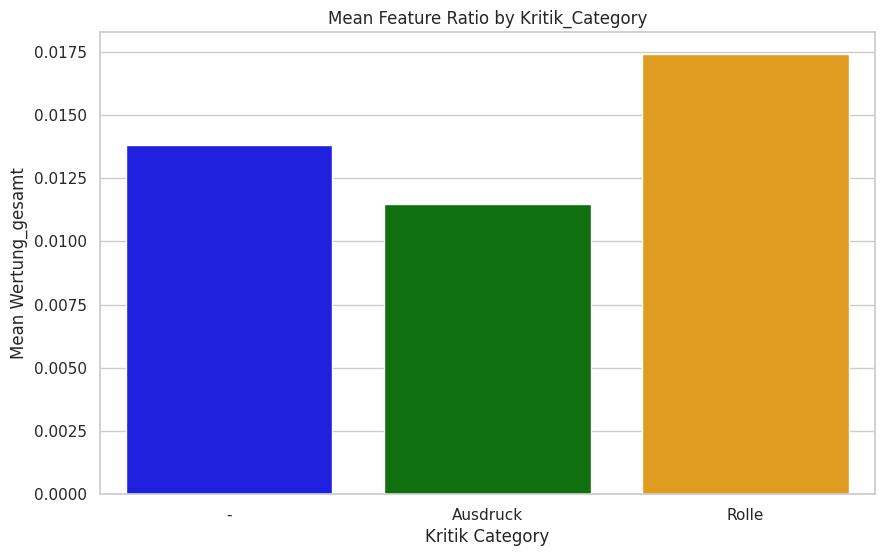

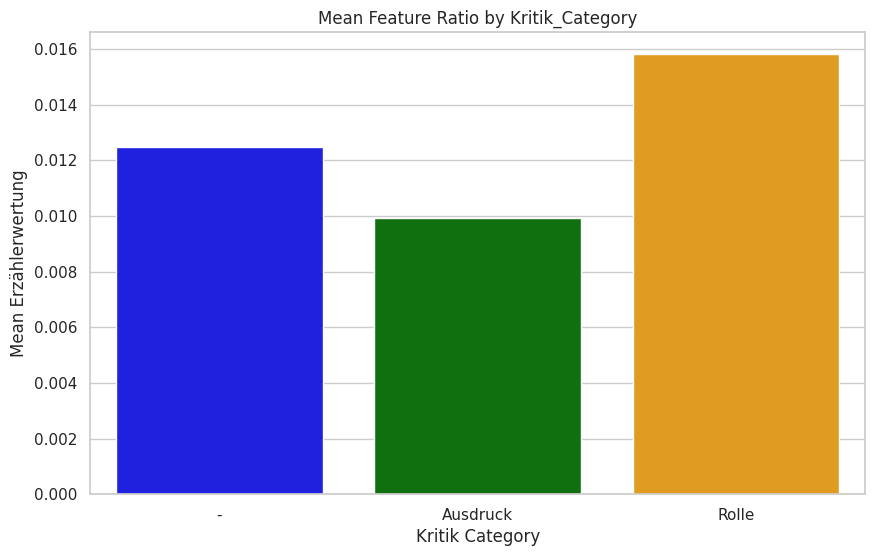

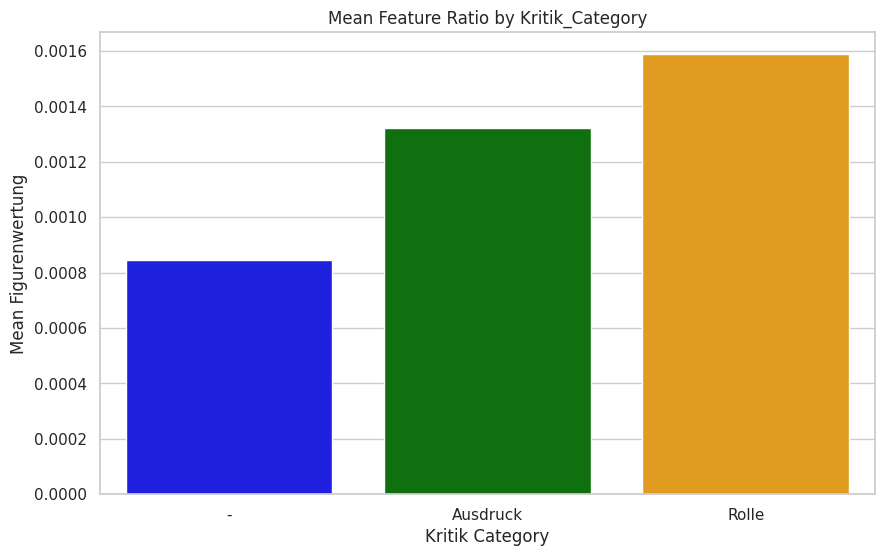

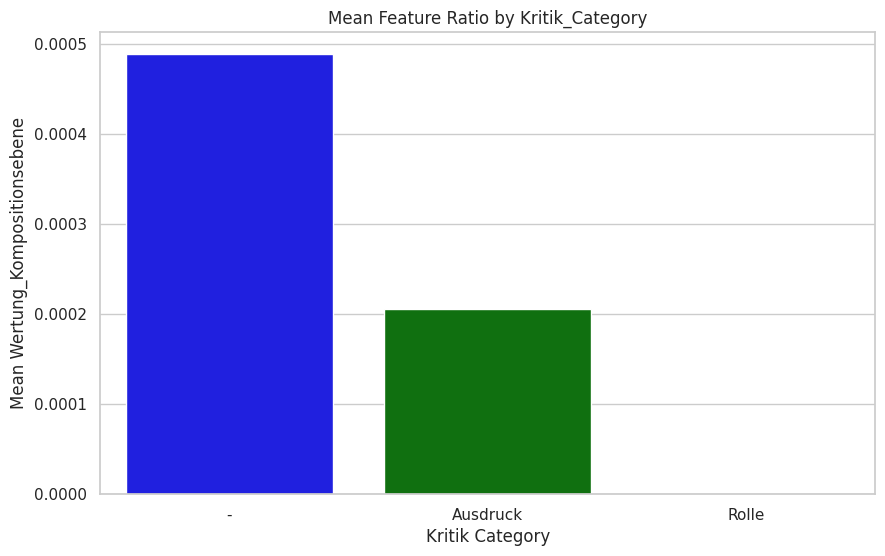

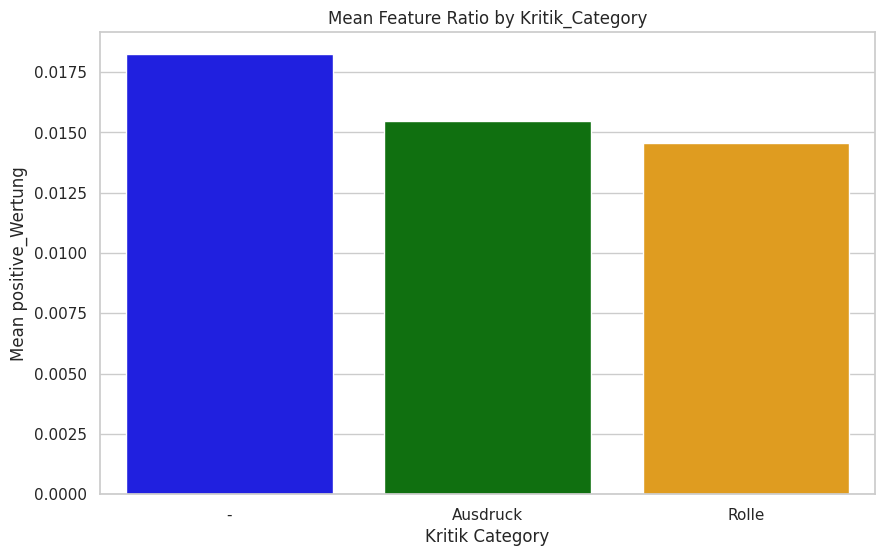

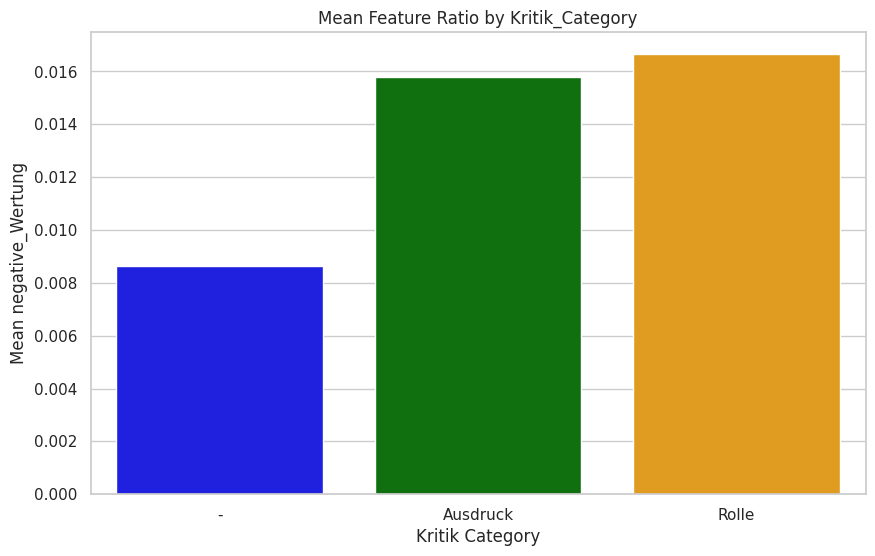

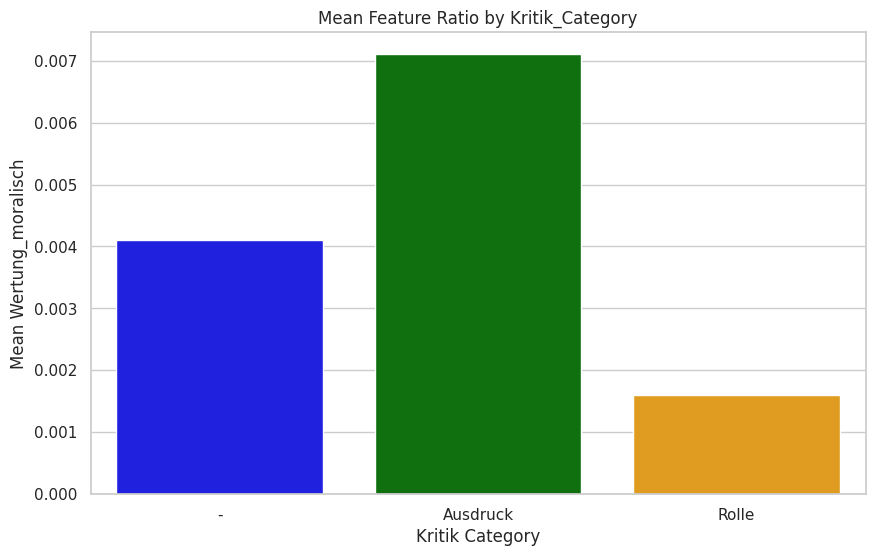

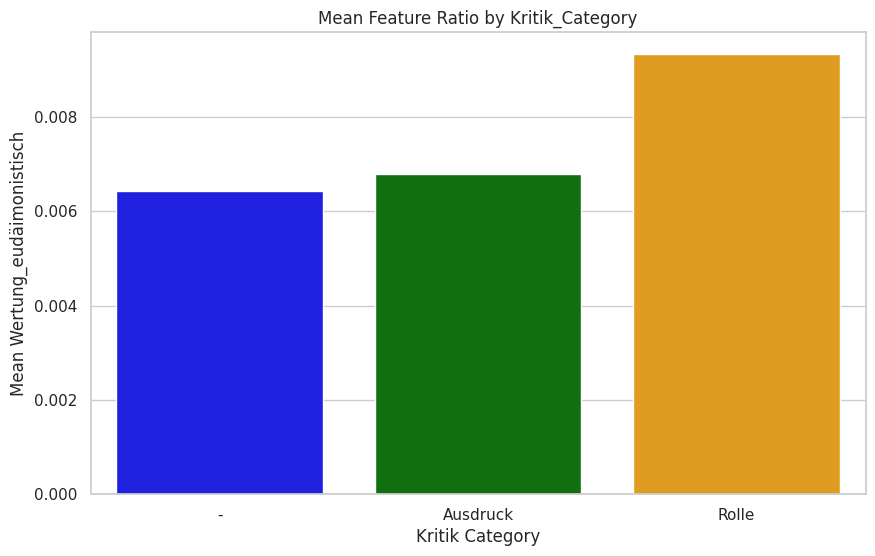

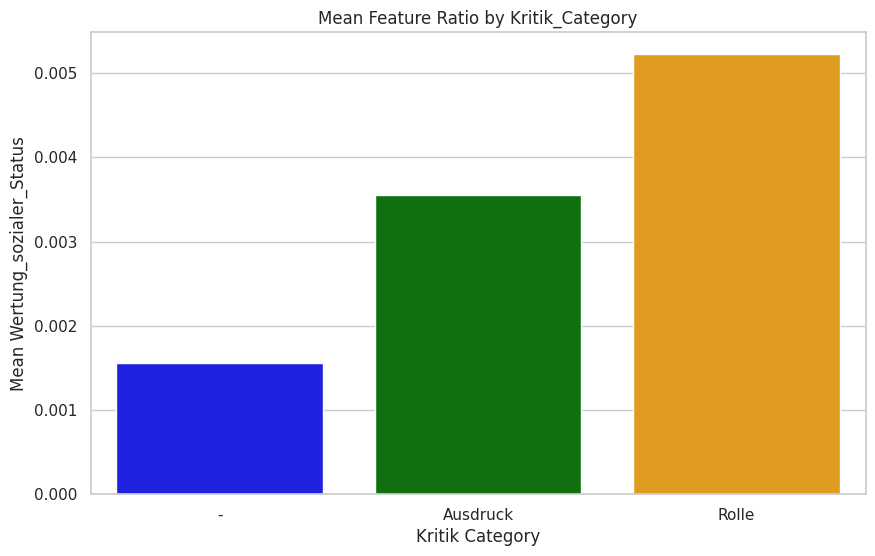

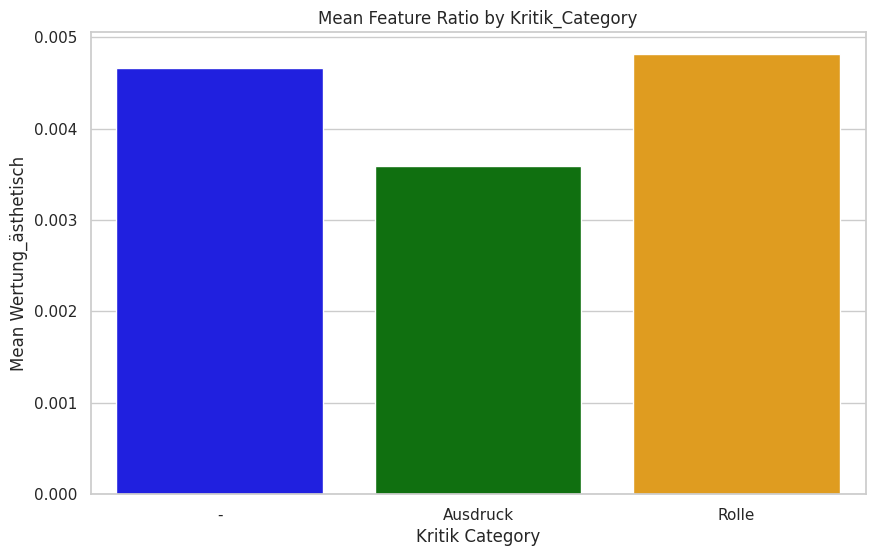

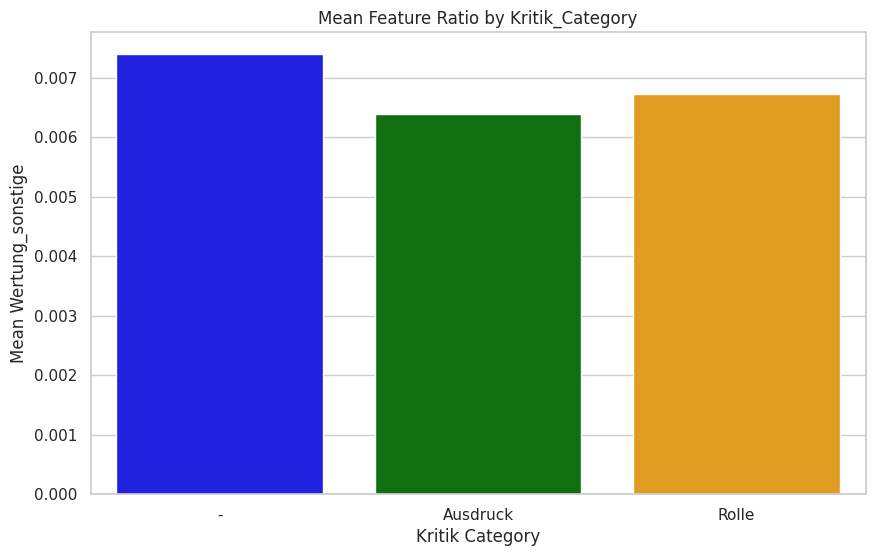

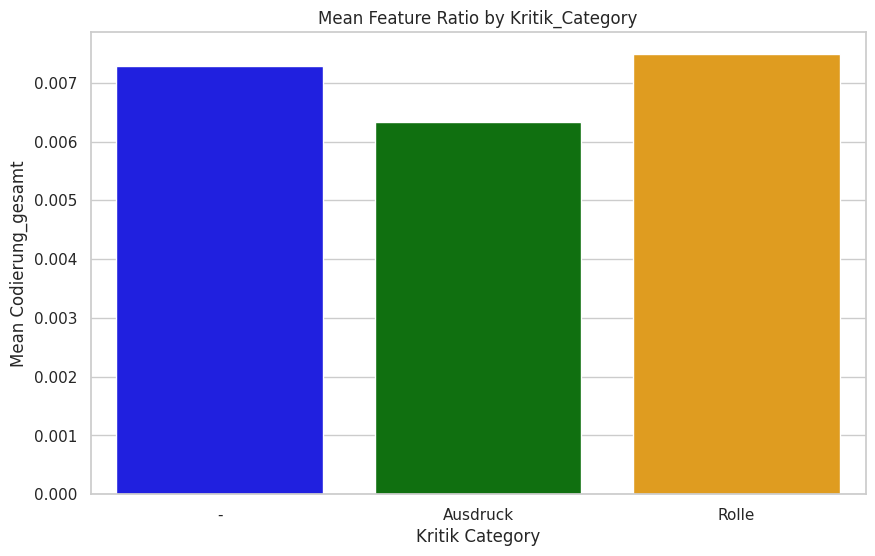

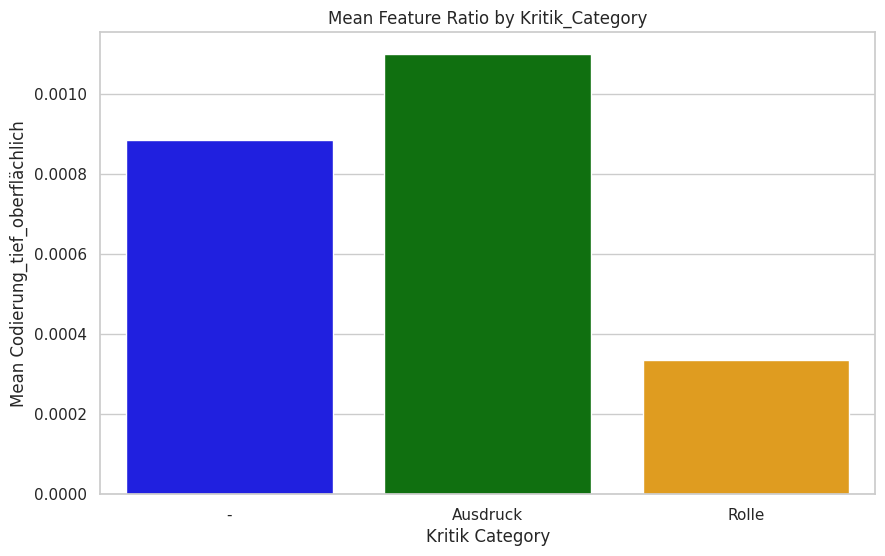

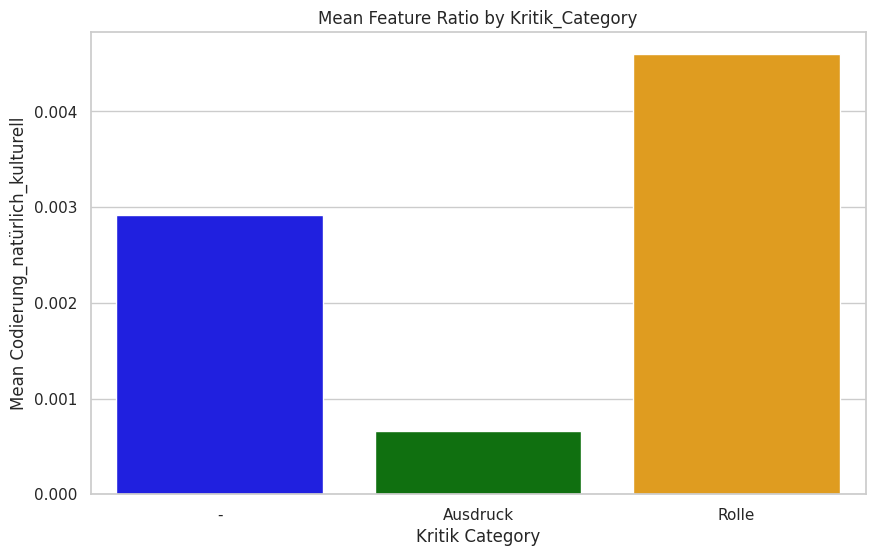

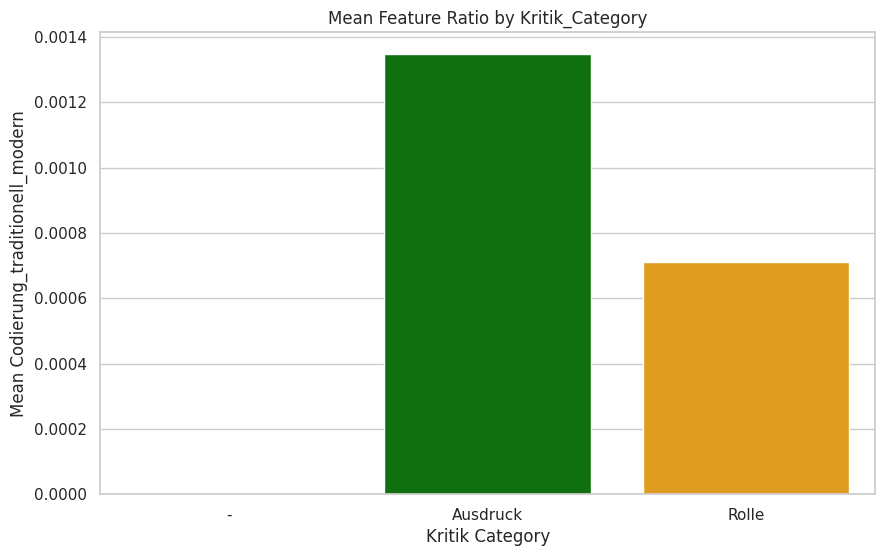

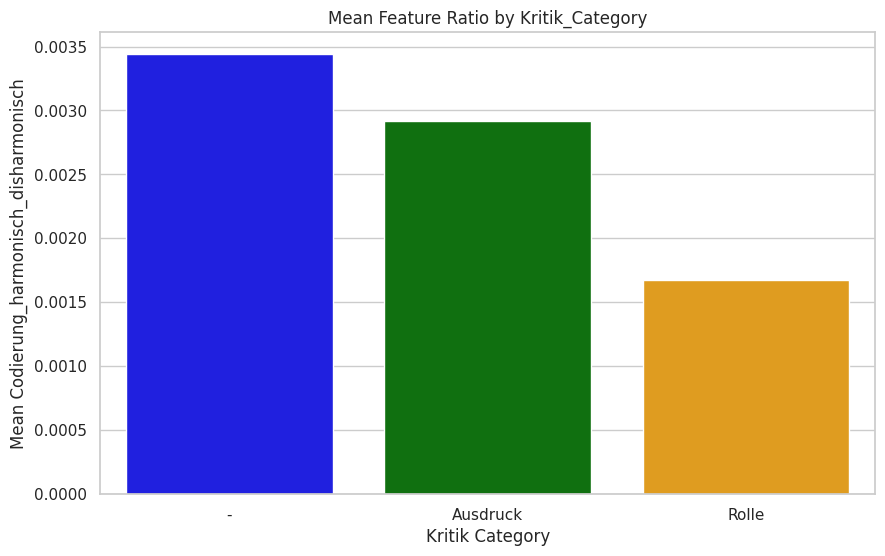

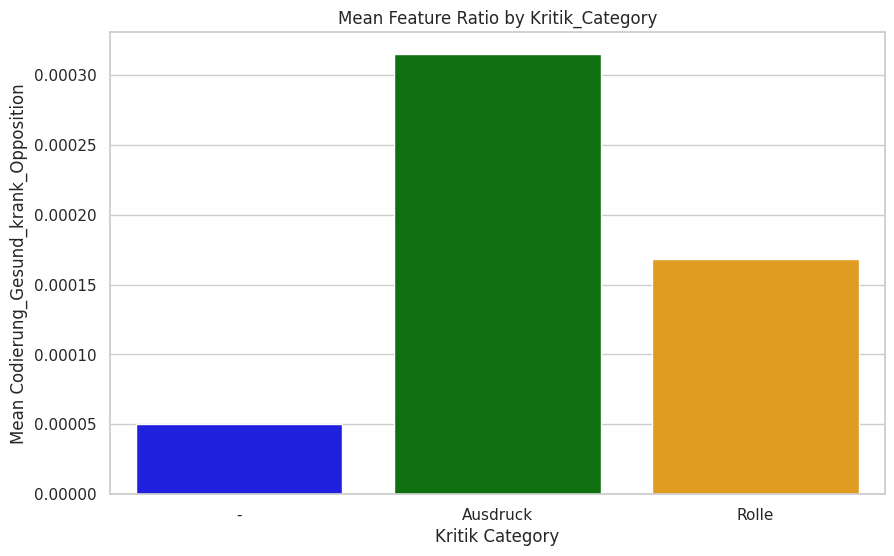

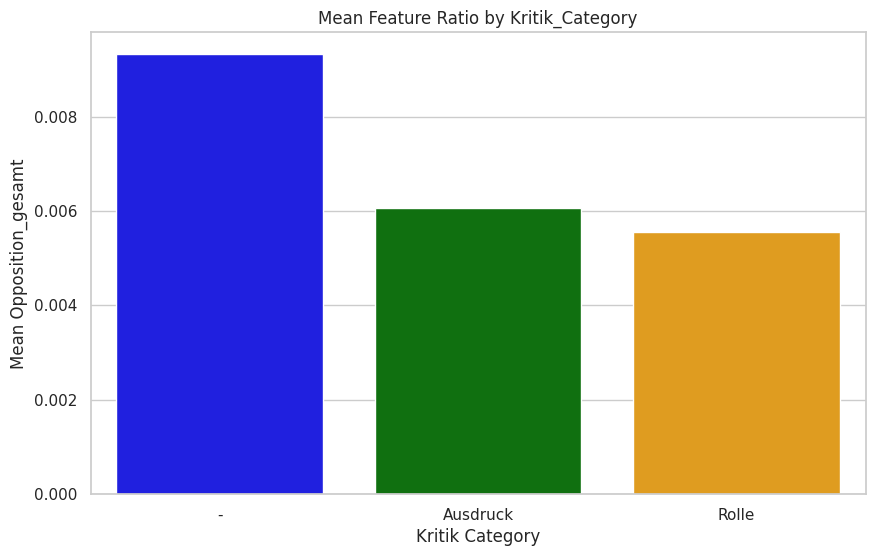

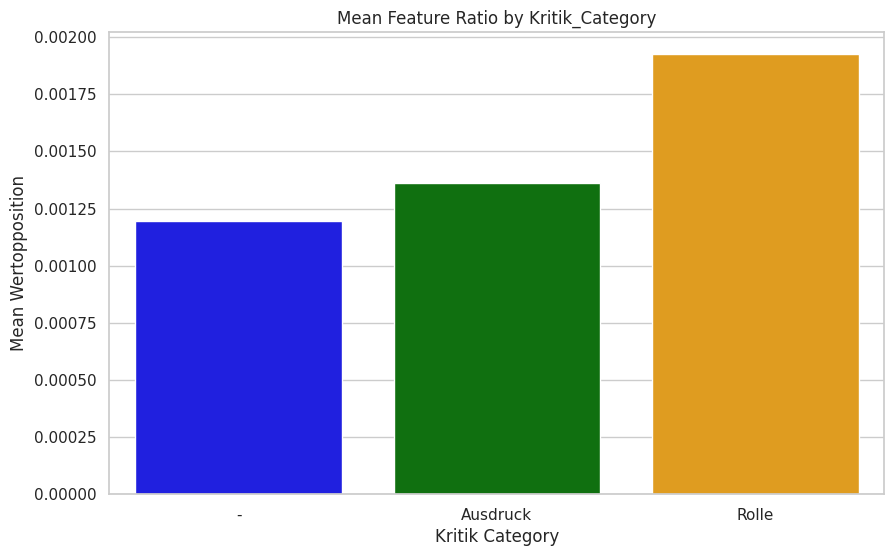

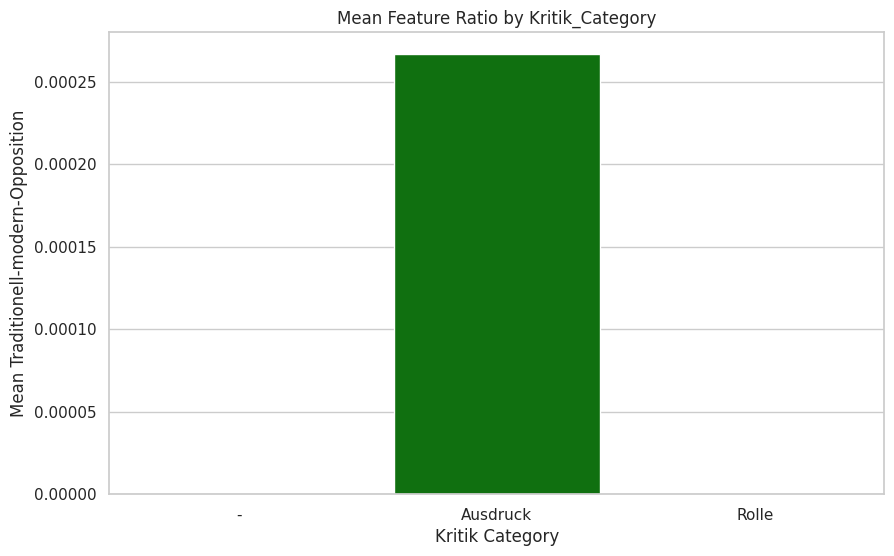

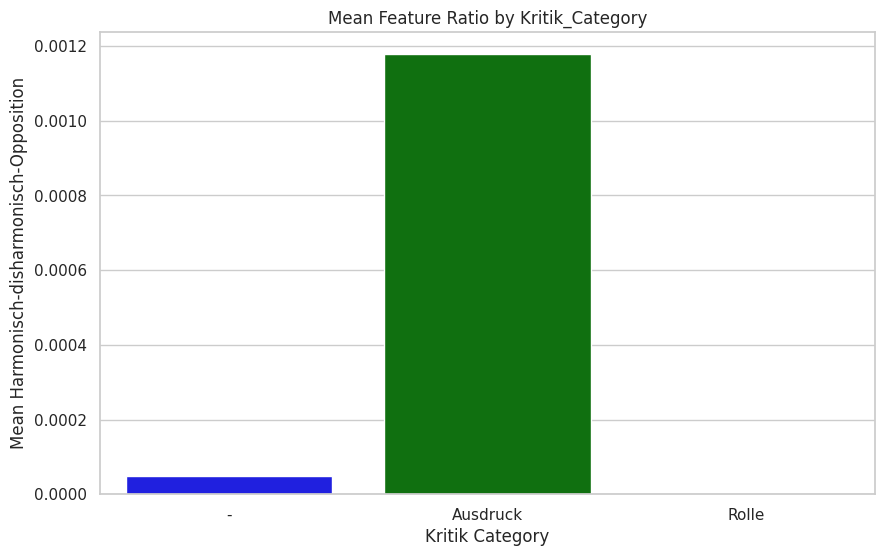

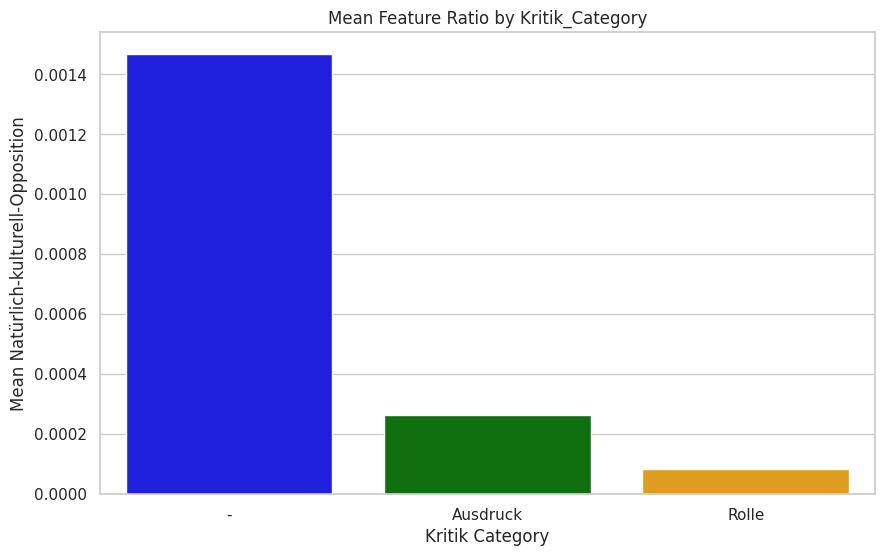

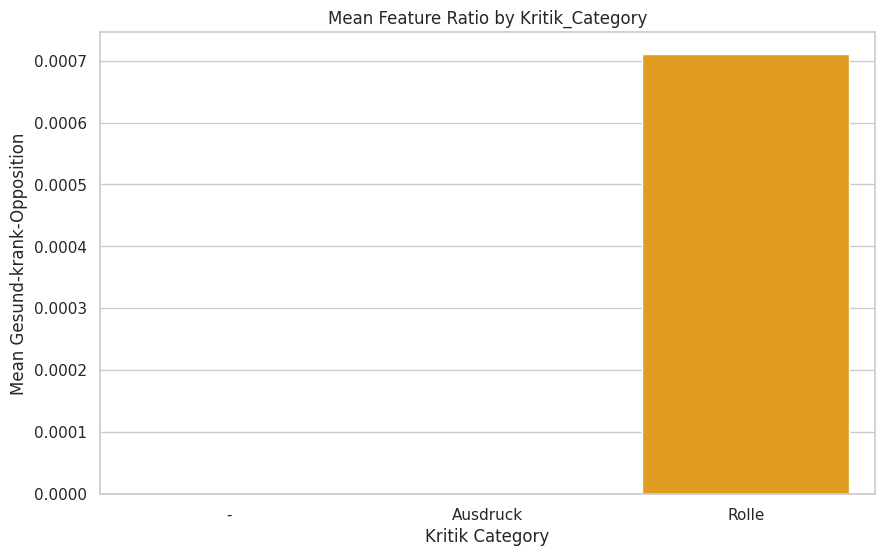

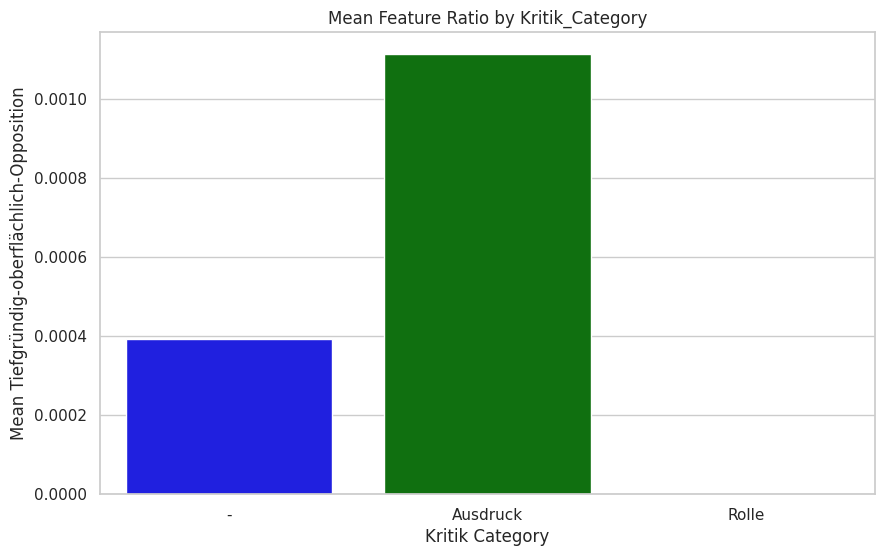

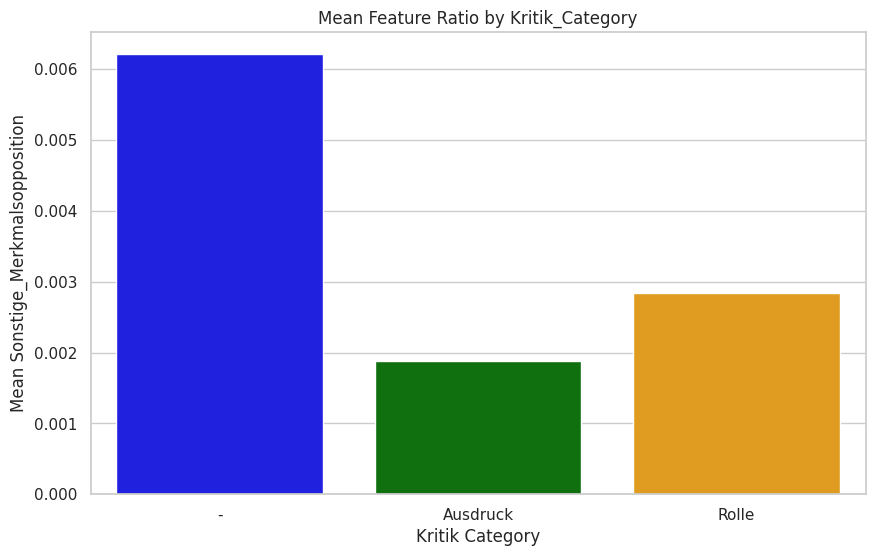

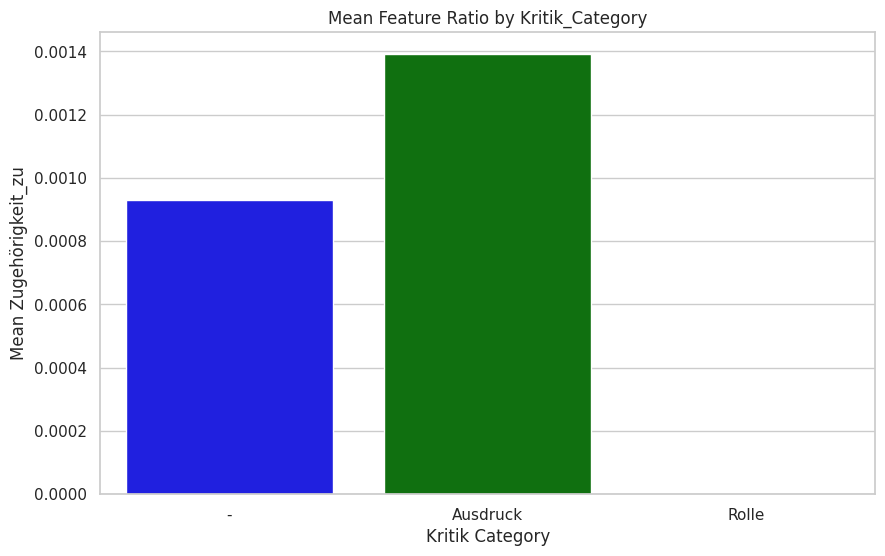

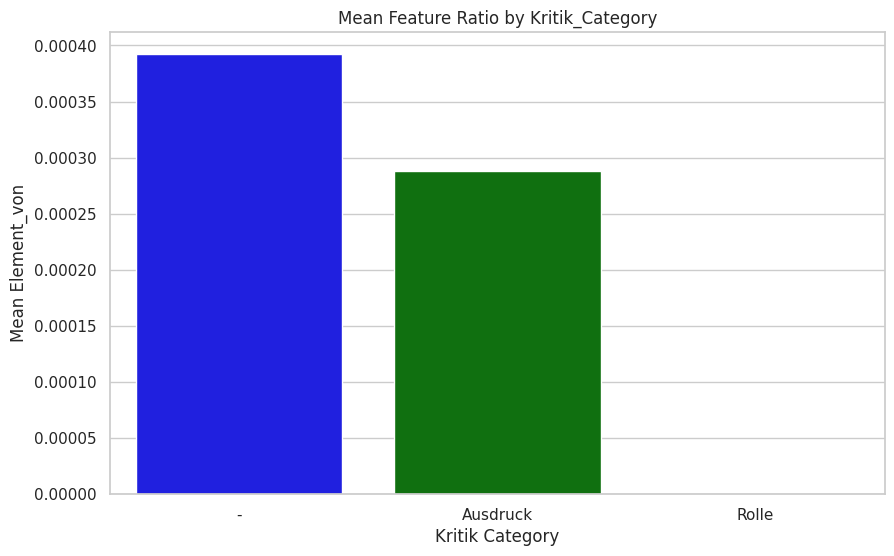

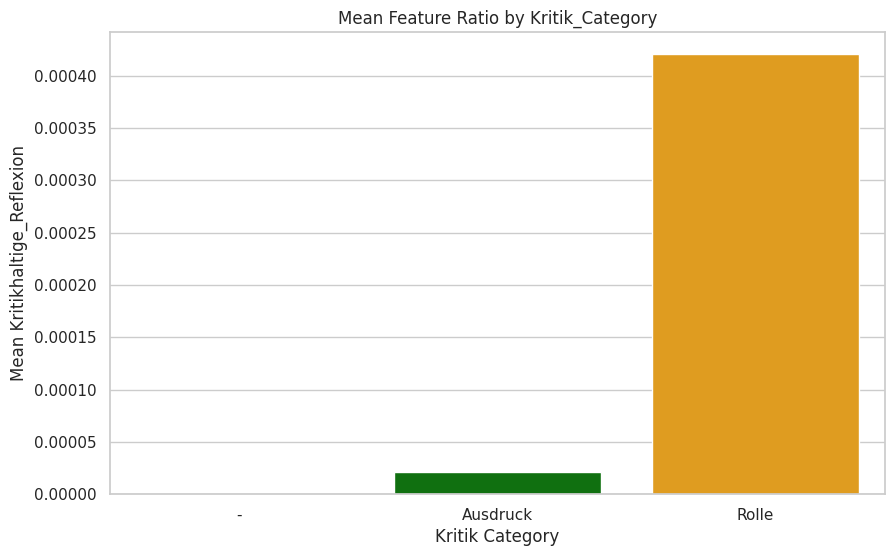

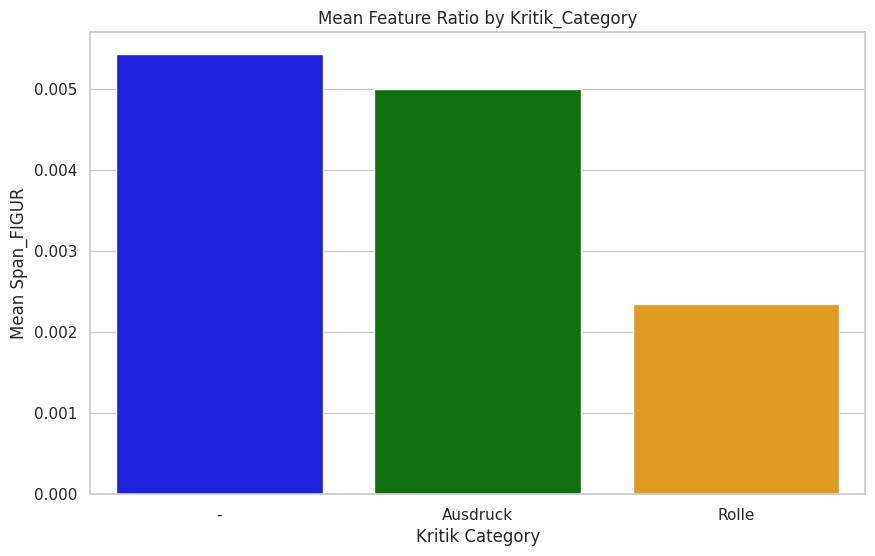

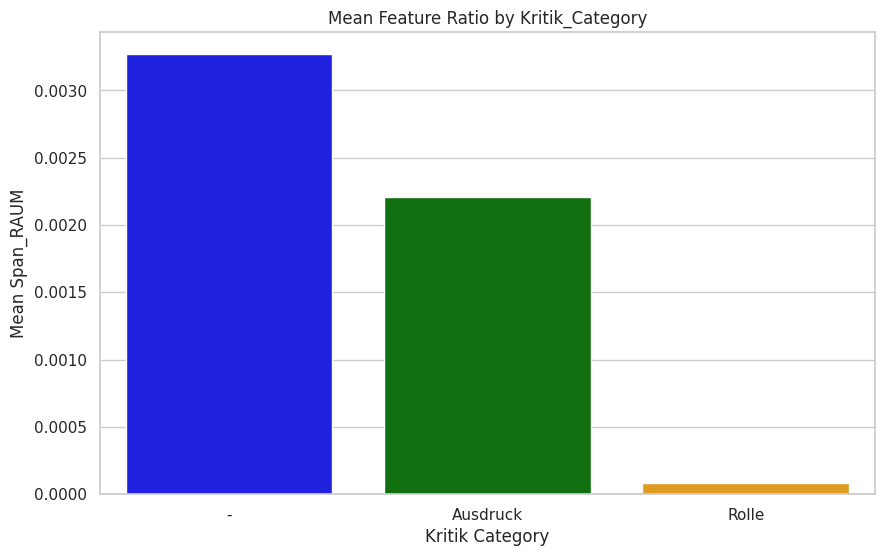

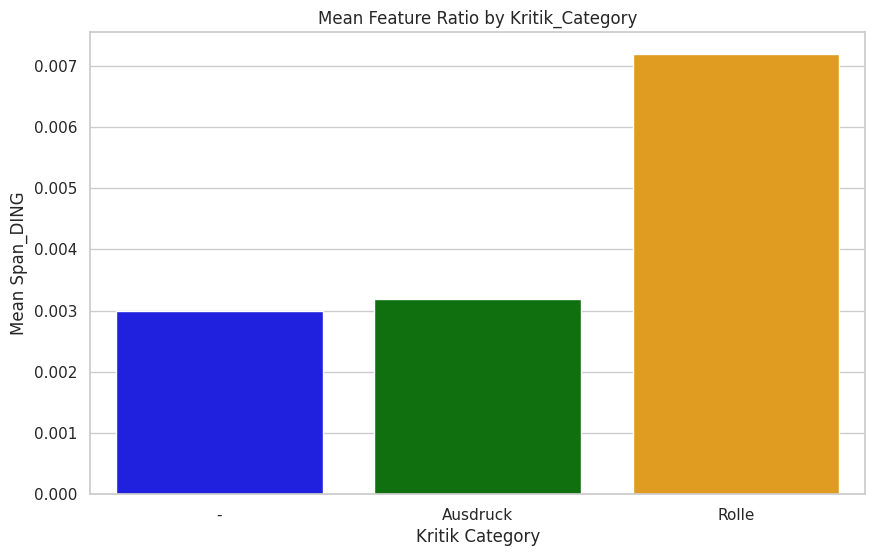

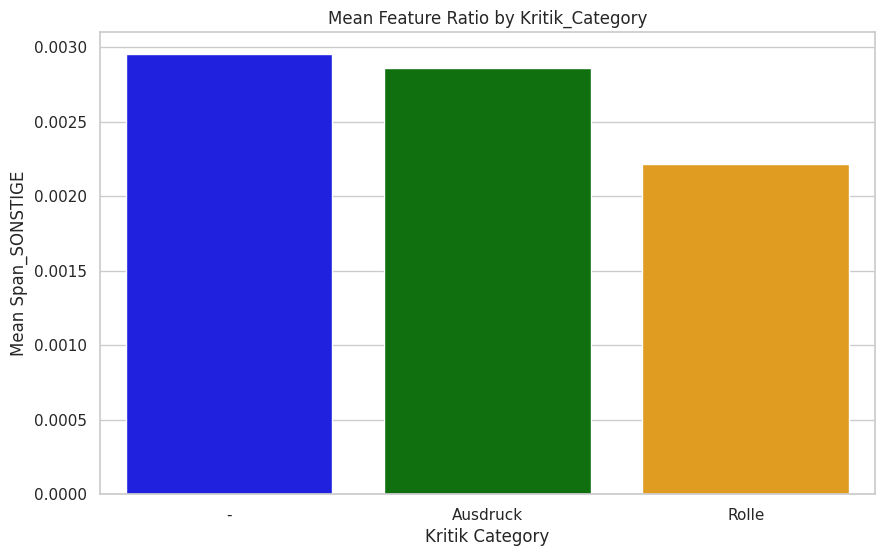

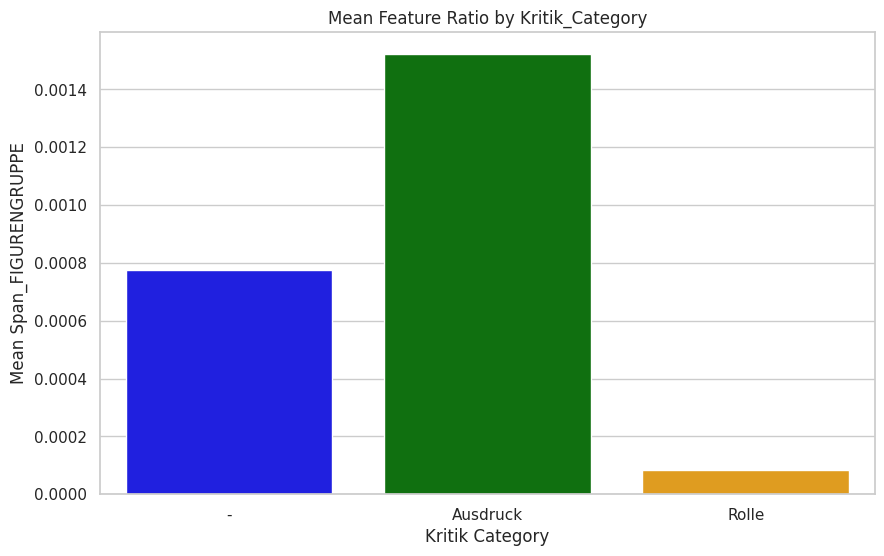

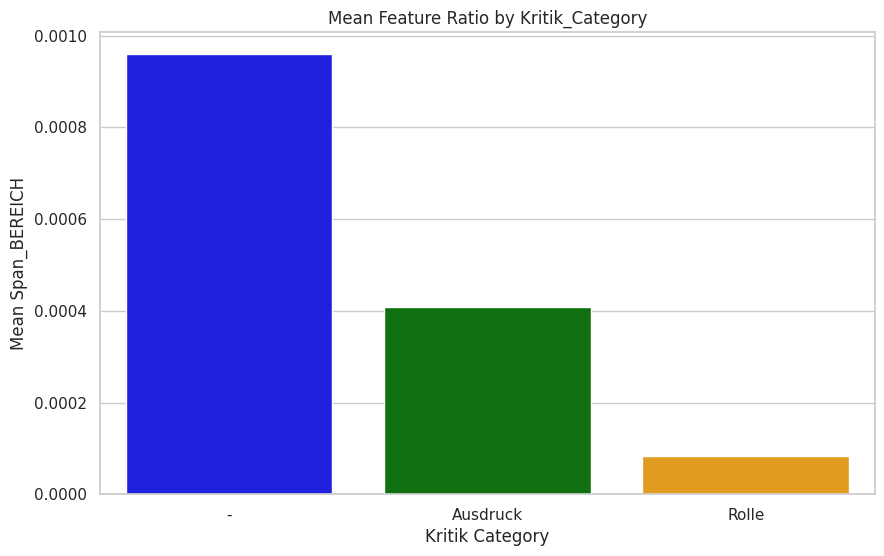

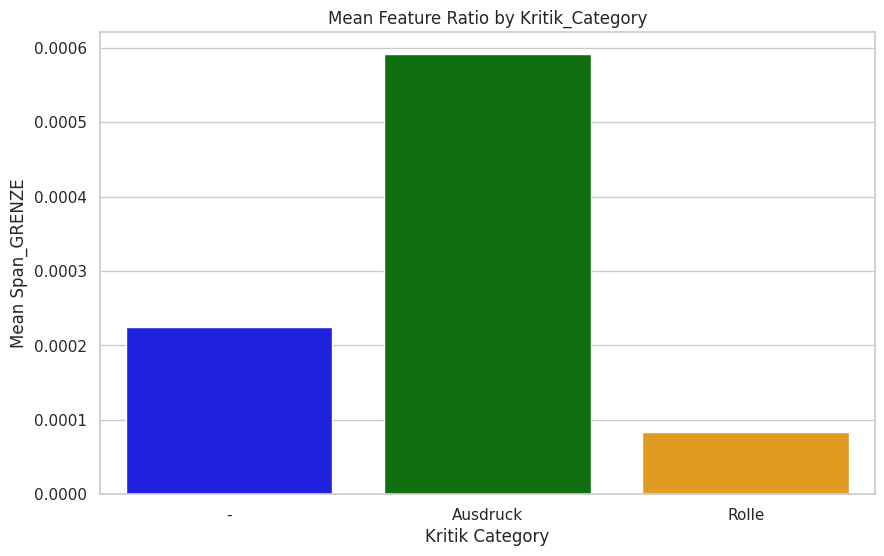

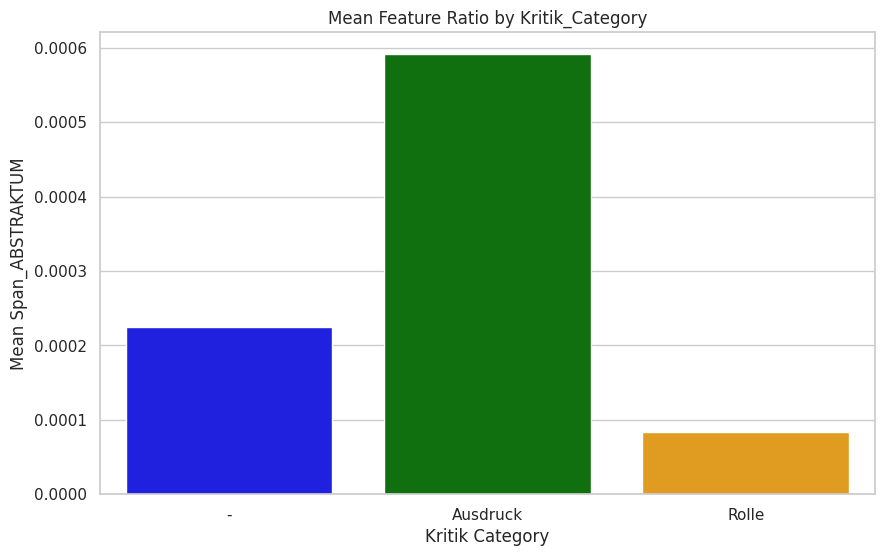

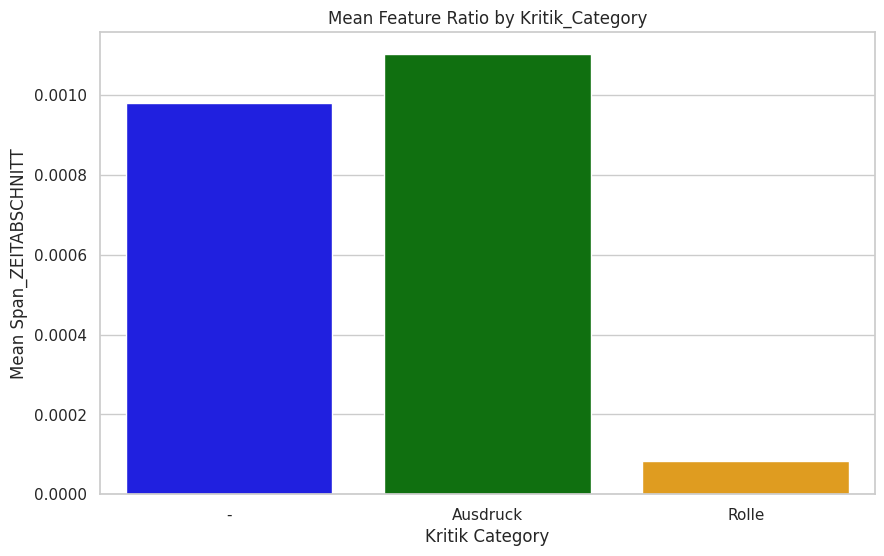

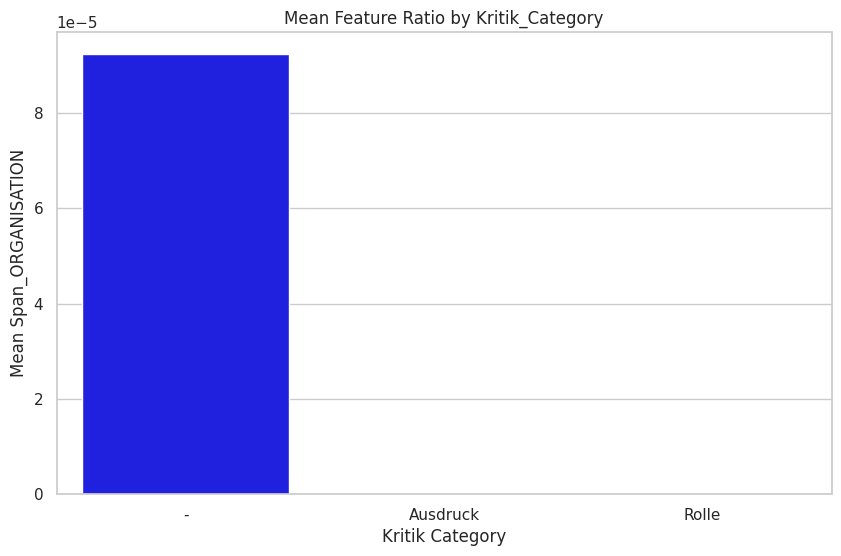

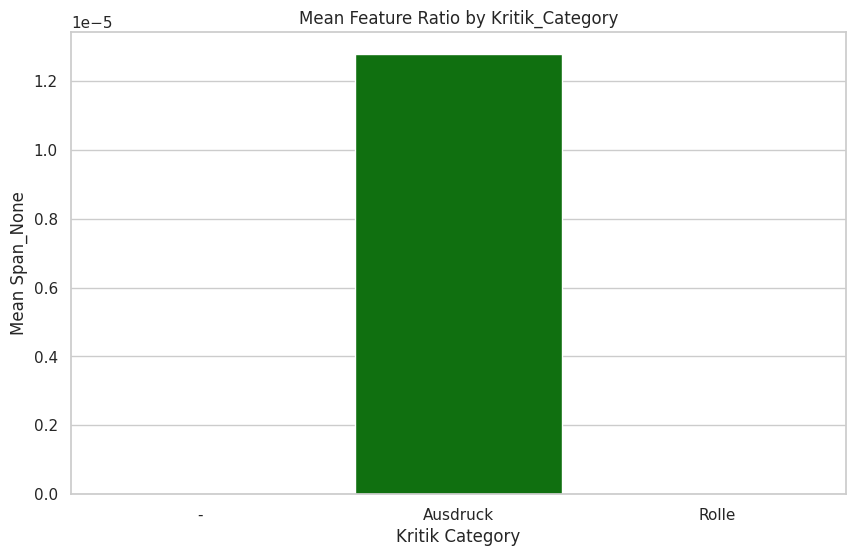

In [ ]:
#Charts for Kritik_Category
# Load data from CSV file
file_path = 'charts.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(file_path,encoding='ISO-8859-1')

categories=['Kritik_Category']

columns=['Wertung_gesamt',
'Erzählerwertung',
'Figurenwertung',
'Wertung_Kompositionsebene',
'positive_Wertung',
'negative_Wertung',
'Wertung_moralisch',
'Wertung_eudäimonistisch',
'Wertung_sozialer_Status',
'Wertung_ästhetisch',
'Wertung_sonstige',
'Codierung_gesamt',
'Codierung_tief_oberflächlich',
'Codierung_natürlich_kulturell',
'Codierung_traditionell_modern',
'Codierung_harmonisch_disharmonisch',
'Codierung_Gesund_krank',
'Opposition_gesamt',
'Wertopposition',
'Traditionell-modern-Opposition',
'Harmonisch-disharmonisch-Opposition',
'Natürlich-kulturell-Opposition',
'Gesund-krank-Opposition',
'Tiefgründig-oberflächlich-Opposition',
'Sonstige_Merkmalsopposition',
'Zugehörigkeit_zu',
'Element_von',
'Kritikhaltige_Reflexion',
'Span_FIGUR',
'Span_RAUM',
'Span_DING',
'Span_SONSTIGE',
'Span_FIGURENGRUPPE',
'Span_BEREICH',
'Span_GRENZE',
'Span_ABSTRAKTUM',
'Span_ZEITABSCHNITT',
'Span_ORGANISATION',
'Span_None'
]

# Define directory to save charts
save_dir = 'charts_directory'  # Replace with the desired directory name
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist


for category in categories:
  print('Charts for ',category)
  for column in columns:
    # Group by 'Category' and calculate the mean
    mean_values = df.groupby(categories)[column].mean().reset_index()

    # Plotting the data with Seaborn
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=category, y=column, hue=category, data=mean_values, palette=['blue', 'green', 'orange'], legend=False)
    x_label = 'Mean Feature Ratio by ' + category
    ax.set_title(x_label)
    y_label='Mean ' + column
    ax.set_ylabel(y_label)
    ax.set_xlabel('Kritik Category')
    plt.show()
    print('\n')


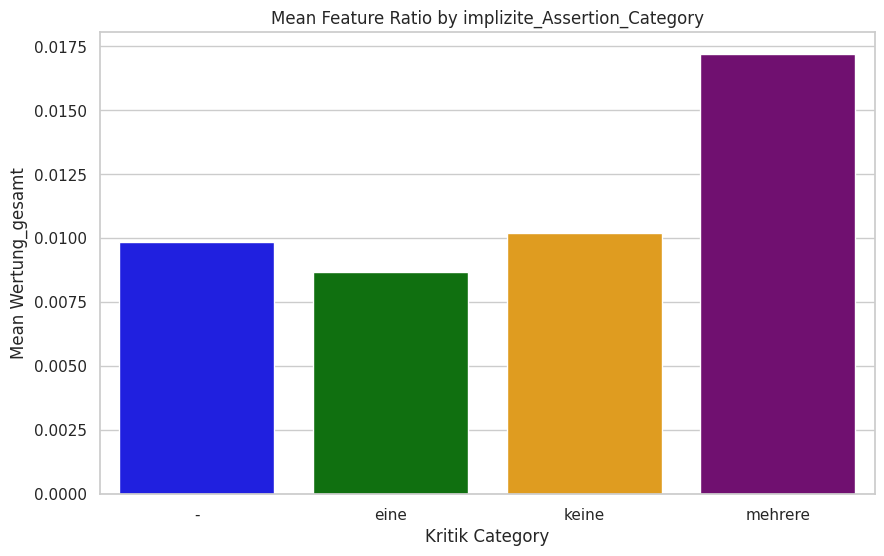

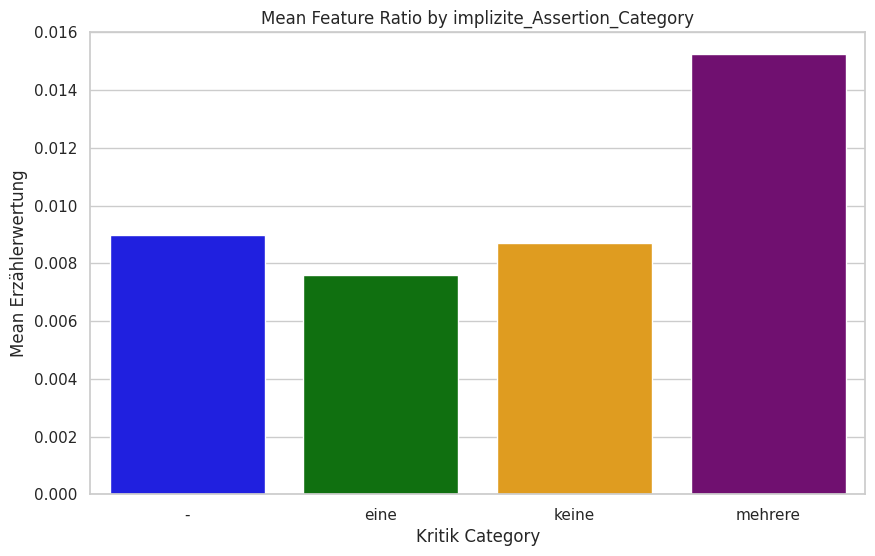

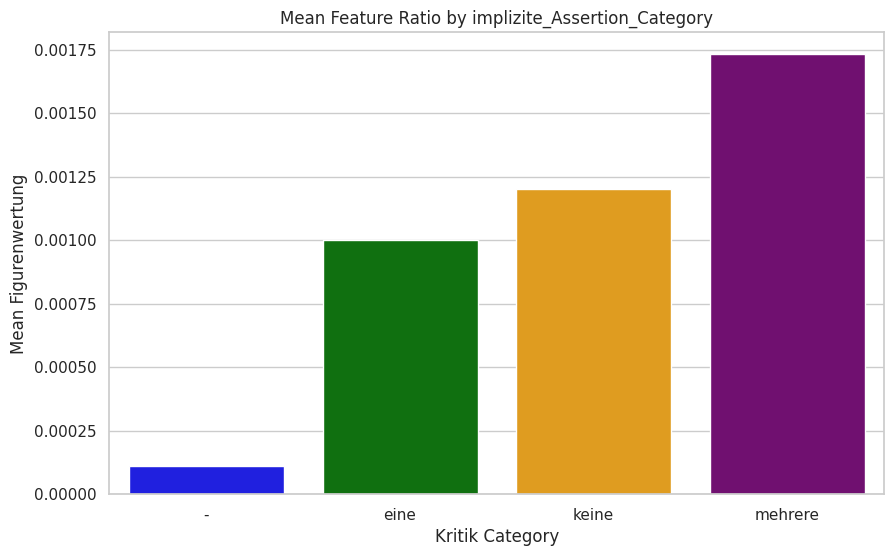

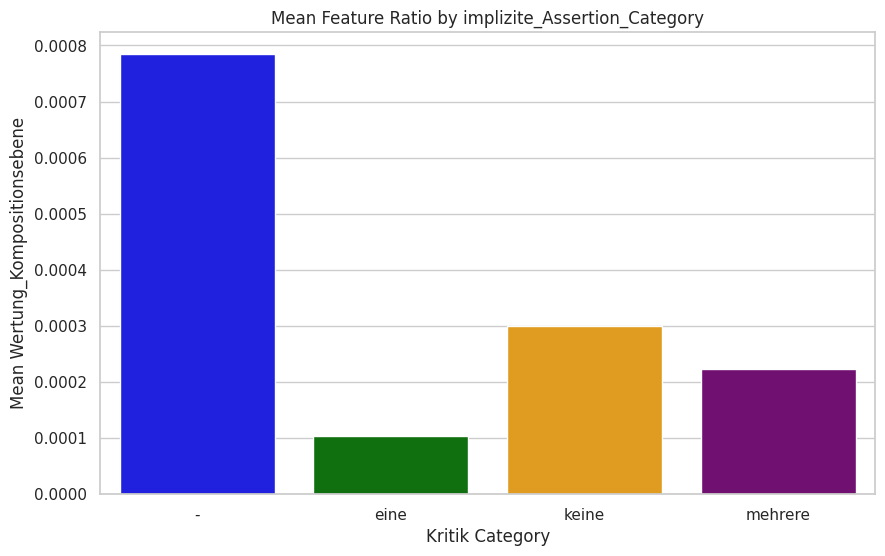

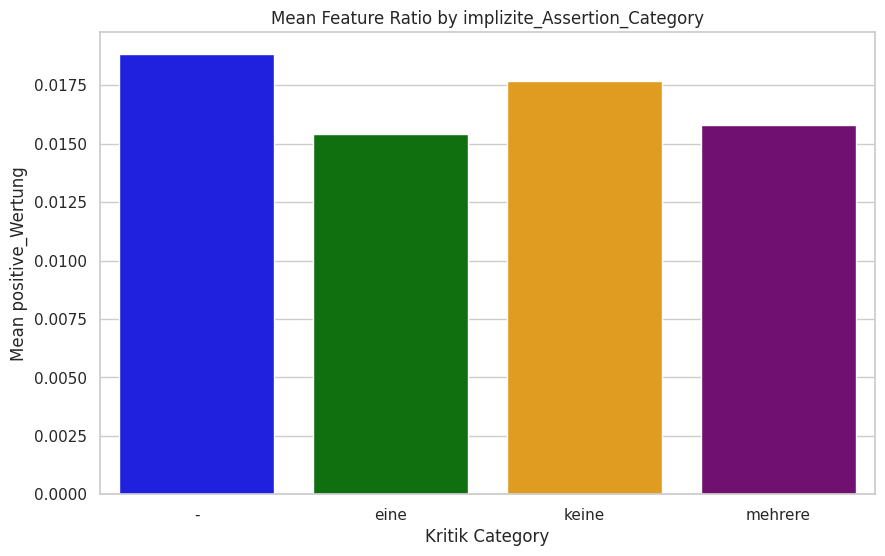

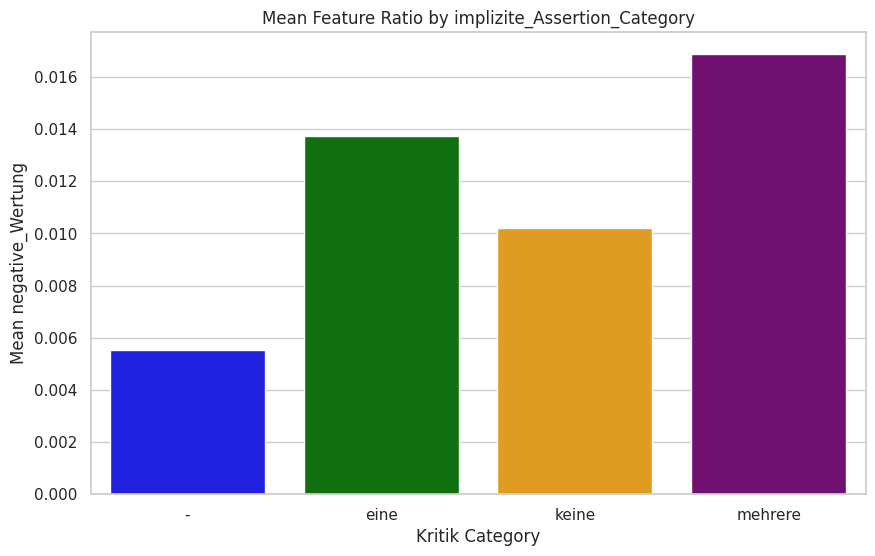

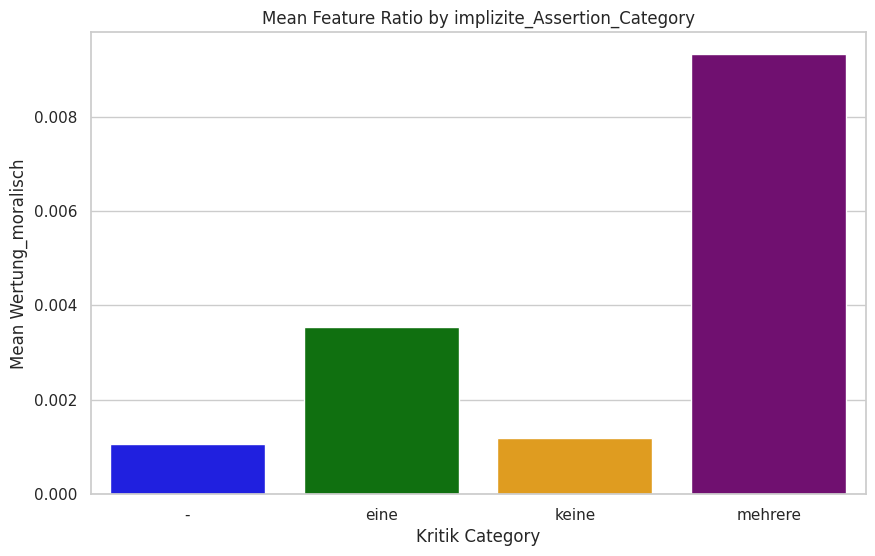

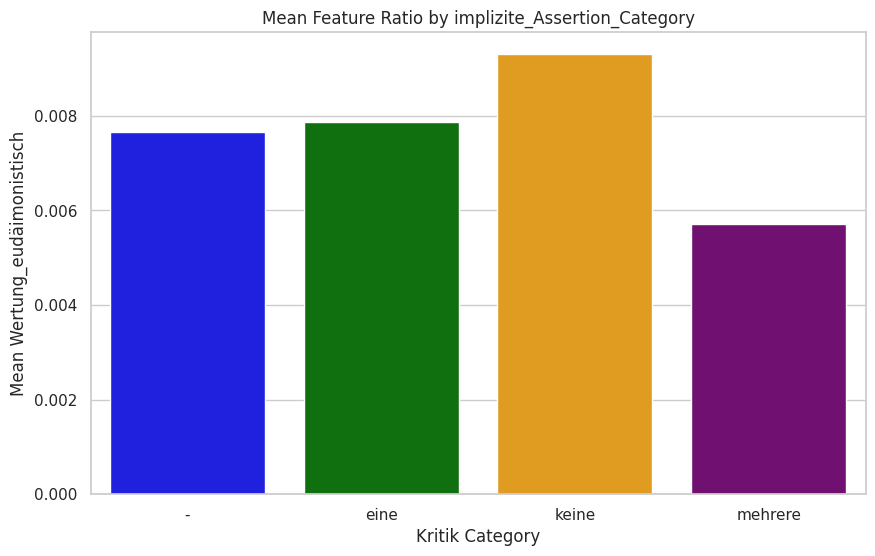

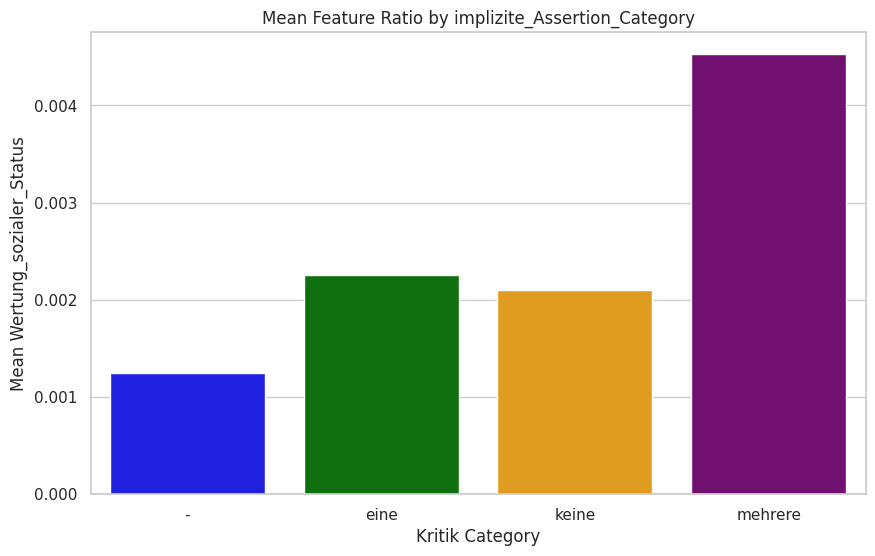

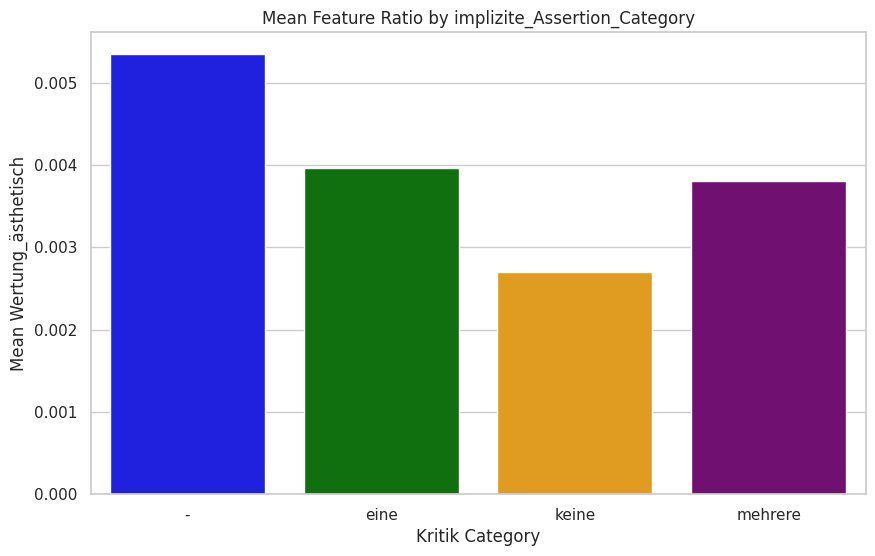

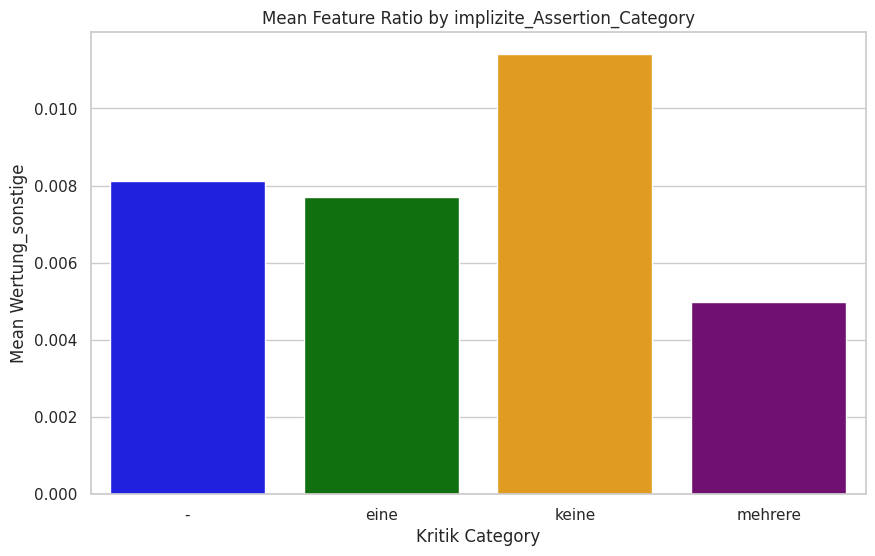

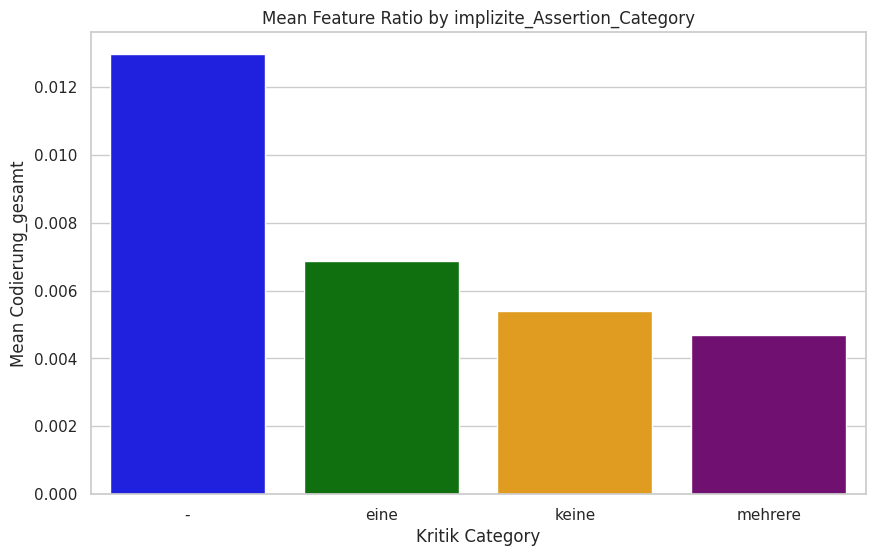

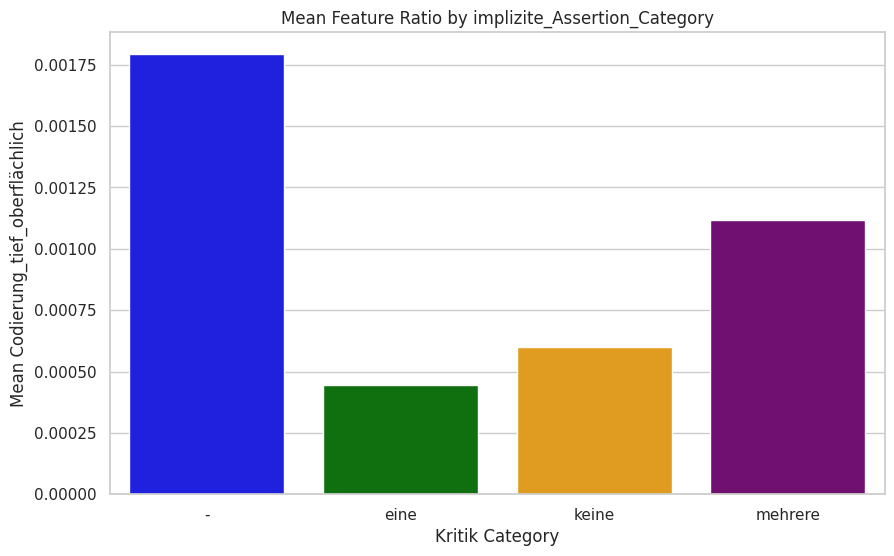

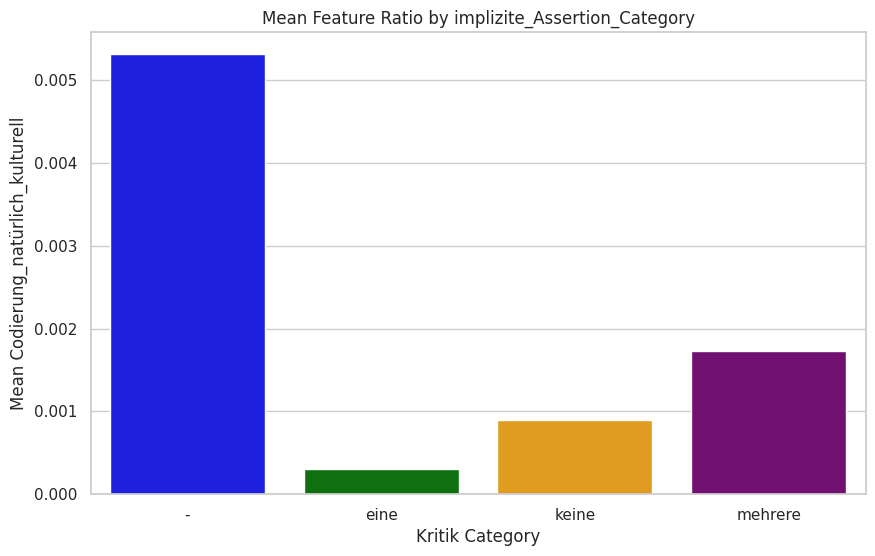

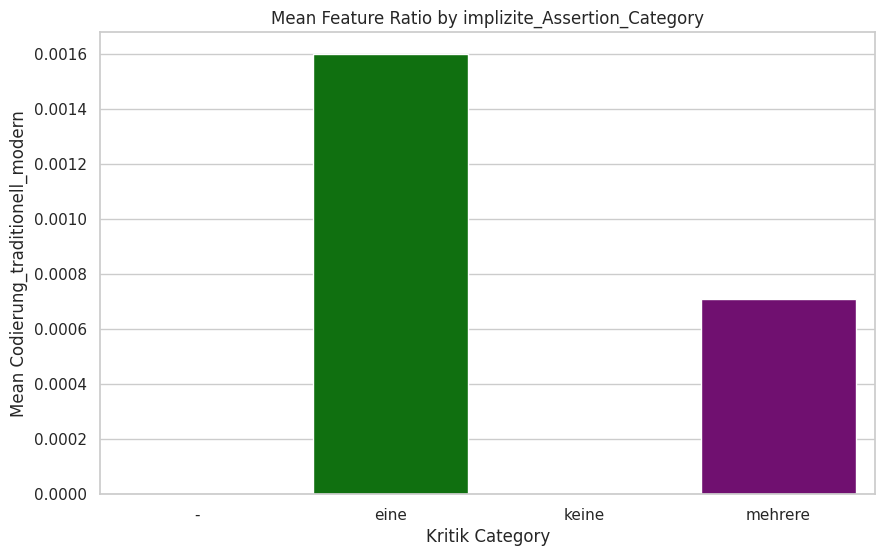

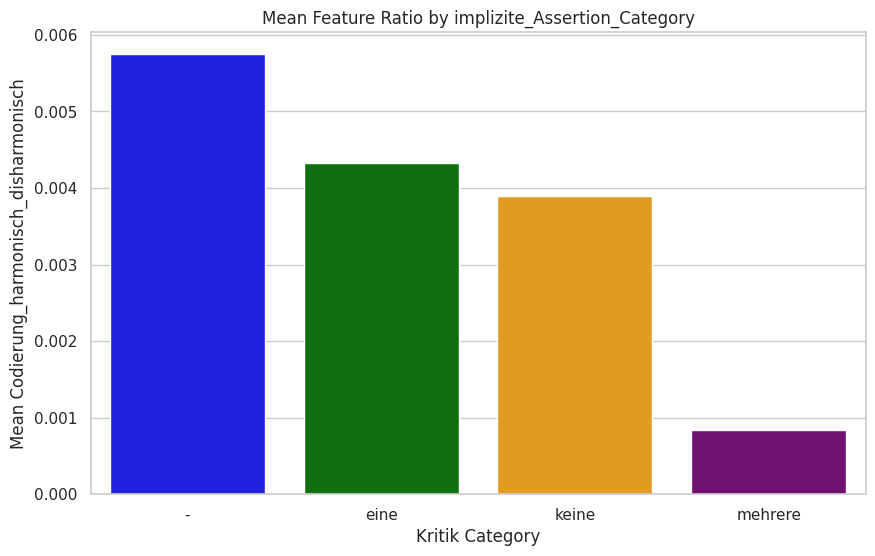

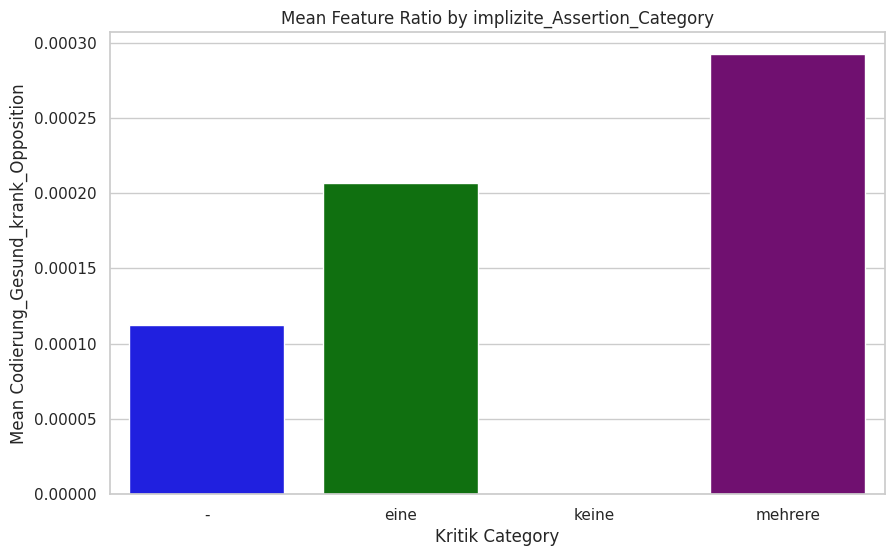

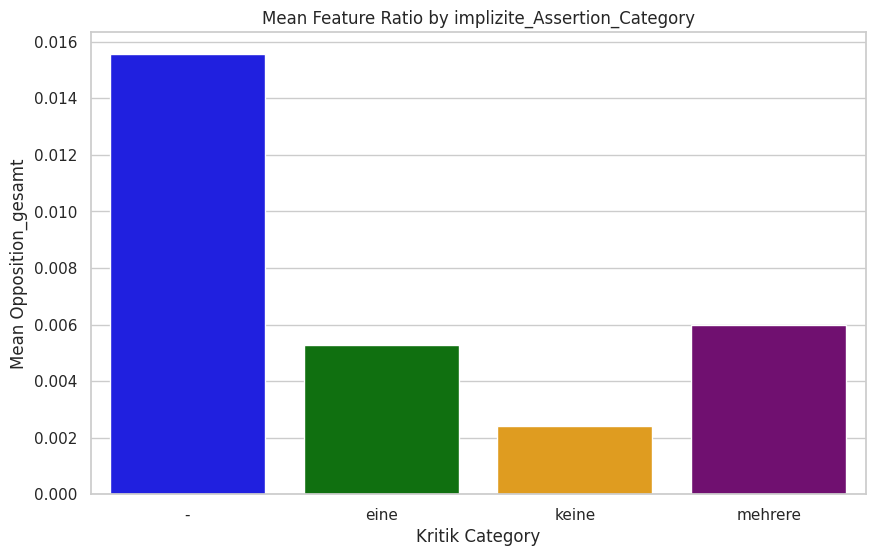

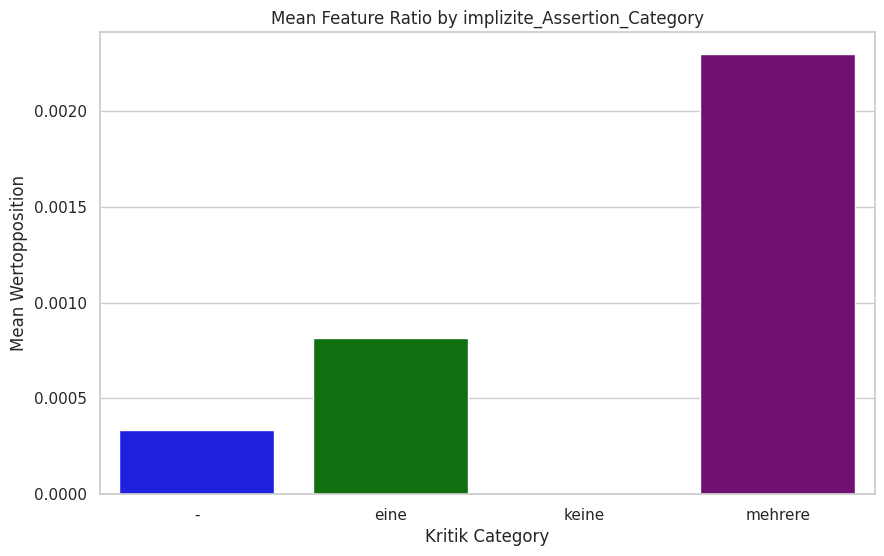

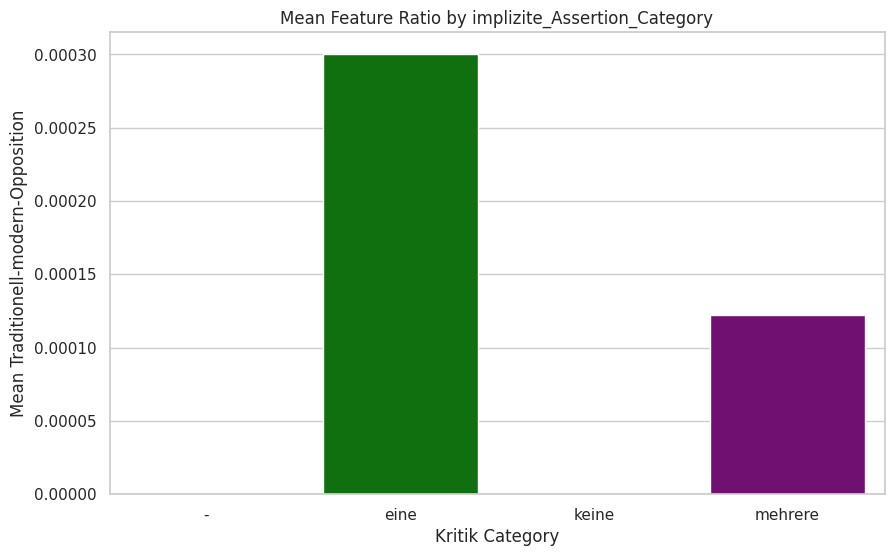

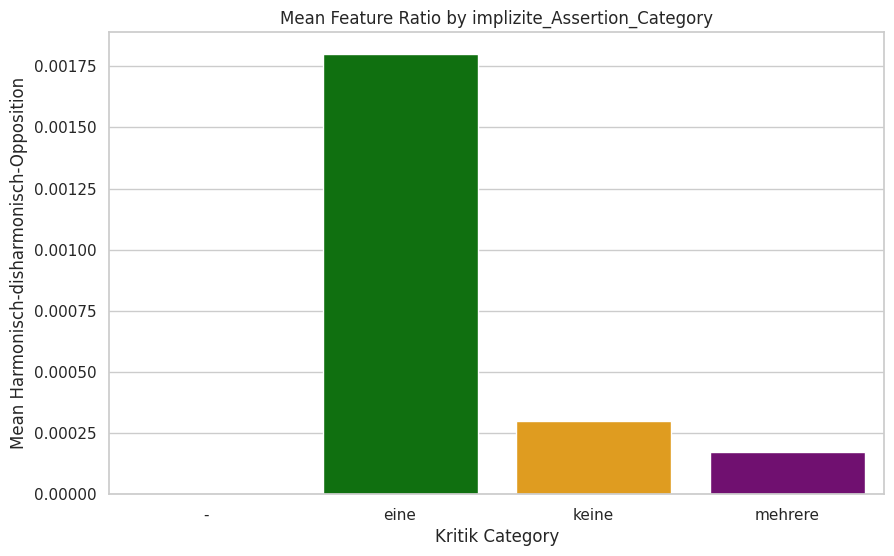

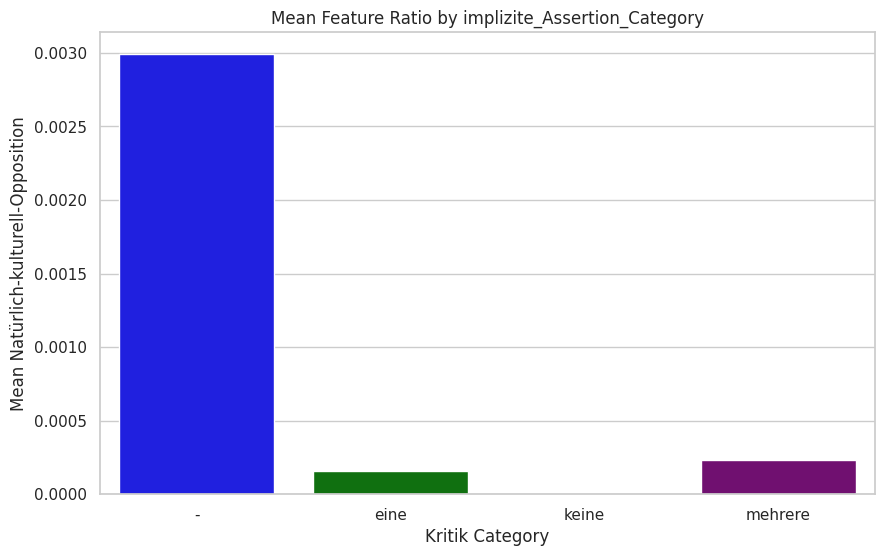

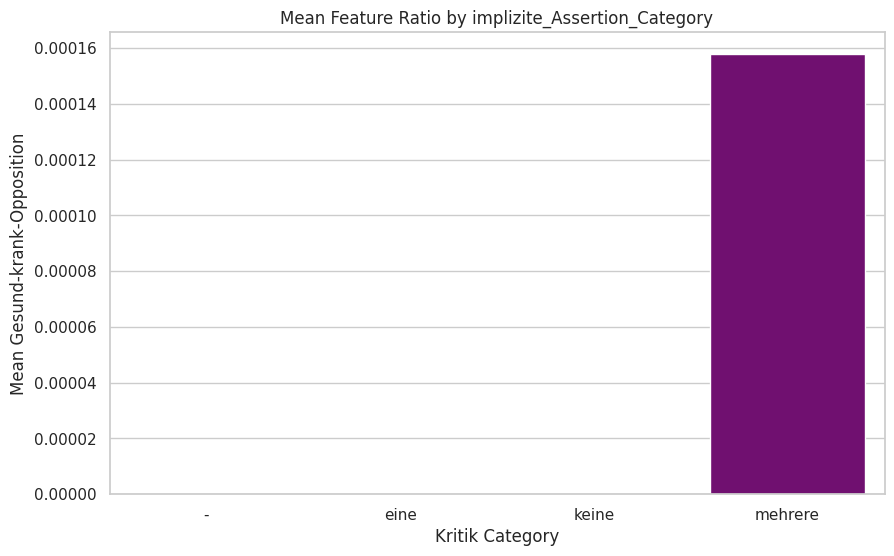

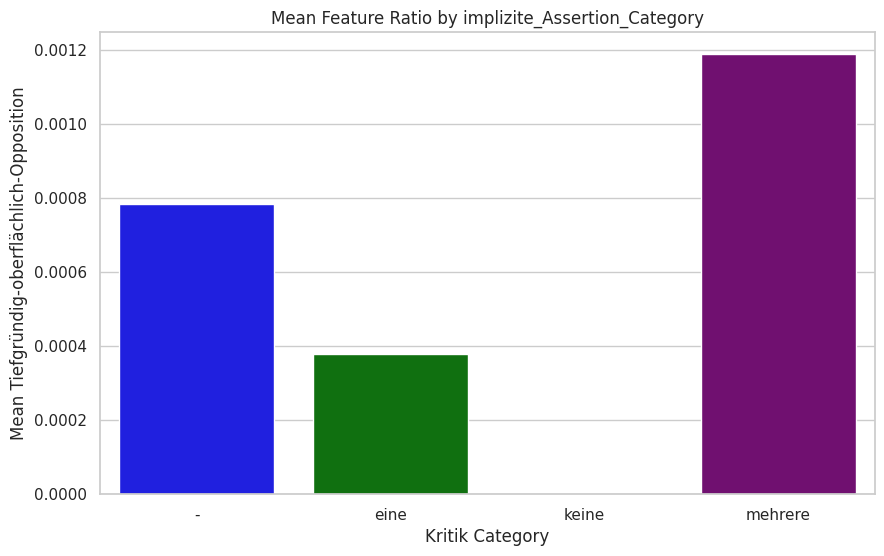

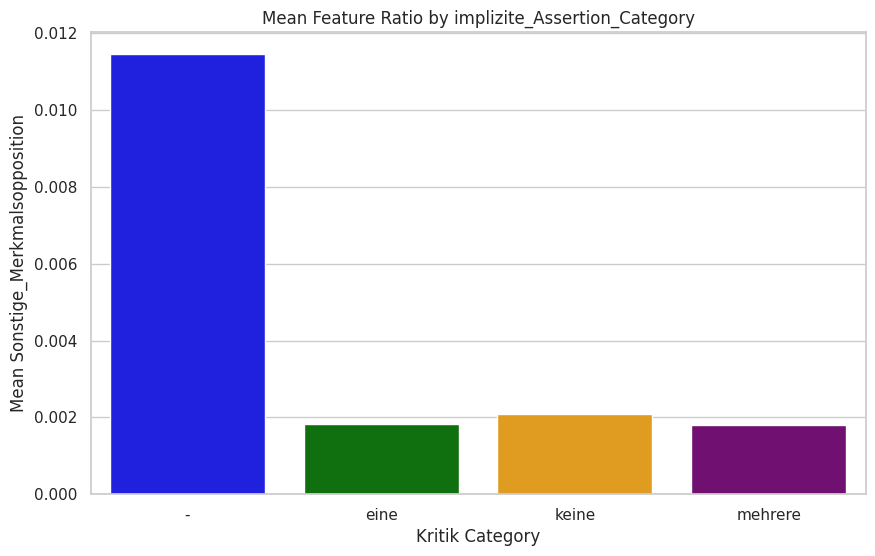

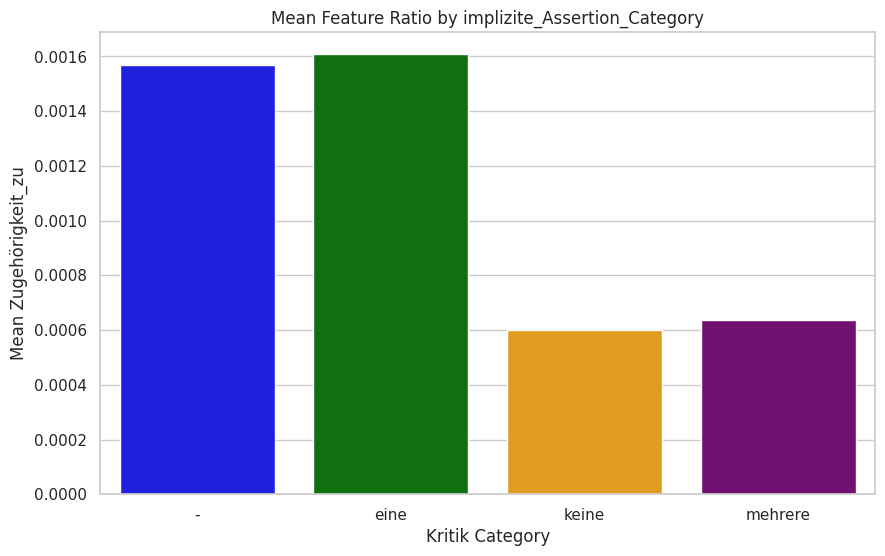

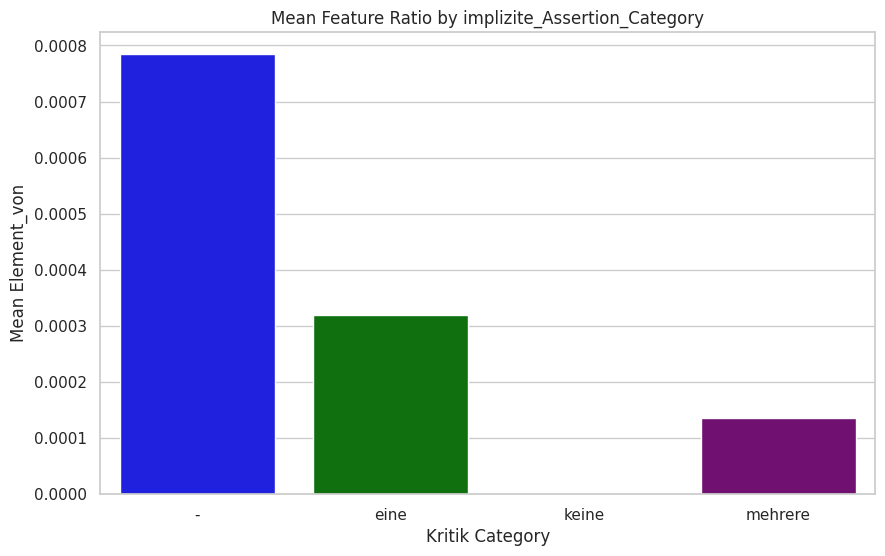

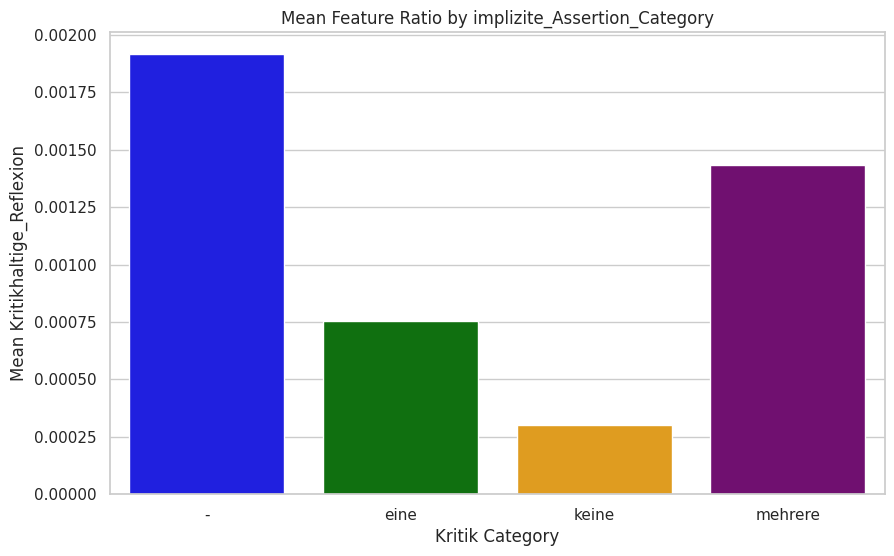

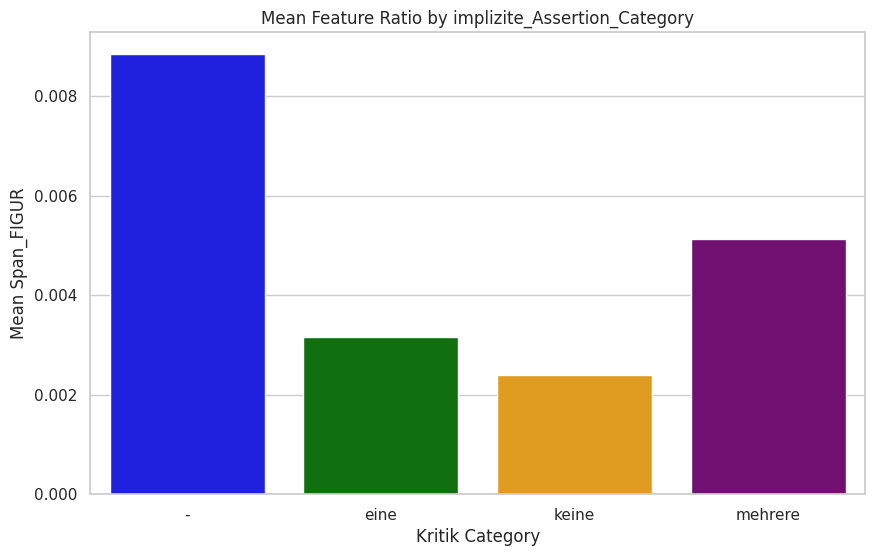

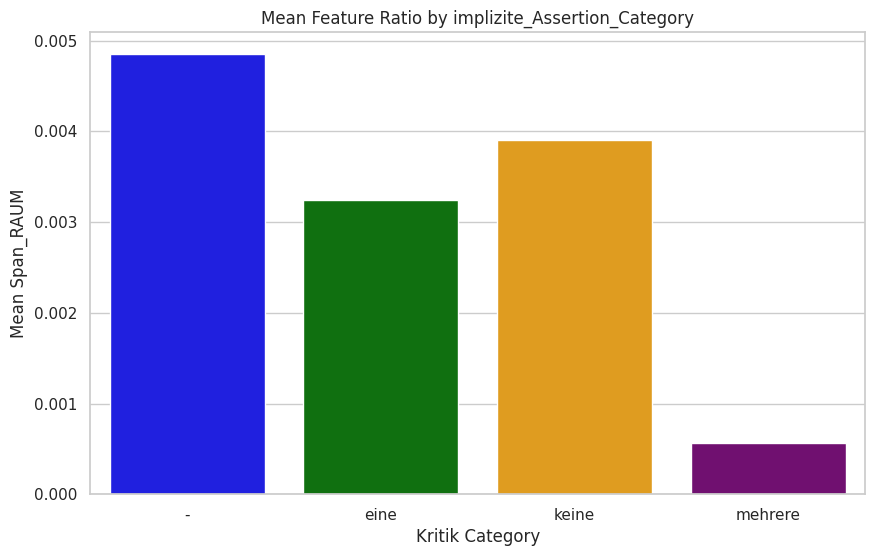

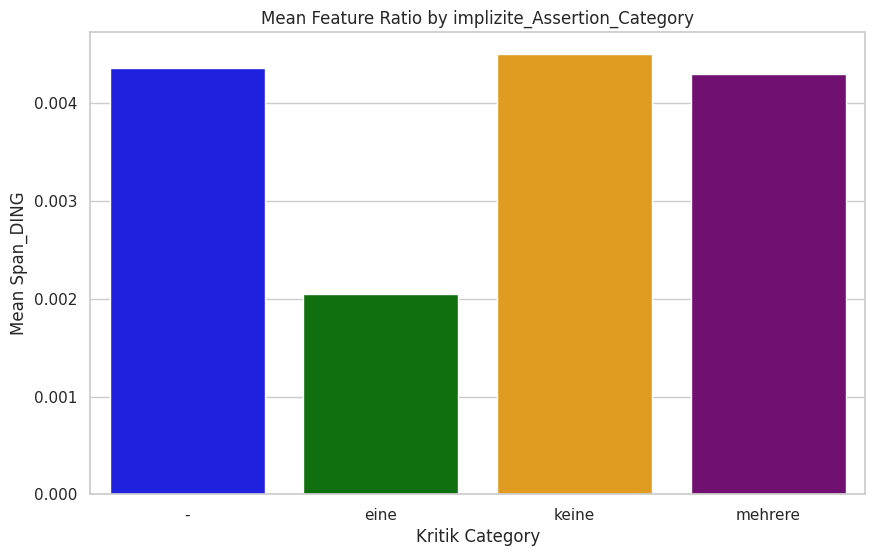

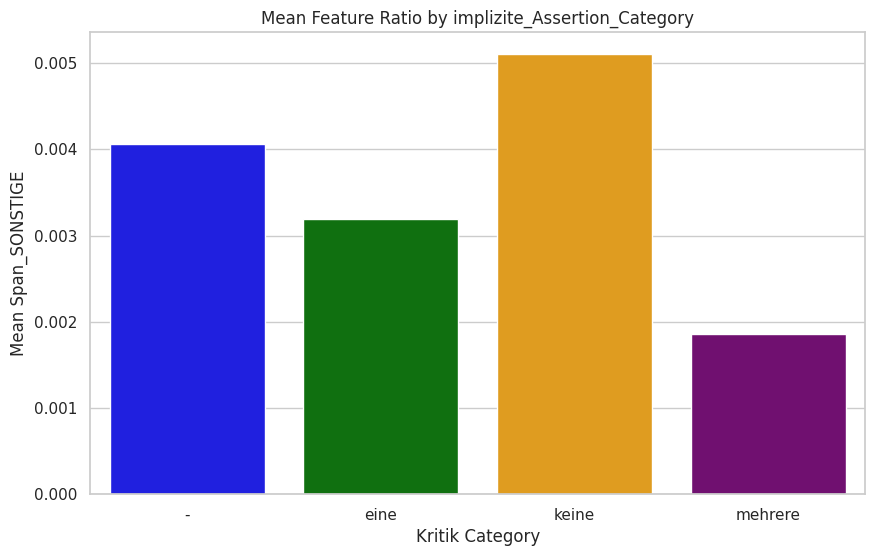

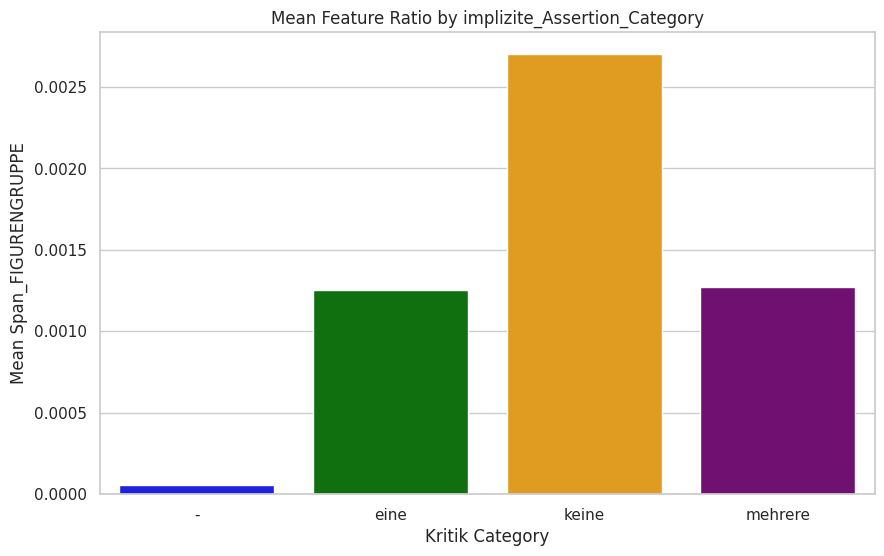

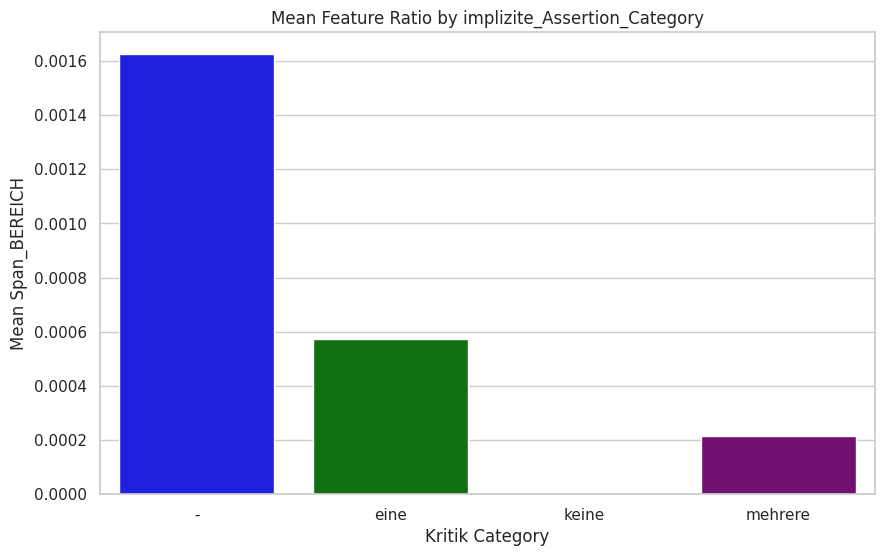

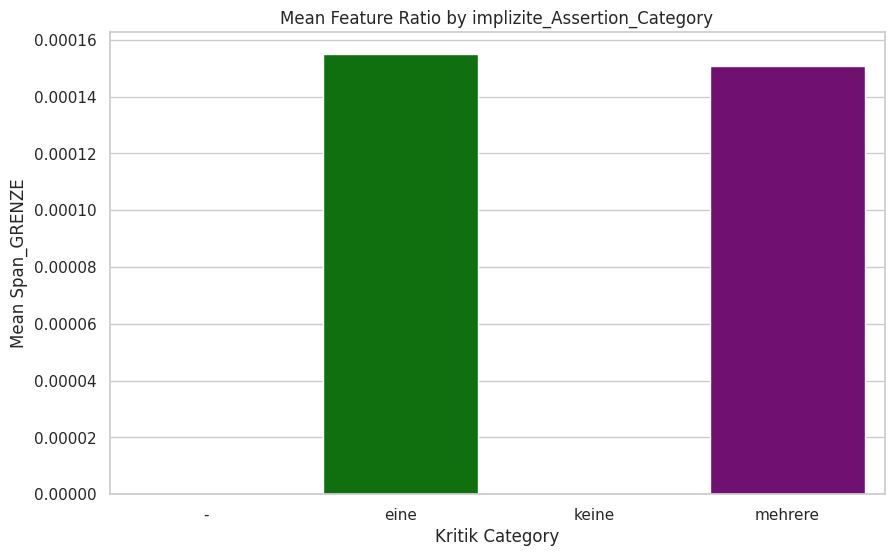

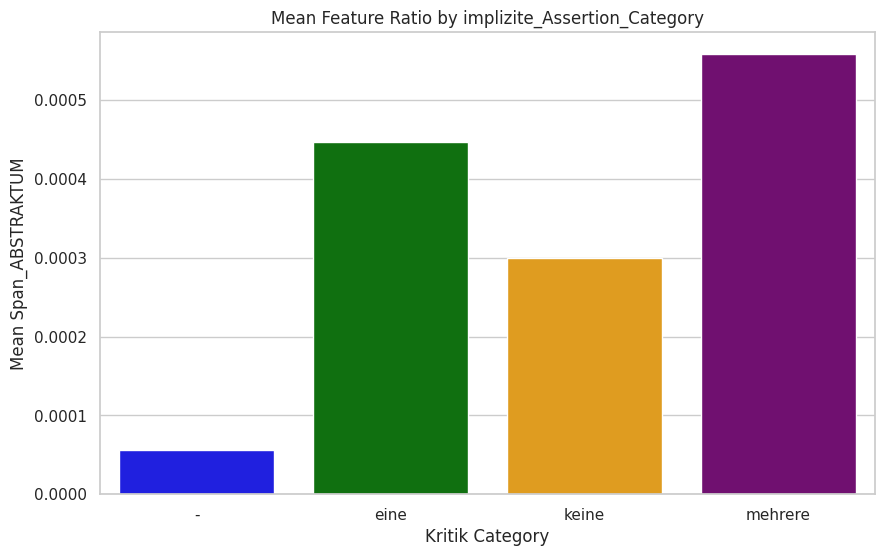

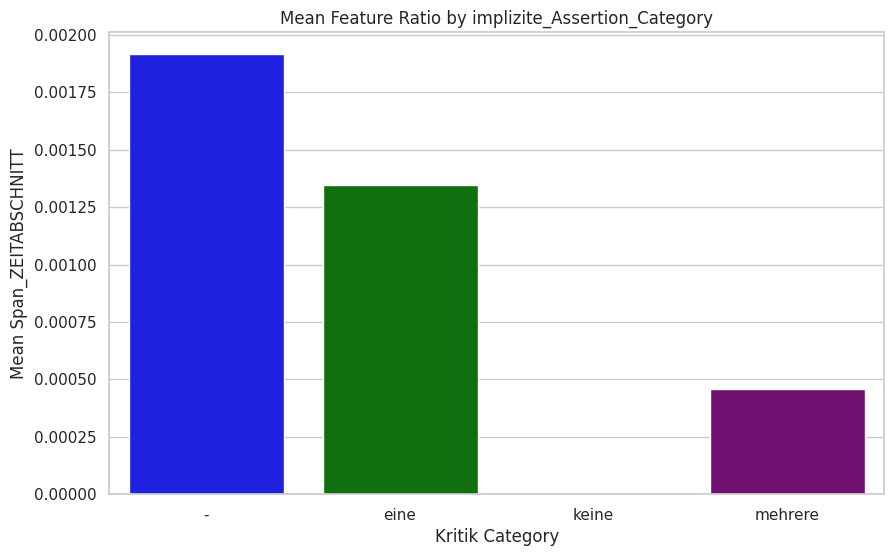

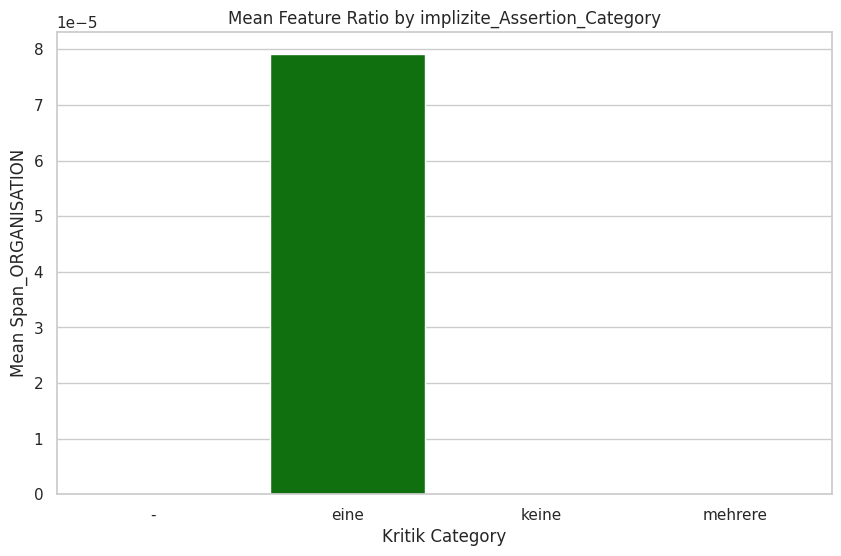

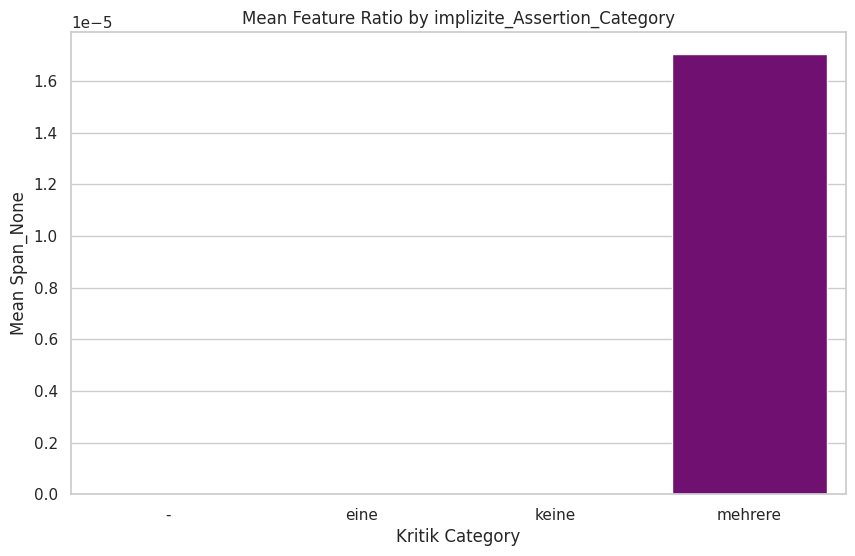

In [ ]:
#Charts for implizite_Assertion_Category
# Load data from CSV file
file_path = 'charts.csv'  # Replace with the actual path to your CSV file
df = pd.read_csv(file_path,encoding='ISO-8859-1')

categories=['implizite_Assertion_Category']

columns=['Wertung_gesamt',
'Erzählerwertung',
'Figurenwertung',
'Wertung_Kompositionsebene',
'positive_Wertung',
'negative_Wertung',
'Wertung_moralisch',
'Wertung_eudäimonistisch',
'Wertung_sozialer_Status',
'Wertung_ästhetisch',
'Wertung_sonstige',
'Codierung_gesamt',
'Codierung_tief_oberflächlich',
'Codierung_natürlich_kulturell',
'Codierung_traditionell_modern',
'Codierung_harmonisch_disharmonisch',
'Codierung_Gesund_krank',
'Opposition_gesamt',
'Wertopposition',
'Traditionell-modern-Opposition',
'Harmonisch-disharmonisch-Opposition',
'Natürlich-kulturell-Opposition',
'Gesund-krank-Opposition',
'Tiefgründig-oberflächlich-Opposition',
'Sonstige_Merkmalsopposition',
'Zugehörigkeit_zu',
'Element_von',
'Kritikhaltige_Reflexion',
'Span_FIGUR',
'Span_RAUM',
'Span_DING',
'Span_SONSTIGE',
'Span_FIGURENGRUPPE',
'Span_BEREICH',
'Span_GRENZE',
'Span_ABSTRAKTUM',
'Span_ZEITABSCHNITT',
'Span_ORGANISATION',
'Span_None'
]

for category in categories:
  for column in columns:
    # Group by 'Category' and calculate the mean
    mean_values = df.groupby(categories)[column].mean().reset_index()

    # Plotting the data with Seaborn
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=category, y=column, hue=category, data=mean_values, palette=['blue', 'green', 'orange','purple'], legend=False)
    x_label = 'Mean Feature Ratio by ' + category
    ax.set_title(x_label)
    y_label='Mean ' + column
    ax.set_ylabel(y_label)
    ax.set_xlabel('Kritik Category')
    plt.show()
    print('\n')


In [ ]:
Document_title= [
'Aichinger_Das_Fenstertheater.txt',
'Bachmann_Arkadien_clean.txt',
'BÃ¶ll_Wanderer_kommst_du_nach_Spa_clean.txt',
'Brecht_Herr_Keuner_und_die_Schauspielerin.txt',
'Dorn_Vorsicht_Steinschlag.txt',
'Grimm_Aschenputtel_clean.txt',
'Grimm_Das_tapfere_Schneiderlein.txt',
'Grimm_Frau_Holle_clean.txt',
'Hollenstein_Gelb_wie_eine_Zitrone.txt',
'Ein Bericht fÃ¼r eine Akademie',
'Der neue Advokat',
'Kleist_Chili_clean.txt',
'LanggÃ¤sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt',
'LÃ¶ns_Die_beiden_HÃ¶fe_clean.txt',
'Mann_Beim_Propheten_clean.txt',
'Mann_Der_Geburtstag_der_Frau_Baronin.txt',
'Rilke_Die_Weise_von_Liebe_und_Tod_des_Cornets_Christoph_Rilke_clean.txt',
'Roth_Der_stumme_Prophet_Fragment_gb_clean.txt',
'Stamm_Das_schÃ¶nste_MÃ¤dchen.txt',
'Walser_Der_Nachen.txt'
]

In [ ]:
len(Wertung_gesamt_rations)

20

In [ ]:
Kritik=[
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Rolle',
'-',
'-',
'-',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'Ausdruck',
'-',
'-',
'Rolle',
'-',
'-']

In [ ]:
Wertung_gesamt_rations=[
0.016465,
0.005423,
0.004040,
0.019608,
0.028409,
0.010827,
0.012462,
0.026261,
0.002212,
0.010406,
0.000000,
0.009045,
0.012500,
0.013305,
0.014706,
0.029871,
0.010204,
0.006391,
0.007059,
0.016129]

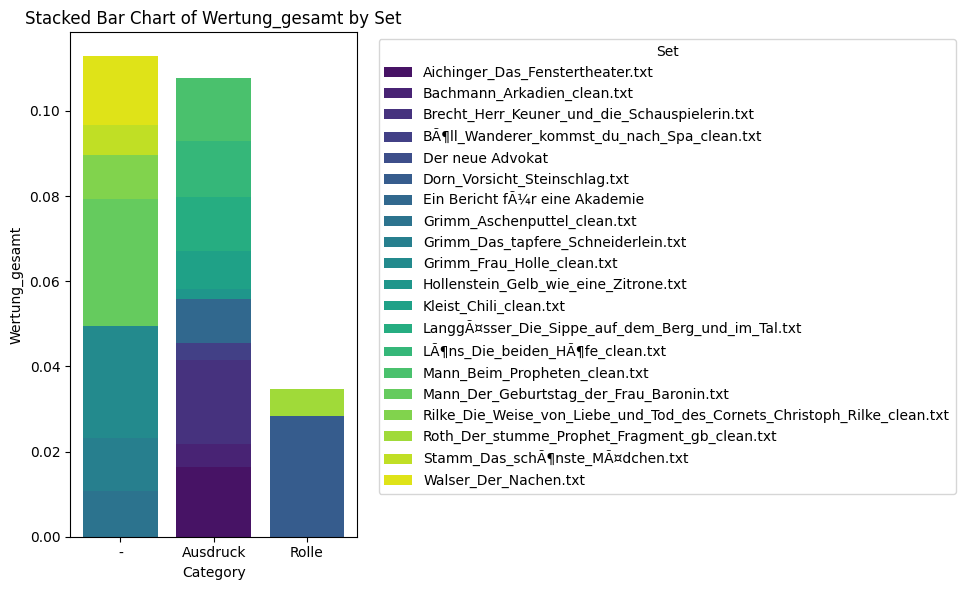

In [ ]:


# Data
data = {
    'Set': Document_title,
    'Category': Kritik,
    'Wertung_gesamt': Wertung_gesamt_rations
}

df = pd.DataFrame(data)

#Aggregate Data for Stacked Bars
# Sum the values for each category by set
df_aggregated = df.groupby(['Category', 'Set']).agg({'Wertung_gesamt': 'sum'}).reset_index()

# Pivot the DataFrame for stacking
pivot_df = df_aggregated.pivot(index='Category', columns='Set', values='Wertung_gesamt').fillna(0)

# Plot Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each series in the pivot table as a bar
bottoms = pd.Series([0] * len(pivot_df), index=pivot_df.index)
colors = sns.color_palette('viridis', len(pivot_df.columns))

for i, column in enumerate(pivot_df.columns):
    ax.bar(pivot_df.index, pivot_df[column], bottom=bottoms, color=colors[i], label=column)
    bottoms += pivot_df[column]

# Customize the Plot
ax.set_title('Stacked Bar Chart of Wertung_gesamt by Set')
ax.set_xlabel('Category')
ax.set_ylabel('Wertung_gesamt')
ax.legend(title='Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to fit the legend
plt.tight_layout()

# Show the Plot
plt.show()

# Network Analysis

## Daten Für Netzwerkanalysen generieren

### x Codierungen

In [ ]:
def polarität_zu_int(polarität):
  """
  Gibt für verschiedene Codierungspolaritäten Integer aus, um Kompatibilität mit bisherigen Code (auf Wertungen bezogen) zu gewährleisten.

  Bsp: polarität == "sehr alt/traditionell" returns -1
  """
  match polarität:
    case "sehr alt/traditionell" | "sehr flach/oberflächlich" | "sehr kulturell/zivilisatorisch" | "sehr disharmonisch/fragmentiert" | "sehr krank/morbid":
      return -1
    case "alt/traditionell" | "flach/oberflächlich" | "kulturell/zivilisatorisch" | "disharmonisch/fragmentiert" | "krank/morbid":
      return -0.5
    case "neuartig/modern" | "tief/tiefsinnig" | "natürlich/ursprünglich" | "harmonisch/ganzheitlich" | "gesund/heil":
      return 0.5
    case "sehr neuartig/modern" | "sehr tief/tiefsinnig" | "sehr natürlich/ursprünglich" | "sehr harmonisch/ganzheitlich" | "sehr gesund/heil":
      return 1
    case _:
      raise ValueError("Keine existierende Polarität: %s", polarität)


In [ ]:
# Codierungen auslesen
Codierungen = {}
j = 0
# speichert Codierungen nach diesem Muster (analog dazu, wie Wertungen abgespeichert werden):
# {1: (Codierende*r, codierte Entität, Art der Codierung, Polarität, Entitätentyp),
#  2: (Codierende*r, codierte Entität, Art der Codierung, Polarität, Entitätentyp)}



# ein segment == eine codierung
for segment in doc.select('webanno.custom.AltNeuCodierung'):
    j = j+1
    #print(segment.get_covered_text())

    if segment.Polaritt_harmonisch:
      # polarität = segment.Polaritt_harmonisch # polarität als string abspeichern (zB "sehr alt/traditionell" statt -1)
      polarität = polarität_zu_int(segment.Polaritt_harmonisch)
    elif segment.Polaritt_gesund:
      # polarität = segment.Polaritt_gesund
      polarität = polarität_zu_int(segment.Polaritt_gesund)
    elif segment.Polaritt_natrlich:
      # polarität = segment.Polaritt_natrlich
      polarität = polarität_zu_int(segment.Polaritt_natrlich)
    elif segment.Polaritt_tief:
      # polarität = segment.Polaritt_tief
      polarität = polarität_zu_int(segment.Polaritt_tief)
    elif segment.Polaritt:
      # polarität = segment.Polaritt
      polarität = polarität_zu_int(segment.Polaritt)
    else:
      # polarität = None
      polarität = polarität_zu_int(None)

    codierte_entität = ""
    codierend = "Erzähler" # default Codierende*r ist Erzähler*in
    if segment.Bezugsentitt: # d.h. wir ignorieren all jene Codierungen, bei denen keine codierte Entität o Codierende*r annotiert ist (weil schlecht darstellbar). Bei zB Roth werden dann zwei Codierungen nicht weiter berücksichtigt
      for e in segment.Bezugsentitt.elements:
          if e.role == "codierte Entität":
            ent_typ = e.target.label
            if e.target.Name:
              codierte_entität = e.target.Name.split(":")[1].strip()
            else:
              codierte_entität = e.target.get_covered_text()
          elif e.role == "Codierender": # wenn die Entität Codierender ist und nicht Codierter (gibts z.B. bei Roth)
            if e.target.Name:
              codierend = e.target.Name.split(":")[1].strip()
            else:
              codierend = e.target.get_covered_text()
      """
      # kompaktere Speicherungsart:
      # {codierte Entität A : [[Art der Codierung, Polarität, Codierende*r], [Art der Codierung2, Polarität2, Codierende*r2], ...]; codierte Entität B: []; ...}
      if codierte_entität in Codierungen: # wenn diese Entität bereits als key existiert, weil schon andere Codierung dazu abgespeichert wurde
        Codierungen[codierte_entität].append([segment.Art, polarität, codierend, ent_typ])
      else:
        Codierungen[codierte_entität] = [[segment.Art, polarität, codierend, ent_typ]]
      """
      if codierte_entität:
        Codierungen[j] = codierend, codierte_entität, segment.Art, polarität, ent_typ

# testweise Ausgabe
for k,v in Codierungen.items():
  print(k, ": ", v)

error =========== 
error =========== 
error =========== 
1 :  ('Erzähler', 'der andere', 'Tief-Oberflächlich', 0.5, 'FIGUR')
2 :  ('Erzähler', 'der andere', 'Tief-Oberflächlich', 0.5, 'FIGUR')
3 :  ('Erzähler', 'Anton1', 'Tief-Oberflächlich', 0.5, 'FIGUR')
5 :  ('Anton1', 'solcher Kinder', 'Gesund-Krank', -0.5, 'FIGURENGRUPPE')
6 :  ('Erzähler', 'der Hottentotten', 'Natürlich-Kulturell', 0.5, 'FIGURENGRUPPE')
7 :  ('Erzähler', 'der Hottentotten', 'Natürlich-Kulturell', 0.5, 'FIGURENGRUPPE')
11 :  ('Erzähler', 'des Mannes', 'Traditionell-Modern', 0, 'FIGUR')
12 :  ('Erzähler', 'die Rohesten und Wildesten', 'Natürlich-Kulturell', 0.5, 'FIGURENGRUPPE')
13 :  ('Erzähler', 'Christiane', 'Gesund-Krank', -0.5, 'FIGUR')
15 :  ('Erzähler', 'dem Verhältnis', 'Harmonisch-Disharmonisch', 0.5, 'SONSTIGE')
16 :  ('Erzähler', 'eines kräftigen Knaben', 'Gesund-Krank', 0.5, 'FIGUR')
19 :  ('Erzähler', 'Christiane', 'Harmonisch-Disharmonisch', -0.5, 'FIGUR')
20 :  ('Erzähler', 'Anton2', 'Gesund-Krank', 

### x Wertungen

In [ ]:
Wertungen = {}
i=j # Nummerierung der Wertungen (= keys vom Wertungen-Dictionary) beginnt da, wo diejenige der Codierungen aufhört, sodass beide dictionaries
# sich, wenn geüwnscht, mergen lassen und zusammen im Netzwerk darstellen lassen
# s.u: Codierungen und/oder Wertungen anzeigen?

for segment in doc.select('webanno.custom.Wertung'):
    i = i+1

    #print(segment.TEST)
    #print(str(segment.TEST.elements))
    print(segment.Label, ": ", segment.get_covered_text(), "; Hinsicht: ", segment.Wertungshinsicht, "; Polarität: ", segment.Polaritt)
    #if segment.Label == "implizite Wertung" or "explizite Wertung":
    Hinsicht = segment.Wertungshinsicht
    Polarität = segment.Polaritt

    if Polarität == "sehr positiv":
        Polarität_int = 1
    if Polarität == "positiv":
        Polarität_int = 0.5
    if Polarität == "sehr negativ":
        Polarität_int = -1
    if Polarität == "negativ":
        Polarität_int = -0.5


    Wertender = "Erzähler" # default
    gew_Ent = None # default

    try:
        for e in segment.TEST.elements:
            t= "test"
    except:
        print("Segment ohne gew. Objekt")
        continue

    for e in segment.TEST.elements:

        if e.role == "Wertender":

            #print(e.role, ": ", e.target.get_covered_text(), "Typ: ", e.target.label, "Name: ", e.target.Name)
            if e.target.Name is not None:
                Wertender = e.target.Name.rsplit(": ")[1]
            else:
                Wertender = e.target.get_covered_text()

        if e.role == "gewertete Entität":
                EntTyp = e.target.label
                if e.target.Name is not None:
                    gew_Ent = e.target.Name.rsplit(": ")[1]
                else:
                    gew_Ent = e.target.get_covered_text()

    # Ausschluss von Fällen ohne Wertungsobjekt
    if gew_Ent is not None:
        Wertungen[i] = Wertender, gew_Ent, Hinsicht, Polarität_int, EntTyp


#print(Wertungen)
# Filter
#res = {key: val for key, val in Wertungen if val[0] != "Erzähler"}
#print(res)

# to csv
import csv
data_folder = PureWindowsPath(r"D:\Dropbox\Wissenschaft\Kultur_und_Modernekritik\Gephi")
file_to_open = data_folder / "Kleist_for_gephi.csv"
with open(file_to_open, 'w', newline='', encoding='utf-8') as csv_file:
    writer = csv.writer(csv_file, delimiter=';')
    #writer.writerow(["id", "gewertete_Entität", "Hinsicht_Polarität"])

    # gephi-Format
    writer.writerow(["Source", "Target", "Type", "Id", "Label", "Weight"])
    Type = "Directed"
    #Source = "Erzähler"
    Id = 0


    for key, value in Wertungen.items():
        Source = value[0]
        Entität = value[1]
        Hinsicht = value[2]
        Polarität = value[3]
        writer.writerow([Source, Entität, Type, key, Hinsicht, Polarität])
        Id = Id +1

print("#######")
print(Wertungen)


None :  auf ihren Angesichtern liegt der Gram, und stumm sitzen sie einander gegenüber ; Hinsicht:  eudämonistisch ; Polarität:  negativ
None :  wodurch man die Hunde von gewissen Tieren, Flöhe genannt, befreien könne, ohne die Flöhe ihrer Lebensberechtigung zu berauben, das heißt, ohne sie zu töten ; Hinsicht:  moralisch ; Polarität:  positiv
None :  An diesen Vereinen gegen Tierquälerei!", sagte der andere, ein Mann mit grau gemischtem Barte, "da haben wir wieder ein Beispiel, wie die Niederträchtigkeit und Heuchelei so vieler Menschen es wagt, sich und anderen was vorzugaukeln, sich den Schein des Guten beizulegen ; Hinsicht:  moralisch ; Polarität:  negativ
None :  Menschen, die sich demütig bücken, wenn die Rechte des Volkes zertreten werden, weiche Butterseelen, die vor jedem Sonnenblick hoher Gnade zerfließen möchten, die die Achsel zucken über jeden, der durch Wort und Tat für das einsteht, was er für Recht hält - solche Menschen laufen einem Wagen nach, auf dem Schlachtkälber 

### x Positive und negativ bewertete Entitäten

In [ ]:
"""
Ent_Bewert speichert zu jeder bewerteten Entität ab, in welcher Hinsicht und mit welcher Polarität die bewertet wird,
nach folgendem Muster (Beispiel):

{'der Einsamkeit': {'ästhetisch': 0.5,
  'epistemisch': 0,
  'eudämonistisch': -0.5,
  'eudämonistisch Figur': 0,
  'moralisch': 0,
  'sozialer Status': 0,
  'sonstige': 0,
  'nicht spezifiziert': 0,
  'gesamt': 0.0,
  'gesamt_Erzähler': 0.0,
  'gesamt_Rest': 0,
  'Typ Entität': 'ABSTRAKTUM'}, ...}
"""

Id = 0
Ent_Bewert = {}

keylist = ["ästhetisch", "epistemisch", "eudämonistisch", "eudämonistisch Figur", "moralisch",
                          "sozialer Status", "sonstige", "nicht spezifiziert", "gesamt", "gesamt_Erzähler", "gesamt_Rest", "Typ Entität"]

for key, value in Wertungen.items():
    Wertender = value[0]
    Entität = value[1]
    Hinsicht = value[2]
    Polarität = value[3]
    EntTyp = value[4]
    #print(Wertungen.items())



    #if Wertender == "Erzähler":            #optional nur Erzählerwertungen
    if Entität in Ent_Bewert.keys():
        Ent_Bewert[Entität][Hinsicht] = Ent_Bewert[Entität][Hinsicht] + Polarität
        Ent_Bewert[Entität]["gesamt"] += Polarität
        if Wertender == "Erzähler":
          try:
            Ent_Bewert[Entität]["gesamt_Erzähler"] = Ent_Bewert[Entität]["gesamt_Erzähler"] + Polarität
          except KeyError: # falls gesamt_Erzähler noch nicht initialisiert wurde
            Ent_Bewert[Entität]["gesamt_Erzähler"] = Polarität
        else: # Wertungen, die nicht vom Erzähler ausgehen
          try:
            Ent_Bewert[Entität]["gesamt_Rest"] = Ent_Bewert[Entität]["gesamt_Rest"] + Polarität
          except KeyError:
            Ent_Bewert[Entität]["gesamt_Rest"] = Polarität
    else: # wenn die entität noch nicht in Ent_Bewert ist
        empty_d = {}
        for i in keylist:
            try:
              empty_d[i] = 0
            except:
              continue
        Ent_Bewert[Entität] = empty_d
        Ent_Bewert[Entität][Hinsicht] = Polarität
        Ent_Bewert[Entität]["gesamt"] = Polarität
        if Wertender == "Erzähler":
          Ent_Bewert[Entität]["gesamt_Erzähler"] = Polarität
        else:
          Ent_Bewert[Entität]["gesamt_Rest"] = Polarität
        Ent_Bewert[Entität]["Typ Entität"] = EntTyp

Ent_Bewert



{'der Jüngste': {'ästhetisch': 0,
  'epistemisch': 0,
  'eudämonistisch': -0.5,
  'eudämonistisch Figur': 0,
  'moralisch': 0,
  'sozialer Status': 0,
  'sonstige': 0,
  'nicht spezifiziert': 0,
  'gesamt': -0.5,
  'gesamt_Erzähler': -0.5,
  'gesamt_Rest': 0,
  'Typ Entität': 'FIGUR'},
 'Der Verein gegen Tierquälerei': {'ästhetisch': 0,
  'epistemisch': 0,
  'eudämonistisch': 0,
  'eudämonistisch Figur': 0,
  'moralisch': 0.0,
  'sozialer Status': 0,
  'sonstige': 0,
  'nicht spezifiziert': 0,
  'gesamt': 0.0,
  'gesamt_Erzähler': -0.5,
  'gesamt_Rest': 0.5,
  'Typ Entität': 'ORGANISATION'},
 'so vieler Menschen': {'ästhetisch': 0,
  'epistemisch': 0,
  'eudämonistisch': 0,
  'eudämonistisch Figur': 0,
  'moralisch': -0.5,
  'sozialer Status': 0,
  'sonstige': 0,
  'nicht spezifiziert': 0,
  'gesamt': -0.5,
  'gesamt_Erzähler': 0,
  'gesamt_Rest': -0.5,
  'Typ Entität': 'FIGURENGRUPPE'},
 'die hohe Polizei': {'ästhetisch': 0,
  'epistemisch': 0,
  'eudämonistisch': 0,
  'eudämonistisch

### Figurenprofile

In [ ]:
import plotly.express as px
import pandas as pd
df =pd.DataFrame.from_dict(Ent_Bewert,orient='index')
df
df.drop('gesamt', axis=1, inplace=True)

#df = pd.DataFrame(df.loc[["Jeronimo Rugera"]])
fig = px.line_polar(df, r=df.loc["Jeronimo Rugera"], theta=df.columns, line_close=True)
fig.show()

KeyError: 'Jeronimo Rugera'

# Netzwerkanalyse

## x Codierungen und/oder Wertungen anzeigen?

In [ ]:
"""
anzeige_option == "c" --> nur Codierungen im Netzwerk
anzeige_option == "w" --> nur Wertungen
anzeige_option  == alles andere --> Wertungen und Codierungen
Ausnahme: auf Ebene der Relationen werden immer auch nicht nur Wertoppositionen angezeigt, sondern
auch zB nat-kult-Oppositionen
"""

anzeige_option = "y" # <------- set option. wenn geändert, danach noch mal alle mit x versehenen Abschnitte laufen lassen


if anzeige_option == "w":
  df = pd.DataFrame.from_dict(Wertungen, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])
elif anzeige_option == "c":
  df = pd.DataFrame.from_dict(Codierungen, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])
else:
  combined_dict = {}
  combined_dict.update(Codierungen)
  combined_dict.update(Wertungen)
  df = pd.DataFrame.from_dict(combined_dict, orient = "index", columns=['Source', 'Target', 'Label', "Weight", "Type"])

df["Weight"] = df["Weight"].astype(float)*5
pd.set_option('display.max_rows', 5)
print(df)

         Source                             Target               Label  \
1      Erzähler                         der andere  Tief-Oberflächlich   
2      Erzähler                         der andere  Tief-Oberflächlich   
..          ...                                ...                 ...   
227      Anton1  Ein Verein von Männern und Frauen            sonstige   
228  der andere  Ein Verein von Männern und Frauen            sonstige   

     Weight          Type  
1       2.5         FIGUR  
2       2.5         FIGUR  
..      ...           ...  
227     2.5  ORGANISATION  
228     2.5  ORGANISATION  

[202 rows x 5 columns]


## x Netzwerk mit Erzählerwertungen als Kanten (G)

In [ ]:
# Networkx
!pip install pyvis
!pip install cyjupyter
!pip install networkx

from pyvis.network import Network
from IPython.display import HTML
import pandas as pd
import networkx as nx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.5 MB/s eta 0:00:00


In [ ]:
# MultiDiGraph erstellen
G = nx.MultiDiGraph()
G_Fig = nx.MultiDiGraph()

# benutzerdefinierte Farbpalette definieren
color_palette = {"positive": "green", "negative": "red"}

# Kanten aus DataFrame hinzufügen
for i, row in df.iterrows():
    source = row["Source"]
    target = row["Target"]
    label = row["Label"]
    weight = row["Weight"]
    Typ = row["Type"]
    edge_color = color_palette["positive"] if weight >= 0 else color_palette["negative"]
    if source == "Erzähler" and Typ == "FIGUR":
      G.add_edge(source, target, key=i, label=label, weight=weight, width=weight, color=edge_color)
    if source != "Erzähler" and Typ == "FIGUR":
      G_Fig.add_edge(source, target, key=i, label=label, weight=weight, width=weight, color=edge_color)



# Größe der Nodes
scale=3 # Scaling the size of the nodes by 10*degree
d = dict(G.degree)
#print(d)

#Updating dict
d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
nx.set_node_attributes(G,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, cdn_resources='in_line')
nt.from_nx(G)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons()
nt.toggle_physics(True)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 25, "color": "#444444"}

for node in nt.nodes:
    #node["color"] = "red"
    node['font'] = {'size': 60}

# Netzwerk anzeigen
nt.show('nx.html')
# nur in colab
display(HTML('nx.html'))


nx.html


## x Figurenwertungen (G_Fig)

In [ ]:
#G.edges(data= True)
#G.nodes(data = True)
#nt.nodes

In [ ]:
# Figurenwertungen
# Größe der Nodes
scale=3 # Scaling the size of the nodes by 10*degree
d = dict(G_Fig.degree)
#print(d)

#Updating dict
d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
nx.set_node_attributes(G_Fig,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, cdn_resources='in_line')
nt.from_nx(G_Fig)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons()
nt.toggle_physics(True)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 25, "color": "#444444"}

for node in nt.nodes:
    #node["color"] = "red"
    node['font'] = {'size': 60}

# Netzwerk anzeigen
nt.show('nx.html')
# nur in colab
display(HTML('nx.html'))

nx.html


## x Netzwerk mit annotierten Oppositionen als Kanten (G2)

In [ ]:
# Achtung: Edges, die übereinanderliegen werden nicht dargestellt

# MultiDiGraph erstellen
G2 = nx.MultiDiGraph()

# benutzerdefinierte Farbpalette definieren
color_palette = {"Wertopposition": "green", "else": "red"}


# Kanten aus DataFrame hinzufügen
for key, value in Relationen.items():
    source = value[0]
    target = value[1]
    label = value[2]
    edge_color = color_palette["Wertopposition"] if label == "Wertopposition" else color_palette["else"]
    G2.add_edge(source, target, key=i, label=label, color=edge_color)

# Größe der Nodes
scale=10 # Scaling the size of the nodes by 10*degree
d = dict(G2.degree)
#print(d)

#Updating dict
d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
nx.set_node_attributes(G2,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, heading='Oppositionen Kleist', layout="hierarchical", cdn_resources='in_line')
#nt.show_buttons(filter_=["physics"])

nt.from_nx(G2)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons()
nt.toggle_physics(False)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 10, "color": "#444444"}


# Netzwerk anzeigen
nt.show('nx.html')
display(HTML('nx.html'))


NameError: name 'Relationen' is not defined

In [ ]:
G2.edges(data = True)

## Netzwerk mit (nicht-annotierten) Oppositionen als Kanten

In [ ]:
negativeFiguren = {k:v for k,v in Ent_Bewert.items() if v['gesamt'] < 0 and v["Typ Entität"] == "FIGUR"}
positiveFiguren = {k:v for k,v in Ent_Bewert.items() if v['gesamt'] > 0 and v["Typ Entität"] == "FIGUR"}

negativeFiguren


In [ ]:
# MultiDiGraph erstellen
G3 = nx.MultiDiGraph()

# benutzerdefinierte Farbpalette definieren
color_palette = {"nicht-annotiert": "black", "else": "red"}

for key, value in negativeFiguren.items():
    source = key
    i = 0
    for key2, value2 in positiveFiguren.items():
        i = i +1
        target = key2
        label = "nicht-annotiert"
        edge_color = color_palette["nicht-annotiert"] if label == "nicht-annotiert" else color_palette["else"]
        G3.add_edge(source, target, key = i, label=label, color=edge_color)

# annotierte Relationen
for key, value in Relationen.items():
    source = value[0]
    target = value[1]
    label = value[2]
    if source or target in nt.nodes.keys():
        G3.add_edge(source, target, key=i, label=label, color="red")


# Größe der Nodes
scale=5 # Scaling the size of the nodes by 10*degree
d = dict(G3.degree)
#print(d)

#Updating dict
d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
nx.set_node_attributes(G3,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, heading='Oppositionen Kleist', cdn_resources='in_line')
#nt.show_buttons(filter_=["physics"])

nt.from_nx(G3)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons(True)
nt.toggle_physics(True)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 10, "color": "#444444"}

#Farbe der Nodes
for node in nt.nodes:
    if node["id"] in negativeFiguren.keys():
        node["color"] = "red"
        node['font'] = {'size': 50}
    else:
        node["color"] = "green"
        node['font'] = {'size': 50}



# Netzwerk anzeigen
nt.show('nx.html')
display(HTML('nx.html'))


In [ ]:
G3.nodes(data = True)

## Netzwerk mit (nicht-annotierten) Oppositionen nach Hinsicht als Kanten

In [ ]:
# MultiDiGraph erstellen
G4 = nx.MultiDiGraph()

# benutzerdefinierte Farbpalette definieren
color_palette = {"ästhetisch": "black", "epistemisch": "brown", "eudämonistisch": "blue", "eudaimonistisch Figur": "pink", "moralisch": "green",
                          "sozialer Status": "yellow", "else": "grey"}

#create dict of all entities
alleFiguren = {**negativeFiguren, **positiveFiguren}
#print(alleFiguren)


oppositionen = []
for key, value in alleFiguren.items():
    source = key
    i = 0
    negative_hinsichten = []
    # create list aller relevanten Hinsichten
    for hinsicht, wert in value.items():
      try:
        if wert < 0 and hinsicht != "gesamt":
          negative_hinsichten.append(hinsicht)
      except:
        pass
      #print(negative_hinsichten)
    # suche alle anderen Entitäten mit entgegengesetzer Hinsicht
    for key2, value2 in alleFiguren.items():
      target = key2
      for hinsicht, wert in value2.items():
        #print(wert)
        try:
          if wert > 0 and hinsicht in negative_hinsichten:
            oppositionen.append((source, target))
            i = i +1
            label = hinsicht
            edge_color = color_palette[hinsicht] if label == hinsicht else color_palette["else"]
            G4.add_edge(source, target, key = i, label=label, color=edge_color)
        except:
          pass
#print(oppositionen)

# annotierte Relationen
for key, value in Relationen.items():
    try:
      source = value[0].split(":")[1]
    except:
      source = value[0]
    try:
      target = value[1].split(":")[1]
    except:
      target = value[1]
    label = value[2]

    if source or target in nt.nodes.keys():
        i = i + 1
        G4.add_edge(source, target, key=i, label=label, color="red")


# Größe der Nodes
scale=5 # Scaling the size of the nodes by 10*degree
d = dict(G4.degree)
#print(d)

#Updating dict
d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
nx.set_node_attributes(G4,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, heading='Oppositionen nach Hinsicht Kleist', cdn_resources='in_line')
#nt.show_buttons(filter_=["physics"])

nt.from_nx(G4)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons(True)
nt.toggle_physics(True)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 25, "color": "#444444"}


#Farbe der Nodes
for node in nt.nodes:
    if node["id"] in negativeFiguren.keys():
        node["color"] = "red"
        node['font'] = {'size': 50}
    else:
        node["color"] = "green"
        node['font'] = {'size': 50}



# Netzwerk anzeigen
nt.show('nx.html')
display(HTML('nx.html'))


In [ ]:
Relationen.items()

In [ ]:
G4.edges(data = True)

## Knotengröße nach Wertung plus alle Oppositionen




In [ ]:
negativeFiguren = {k:v for k,v in Ent_Bewert.items() if v['gesamt'] < 0 and v["Typ Entität"] == "FIGUR"}
positiveFiguren = {k:v for k,v in Ent_Bewert.items() if v['gesamt'] > 0 and v["Typ Entität"] == "FIGUR"}

negativeFiguren

In [ ]:
# MultiDiGraph erstellen
G4 = nx.MultiDiGraph()

# benutzerdefinierte Farbpalette definieren
color_palette = {"ästhetisch": "pink", "epistemisch": "brown", "eudämonistisch": "blue", "eudaimonistisch Figur": "blue", "moralisch": "black",
                          "sozialer Status": "yellow", "else": "grey"}

#create dict of all entities
alleFiguren = {**negativeFiguren, **positiveFiguren}
#print(alleFiguren)

# alle Nodes hinzufügen
for key, value in alleFiguren.items():
  size = abs(alleFiguren[key]["gesamt"])*10
  G4.add_node(key, label=str(key), size=size)

oppositionen = []
for key, value in alleFiguren.items():
    source = key
    i = 0
    negative_hinsichten = []
    # create list aller relevanten Hinsichten
    for hinsicht, wert in value.items():
      try:
        if wert < 0 and hinsicht != "gesamt":
          negative_hinsichten.append(hinsicht)
      except:
        pass
      #print(negative_hinsichten)
    # suche alle anderen Entitäten mit entgegengesetzer Hinsicht
    for key2, value2 in alleFiguren.items():
      target = key2
      for hinsicht, wert in value2.items():
        #print(wert)
        try:
          if wert > 0 and hinsicht in negative_hinsichten:
            oppositionen.append((source, target))
            i = i +1
            label = hinsicht
            edge_color = color_palette[hinsicht] if label == hinsicht else color_palette["else"]
            G4.add_edge(source, target, key = i, label=label, color=edge_color)
        except:
          pass
#print(oppositionen)

# annotierte Relationen
for key, value in Relationen.items():
    try:
      source = value[0].split(":")[1]
    except:
      source = value[0]
    try:
      target = value[1].split(":")[1]
    except:
      target = value[1]
    label = value[2]

    if source or target in nt.nodes.keys():
        i = i + 1
        nt.add_edge(source, target, key=i, label=label, color="red")



# Größe der Nodes
#scale=5 # Scaling the size of the nodes by 10*degree
#d = dict(G4.degree)
#print(d)

#Updating dict
#d.update((x, scale*y) for x, y in d.items())
#print(d)
#Setting up size attribute
#nx.set_node_attributes(G4,d,'size')

# Netzwerk mit pyvis erstellen
nt = Network(notebook=True, directed=True, heading='Oppositionen nach Hinsicht Kleist', cdn_resources='in_line')
#nt.show_buttons(filter_=["physics"])

nt.from_nx(G4)

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True

# Node- und Kantenbeschriftungen aktivieren
nt.show_buttons(True)
nt.toggle_physics(True)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 25, "color": "#444444"}


#Farbe und Größe der Nodes
for node in nt.nodes:
    if node["id"] in negativeFiguren.keys():
        node["color"] = "red"
        node['font'] = {'size': 50}
    else:
        node["color"] = "green"
        node['font'] = {'size': 50}




# Netzwerk anzeigen
nt.show('nx.html')
display(HTML('nx.html'))


In [ ]:
G4.nodes(data = True)

In [ ]:
nt.get_nodes()


In [ ]:
alleFiguren

In [ ]:
!git clone git@github.com:bolozna/Multilayer-networks-library.git

## Multilayer Network Analysis


### x Matplotlib

Voraussetzung: mit x markierte Abschnitte sind in aktueller Sitzung durchgelaufen

In [ ]:
# all diejenigen Entitäten, die zu anderen Relationen gehören als Wertoppositionen, in entsprechende Listen speichern

nat_kult_Oppositionen = [] # alle natürlich-kulturell Oppositionen
alt_neu_Oppositionen = []
flach_tief_Oppositionen = []
disharm_harm_Oppositionen = []
krank_gesund_Oppositionen = []

for key, value in Relationen.items():
  if value[2] != "Wertopposition":
    match value[2]: # Relationsart
      case 'Alt-Neu-Opposition':
        alt_neu_Oppositionen.append([value[0], value[1]])
      case 'Natürlich-kulturell-Opposition':
        nat_kult_Oppositionen.append([value[0], value[1]])
      case 'Harmonisch-disharmonisch-Opposition':
        disharm_harm_Oppositionen.append([value[0], value[1]])
      case 'Tief-oberflächlich-Opposition':
        flach_tief_Oppositionen.append([value[0], value[1]])
      case 'Gesund-krank-Opposition':
        krank_gesund_Oppositionen.append([value[0], value[1]])
      case _:
        raise ValueError("Keine existierende Opposition: %s", value[2])

NameError: name 'Relationen' is not defined

In [ ]:
# all diejenigen Entitäten, die codiert werden, zusammen mit der codierenden Entität speichern
alt_neu = []
flach_tief = []
kult_nat = []
disharm_harm = []
krank_gesund = []

for key, value in Codierungen.items():
  match value[2]: # die Codierungsart
    case 'Gesund-Krank':
      krank_gesund.append([value[0], value[1]])
    case 'Natürlich-Kulturell':
      kult_nat.append([value[0], value[1]])
    case 'Tief-Oberflächlich':
      flach_tief.append([value[0], value[1]])
    case 'Harmonisch-Disharmonisch':
      disharm_harm.append([value[0], value[1]])
    case 'Alt-Neu':
      alt_neu.append([value[0], value[1]])
    case _:
      raise ValueError("Keine existierende Codierungsart: %s", value[2])



In [ ]:
# Listen mit all jenen Entitäten, die entweder vom Erzähler o einzelnen Figuren pos/neg/beides bewertet werden
# Ent_Bewert[Entität]["gesamt_Erzähler"] speichert die addierten Wertungen des Erzählers,
# Ent_Bewert[Entität]["gesamt_Rest"] die addierten Wertungen der Figuren.
# --> für die Knotensymbolauswahl
Figuren_pos_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] > 0]
Erzähler_pos_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] > 0]
Figuren_neutr_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] == 0]
Erzähler_neutr_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] == 0]
Figuren_neg_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Rest'] < 0]
Erzähler_neg_bewertet = [k for k,v in Ent_Bewert.items() if v['gesamt_Erzähler'] < 0]

In [ ]:
## Create Node Labels
g_dict = nx.to_dict_of_dicts(G)
g_dict_Fig = nx.to_dict_of_dicts(G_Fig)
g_dict_Rel = nx.to_dict_of_dicts(G2)

g_dict_gesamt = g_dict|g_dict_Fig|g_dict_Rel

#print(g_dict)
node_labels = {}
for key in g_dict_gesamt:
  #print(key)
  node_labels[key] = str(key)
print(node_labels)



"""size=5
for node in nt.nodes:
    #node["color"] = "red"
    node['font'] = {'size': 10}"""

In [ ]:
!apt-get install -y fonts-liberation
import matplotlib.font_manager as fm

!apt-get install python3-dev
!pip install --upgrade setuptools
#!pip install matplotlib numpy
!pip install mpl_toolkits
from mpl_toolkits.mplot3d.axes3d import Axes3D

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d.art3d import Patch3DCollection
from matplotlib.patches import Arrow
from matplotlib.collections import PatchCollection
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

import matplotlib.patches as mpatches


def codierung_farbe(coords, alt_neu_coords, flach_tief_coords, kult_nat_coords, disharm_harm_coords, krank_gesund_coords):
  """
  Bestimmt Farbe basierend auf Codierungsart (oder Relationsart).

  coords: Koordinaten von codierender und codierter Entität (oder Koordinaten der zur Relation gehörenden Entitäten)
  alt_neu_coords etc: Listen an Koordinaten von alt/neu codierende u als alt/neu codierte Entität (oder alt_neu_opps_coords)
  Diese Listen werden in der Klasse LayeredNetworkGraph erstellt.

  Achtung: Nach Polarität wird nicht differenziert (würde unübersichtlich).
  D.h. sowohl eine als gesund codierte als auch eine als krank codierte Entität
  hätten einen magenta Pfeil, der auf sie zeigt, weil sie zur selben Codierungsart gehören ("gesund-krank").
  """
  if coords in alt_neu_coords:
    return "darkblue"
  elif coords in flach_tief_coords:
    return "darkolivegreen"
  elif coords in kult_nat_coords:
    return "saddlebrown"
  elif coords in disharm_harm_coords:
    return "yellow"
  elif coords in krank_gesund_coords:
    return "magenta"
  else:
    return "black" # default: keine codierung zwischen diesen entitäten bzw bei relationen: es handelt sich um eine wertopposition


class Arrow3D(FancyArrowPatch):
    # https://stackoverflow.com/questions/22867620/putting-arrowheads-on-vectors-in-a-3d-plot
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)

class LayeredNetworkGraph(object):
    # https://stackoverflow.com/questions/60392940/multi-layer-graph-in-networkx
    """
    Plot multi-graphs in 3D.
    """
    def __init__(self, graphs, node_labels=None, layout=nx.spring_layout, ax=None):
        """Given an ordered list of graphs [g1, g2, ..., gn] that represent
        different layers in a multi-layer network, plot the network in
        3D with the different layers separated along the z-axis.

        Within a layer, the corresponding graph defines the connectivity.
        Between layers, nodes in subsequent layers are connected if
        they have the same node ID.

        Arguments:
        ----------
        graphs : list of networkx.Graph objects
            List of graphs, one for each layer.

        node_labels : dict node ID : str label or None (default None)
            Dictionary mapping nodes to labels.
            If None is provided, nodes are not labelled.

        layout_func : function handle (default networkx.spring_layout)
            Function used to compute the layout.

        ax : mpl_toolkits.mplot3d.Axes3d instance or None (default None)
            The axis to plot to. If None is given, a new figure and a new axis are created.

        """

        # book-keeping
        self.graphs = graphs
        self.total_layers = len(graphs)

        self.node_labels = node_labels
        self.layout = layout

        if ax:
            self.ax = ax
        else:
            fig = plt.figure()
            self.ax = fig.add_subplot(111, projection='3d')

        # create internal representation of nodes and edges
        self.get_nodes()
        self.get_edges_within_layers()
        self.get_edges_between_layers()

        # compute layout and plot
        self.get_node_positions()
        self.draw()


    def get_nodes(self):
        """Construct an internal representation of nodes with the format (node ID, layer)."""
        self.nodes = []
        for z, g in enumerate(self.graphs):
            self.nodes.extend([(node, z) for node in g.nodes()])


    def get_edges_within_layers(self):
        """Remap edges in the individual layers to the internal representations of the node IDs."""
        self.edges_within_layers = []
        for z, g in enumerate(self.graphs):
            self.edges_within_layers.extend([((source, z), (target, z)) for source, target in g.edges()])


    def get_edges_between_layers(self):
        """Determine edges between layers. Nodes in subsequent layers are
        thought to be connected if they have the same ID."""
        self.edges_between_layers = []
        for z1, g in enumerate(self.graphs[:-1]):
            z2 = z1 + 1
            h = self.graphs[z2]
            shared_nodes = set(g.nodes()) & set(h.nodes())
            self.edges_between_layers.extend([((node, z1), (node, z2)) for node in shared_nodes])


    def get_node_positions(self, *args, **kwargs):
        """Get the node positions in the layered layout."""
        # What we would like to do, is apply the layout function to a combined, layered network.
        # However, networkx layout functions are not implemented for the multi-dimensional case.
        # Futhermore, even if there was such a layout function, there probably would be no straightforward way to
        # specify the planarity requirement for nodes within a layer.
        # Therefor, we compute the layout for the full network in 2D, and then apply the
        # positions to the nodes in all planes.
        # For a force-directed layout, this will approximately do the right thing.
        # TODO: implement FR in 3D with layer constraints.

        composition = self.graphs[0]
        for h in self.graphs[1:]:
            composition = nx.compose(composition, h)

        pos = self.layout(composition, k=1.5, *args, **kwargs) # adjust k for distance between nodes

        self.node_positions = dict()
        for z, g in enumerate(self.graphs):
            self.node_positions.update({(node, z) : (*pos[node], z) for node in g.nodes()})


    def draw_nodes(self, nodes, *args, **kwargs):
        """
        Originale Funktion so angepasst, dass auf Figuren- bzw. Erzählerebene pos/neg/beides bzw gar nicht gewertete Entitäten
        mit je unterschiedlichen Knotensymbole angezeigt werden.
        """
        for node in nodes:
          x, y, z = self.node_positions[node] # koordinaten
          ent = self.node_labels[node[0]] # name der entität
          # zuerst Knoten auf Figurenebene eintragen
          if z == 0:
            if ent in Figuren_pos_bewertet:
                self.ax.scatter(x, y, z, marker="+", c="#1f77b4", *args, **kwargs)
            elif ent in Figuren_neg_bewertet:
                self.ax.scatter(x, y, z, marker="_", c="#1f77b4", *args, **kwargs)
            else:
                self.ax.scatter(x, y, z, marker=".", c="#1f77b4", *args, **kwargs)
          # ... dann auf Erzählerebene
          elif z == 1:
            if ent in Erzähler_pos_bewertet:
              self.ax.scatter(x, y, z, marker="+", c="#ff7f0e", *args, **kwargs)
            elif ent in Erzähler_neg_bewertet:
              self.ax.scatter(x, y, z, marker="_", c="#ff7f0e", *args, **kwargs)
            else:
              self.ax.scatter(x, y, z, marker=".", c="#ff7f0e", *args, **kwargs)
          # ... schließlich auf Ebene der Relationen
          else:
            """
            # Knoten derjenigen Entitäten, die an Relationen beteiligt sind, die nicht Wertoppositionen sind, anders kennzeichnen
            # aktuell über versch Pfeilfarben gelöst
            if ent in nicht_Wertoppositionen:
              self.ax.scatter(x, y, z, marker="*", c=farbe, *args, **kwargs)
            else:
            """
            self.ax.scatter(x, y, z, marker=".", c="#2ca02c", *args, **kwargs)


    # originale draw function
    def draw_edges(self, edges, *args, **kwargs):
        global global_segments
        segments = [(self.node_positions[source], self.node_positions[target]) for source, target in edges]
        global_segments = segments
        line_collection = Line3DCollection(segments, *args, **kwargs)
        self.ax.add_collection3d(line_collection)


    def draw_arrows(self, edges, nodes, *args, **kwargs):
        """
        Adds edges as 3D arrows to graph.

        zeichnet unterschiedliche Relationen (oberste Ebene) und Codierungen
        (unteren zwei Ebenen) in unterschiedlichen Farben

        noch offen/Probleme:
        - nur eine Kante zwischen Knoten in nur einer Farbe, auch wenn es vllt mehrere Wertungen/
        Relationen/Codierungen gibt (z.B. sowohl eine Wert- als auch eine natürlich-kulturell-Opposition). Da aber in diesen
        Fällen mehrere Pfeile übereinander dargestellt werden, sind diese Kanten zumindest dicker.
        -  wenn Entitäten sich selbst werten oder codieren, sind sie aktuell ohne Pfeil im Netzwerk platziert.
        Ggf. den Punkt mit einen Pfeil versehen, der auf sich selbst zeigt (wsl kompliziert)
        - ggf for loops für listengenerierungen noch zsmfassen
        """
        # Listen der an Oppositionen beteiligten Knoten (deren Koordinaten). Exkl Wertoppositionen
        nat_kult_opps_coords = []
        alt_neu_opps_coords = []
        flach_tief_opps_coords = []
        disharm_harm_opps_coords = []
        krank_gesund_opps_coords = []

        # Listen der an Codierungen beteiligten Knoten (jeweils codierende u codierte Entität)
        alt_neu_coords = []
        flach_tief_coords = []
        kult_nat_coords = []
        disharm_harm_coords = []
        krank_gesund_coords = []

        # speichert unter dem Entitätennamen die Koordinaten
        # für jede Ebene eigene Liste, weil ja evtl Entitäten auf allen Ebenen vorkommen
        relationen_nodes = {} # oberste Ebene
        erzähler_nodes = {}
        figuren_nodes = {}
        for node in nodes:
          x, y, z = self.node_positions[node] # koordinaten
          ent = self.node_labels[node[0]] # name der entität
          if z == 2:
            relationen_nodes[ent] = (x, y, z)
          elif z == 1:
            erzähler_nodes[ent] = (x, y, z)
          else:
            figuren_nodes[ent] = (x, y, z)

        # Koordinatenlisten füllen
        for relation in nat_kult_Oppositionen:
          nat_kult_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in alt_neu_Oppositionen:
          alt_neu_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in flach_tief_Oppositionen:
          flach_tief_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in disharm_harm_Oppositionen:
          disharm_harm_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        for relation in krank_gesund_Oppositionen:
          krank_gesund_opps_coords.append((relationen_nodes[relation[0]], relationen_nodes[relation[1]]))

        # die Koordinaten der an Codierungen beteiligten Entitäten in unterschiedlichen
        # Listen je nach Codierungsart speichern
        for codierung in alt_neu:
          # wenn codierende und codierte entität beide auf einer ebene sind, koordinaten abspeichern, um pfeil dazwischen zu zeichnen
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            alt_neu_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            alt_neu_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in flach_tief:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            flach_tief_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            flach_tief_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in kult_nat:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            kult_nat_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            kult_nat_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in disharm_harm:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            disharm_harm_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            disharm_harm_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for codierung in krank_gesund:
          if codierung[0] in erzähler_nodes.keys() and codierung[1] in erzähler_nodes.keys():
            krank_gesund_coords.append((erzähler_nodes[codierung[0]], erzähler_nodes[codierung[1]]))
          if codierung[0] in figuren_nodes.keys() and codierung[1] in figuren_nodes.keys():
            krank_gesund_coords.append((figuren_nodes[codierung[0]], figuren_nodes[codierung[1]]))

        for source, target in edges:
          s = self.node_positions[source]
          t = self.node_positions[target]
          #self.ax.plot([s[0], t[0]], [s[1], t[1]], [0,0]) # normale lines
          if s[2] == 2: # oberste Ebene wird separat abgefragt, weil anderer arrowstyle als auf anderen Ebenen
              # Oppositionen mit zwei Pfeilköpfen darstellen
              # Farbe entweder schwarz, wenn Wertopposition, ansonsten je nach Oppositionsart
              farbe = codierung_farbe((s, t), alt_neu_opps_coords, flach_tief_opps_coords, nat_kult_opps_coords, disharm_harm_opps_coords, krank_gesund_opps_coords)
              arrow = Arrow3D([s[0], t[0]], [s[1], t[1]], [s[2],t[2]], arrowstyle="<|-|>", color=farbe, *args, **kwargs)
              self.ax.add_artist(arrow)
          else:
            # Pfeile zwischen Entitäten, zwischen denen Codierung besteht, werden (je nach Codierungsart) in anderen Farben als schwarz dargestellt
            farbe = codierung_farbe((s, t), alt_neu_coords, flach_tief_coords, kult_nat_coords, disharm_harm_coords, krank_gesund_coords)
            arrow = Arrow3D([s[0], t[0]], [s[1], t[1]], [s[2],t[2]], arrowstyle="-|>", color=farbe, *args, **kwargs)
            self.ax.add_artist(arrow)




    def get_extent(self, pad=0.1):
        xyz = np.array(list(self.node_positions.values()))
        xmin, ymin, _ = np.min(xyz, axis=0)
        xmax, ymax, _ = np.max(xyz, axis=0)
        dx = xmax - xmin
        dy = ymax - ymin
        return (xmin - pad * dx, xmax + pad * dx), \
            (ymin - pad * dy, ymax + pad * dy)


    def draw_plane(self, z, *args, **kwargs):
        (xmin, xmax), (ymin, ymax) = self.get_extent(pad=0.1)
        u = np.linspace(xmin, xmax, 10)
        v = np.linspace(ymin, ymax, 10)
        U, V = np.meshgrid(u ,v)
        W = z * np.ones_like(U)
        self.ax.plot_surface(U, V, W, *args, **kwargs)


    def draw_node_labels(self, node_labels, font_size=6, *args, **kwargs):
        for node, z in self.nodes:
            if node in node_labels:
                x = self.node_positions[(node, z)][0]
                y = self.node_positions[(node, z)][1]
                z = self.node_positions[(node, z)][2]

                #ax.text(*self.node_positions[(node, z)], node_labels[node], fontsize=font_size, *args, **kwargs)

                # Text minimal unterm Knoten platzieren
                ax.text(x, y, z-0.05, node_labels[node], fontsize=font_size, *args, **kwargs)


    def draw(self):
        self.draw_edges(self.edges_between_layers, color='k', alpha=0.3, linestyle='--', zorder=2) # wenn Knoten auf mehreren Ebenen auftauchen, werden sie mit einer gestrichelten Linie u übereinander dargestellt
        self.draw_arrows(self.edges_within_layers, self.nodes, mutation_scale=15, linestyle='solid', alpha=0.3, zorder=2)

        for z in range(self.total_layers):
            self.draw_plane(z, alpha=0.2, zorder=1)
            self.draw_nodes([node for node in self.nodes if node[1]==z], s=60, zorder=3)

        if self.node_labels:
            self.draw_node_labels(self.node_labels,
                                  horizontalalignment='center',
                                  verticalalignment='center',
                                  zorder=100)


if __name__ == '__main__':

    # define graphs
    n = 5
    g = nx.erdos_renyi_graph(4*n, p=0.1)
    h = nx.erdos_renyi_graph(3*n, p=0.2)
    i = nx.erdos_renyi_graph(2*n, p=0.4)

    #node_labels = {nn : str(nn) for nn in range(4*n)}

    # Customize the node label size
    label_font_size = 4

    # Customize the edge color and thickness
    edge_color = 'black'
    edge_width = 2.0


    # initialise figure and plot
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    LayeredNetworkGraph([G_Fig, G, G2], node_labels=node_labels, ax=ax, layout=nx.spring_layout)
    ax.set_axis_off()

    # Legende, die die Pfeilfarben erklärt
    alt_patch = mpatches.Patch(color='darkblue', label='alt-neu')
    flach_patch = mpatches.Patch(color='darkolivegreen', label='flach-tief')
    kult_patch = mpatches.Patch(color='saddlebrown', label='kulturell-natürlich')
    disharm_patch = mpatches.Patch(color="yellow", label='disharmonisch-harmonisch')
    krank_patch = mpatches.Patch(color="magenta", label='krank-gesund')
    plt.legend(handles=[alt_patch, flach_patch, kult_patch, disharm_patch, krank_patch])

    plt.show()

In [ ]:
global_segments

### Pymnet

In [ ]:
#import sys
# sys.path.append("/your/path/to/bolozna-multilayer-networks-library-fdd96eef61dd/")
%cd /content/drive/My\ Drive/pymnet/Multilayer-networks-library-master/
from pymnet import *

In [ ]:
%matplotlib inline
mnet = MultilayerNetwork(
    aspects = 1, fullyInterconnected = False
    )

mnet.add_layer("Oppositionen")
mnet.add_layer("Figur")
mnet.add_layer("Erzähler")


for i, row in df.iterrows():
    source = row["Source"]
    target = row["Target"]
    label = row["Label"][:15]
    weight = row["Weight"]
    Typ = row["Type"]
    #edge_color = color_palette["positive"] if weight >= 0 else color_palette["negative"]
    #G.add_edge(source, target, key=i, label=label, weight=weight, width=weight, color=edge_color)
    if source == "Erzähler" and Typ == "FIGUR":
      mnet[source,target, "Erzähler", "Erzähler"] = weight
    if source != "Erzähler" and Typ == "FIGUR":
      mnet[source,target, "Figur", "Figur"] = weight

font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 6}

plt.rc('font', **font)

fig=draw(mnet)


### Py3plex

In [ ]:
!pip install py3plex
from py3plex.core import multinet
from py3plex.core import random_generators

In [ ]:
%matplotlib inline
#plt.close('all')
A = multinet.multi_layer_network(network_type="multiplex",coupling_weight=1)



color_palette = {"positive": "green", "negative": "red"}

for i, row in df.iterrows():
    source = row["Source"]
    target = row["Target"]
    label = row["Label"]
    weight = row["Weight"]
    edge_color = color_palette["positive"] if weight >= 0 else color_palette["negative"]

    simple_edge = {"source": source,
                "target": target,
                "type": label,
                "source_type":"Wertungen",
                "weight" : weight, ## add arbitrary attributes!
                "sunrise_tomorrow" : True,
                "target_type":"Wertungen"}
    A.add_edges(simple_edge)

A.monitor("Printing a single edge.")
print(list(A.get_edges(data=True)))


#A.add_edges(simple_edge)

# Print the multilayer network summary
#print(A.summary())
A.visualize_network(show=True, style="diagonal")
plt.show()
#display(HTML('A.html'))

### multinetx

In [ ]:
!pip install git+https://github.com/nkoub/multinetx.git

In [ ]:
##Import standard libraries
import numpy as np
import matplotlib.pyplot as plt

##Import the package MultiNetX

import multinetx as mx

#Define the type of interconnection between the layers
adj_block = mx.lil_matrix(np.zeros((N*3,N*3)))

adj_block[0:  N,  N:2*N] = np.identity(N)    # L_12
adj_block[0:  N,2*N:3*N] = np.identity(N)    # L_13
#adj_block[N:2*N,2*N:3*N] = np.identity(N)    # L_23
adj_block += adj_block.T

#Create an instance of the MultilayerGraph class
mg = mx.MultilayerGraph(list_of_layers=[g1,g2,g3],
						inter_adjacency_matrix=adj_block)

mg.set_edges_weights(inter_layer_edges_weight=4)

mg.set_intra_edges_weights(layer=0,weight=1)
mg.set_intra_edges_weights(layer=1,weight=2)
mg.set_intra_edges_weights(layer=2,weight=3)

#Plot the adjacency matrix and the multiplex networks
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(121)
ax1.imshow(mx.adjacency_matrix(mg,weight='weight').todense(),
		  origin='upper',interpolation='nearest',cmap=plt.cm.jet_r)
ax1.set_title('supra adjacency matrix')

ax2 = fig.add_subplot(122)
ax2.axis('off')
ax2.set_title('regular interconnected network')
pos = mx.get_position(mg,mx.fruchterman_reingold_layout(mg.get_layer(0)),
					  layer_vertical_shift=1.4,
					  layer_horizontal_shift=0.0,
					  proj_angle=7)
mx.draw_networkx(mg,pos=pos,ax=ax2,node_size=50,with_labels=False,
				 edge_color=[mg[a][b]['weight'] for a,b in mg.edges()],
				 edge_cmap=plt.cm.jet_r)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a multilayer network graph
G = nx.MultiGraph()

# Add nodes and edges for different layers
G.add_edge(1, 2, layer='Layer1')
G.add_edge(2, 3, layer='Layer2')

# Create a dictionary to store node attributes by layer
node_sizes = {'Layer1': 200, 'Layer2': 300}
node_colors = {'Layer1': 'blue', 'Layer2': 'red'}
edge_widths = {'Layer1': 1.5, 'Layer2': 2.5}

# Plot the multilayer network
pos = nx.spring_layout(G)  # or any other layout algorithm
for layer, nodes in nx.get_edge_attributes(G, 'layer').items():
    nx.draw_networkx_edges(G, pos, edgelist=nodes, width=edge_widths[layer])

nx.draw_networkx_nodes(G, pos, node_size=[node_sizes.get(n, 300) for n in G.nodes],
                       node_color=[node_colors.get(n, 'green') for n in G.nodes])

plt.axis('off')
plt.show()